# Notebook 71: Initial X Final Mass Mapping

In [4]:
nb_id = 71

In [6]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib import cm
from matplotlib.colors import Normalize
from matplotlib.ticker import ScalarFormatter

from pathlib import Path
from concurrent.futures import ProcessPoolExecutor, as_completed
from scipy.stats import linregress
from scipy.optimize import root_scalar
from scipy.interpolate import CubicSpline
import pymc as pm
import arviz as az
import pytensor.tensor as pt
from pytensor.compile.ops import as_op
import xarray as xr
import pandas as pd

import mesa_reader as mr
#import mesaPlot as mp

import pickle as pkl

import sys
sys.path.append('..')
from src.util import savefig_base, DATA_DIR, MESA_DATA_DIR, NB_OUTPUT_DIR
from src.constants import Z_SUN
from src.binary import coalescence_time, p_from_a, a_from_p

plt.style.use('./plotstyle.mplstyle')

In [7]:
FIGURE_FOLDER = Path(f'./output/nb{nb_id}/figures')
FIGURE_FOLDER.mkdir(parents=True, exist_ok=True)

nb_output_dir = Path(f'./output/nb{nb_id}/data')
nb_output_dir.mkdir(parents=True, exist_ok=True)

def savefig(fig, fname):
    """Saves png, pdf and eps figure files to a nb-specific folder."""
    fname = f'nb{nb_id}_{fname}'
    plt.savefig(FIGURE_FOLDER/(fname+'.png'), bbox_inches='tight')
    plt.savefig(FIGURE_FOLDER/(fname+'.pdf'), bbox_inches='tight')
    plt.savefig(FIGURE_FOLDER/(fname+'.eps'), bbox_inches='tight')

In [8]:
def get_model_dict(grid_folder):
    """Given a model folder, loads the paths of specific stars into a 
    m1, p_orb dictionary."""
    d = dict()
    for model_folder in grid_folder.glob('m*_p*_w*'):
        if model_folder.suffix == '.log':
            continue
        try:
            m, p, w = model_folder.name.replace('d', 'e').split('_')
            w = float(w.lstrip('w'))
            p = f'{float(p.lstrip("p")):.2f}'      
        except ValueError:
            m, w = model_folder.name.replace('d', 'e').split('_')   
            w = float(w.lstrip('w'))
            p = (2*np.pi/w) / (60*60*24)
        m = f'{float(m.lstrip("m")):.1f}'
        
        if m not in d.keys():
            d[m] = dict()
        d[m][p] = model_folder
    return d

In [9]:
def load_models(project_folder):
    model_folders = list(project_folder.glob('*_m*'))
    _model_dicts = np.array([get_model_dict(folder) for folder in model_folders])
    model_dicts = dict()
    for dicts in _model_dicts:
        for m in dicts.keys():
            if m not in model_dicts.keys():
                model_dicts[m] = dicts[m]
    return model_dicts

## Data

In [10]:
def get_var_dict(model_title, var):
    core_props_path = DATA_DIR / f'{model_title}_core_props_df.h5'
    core_props_df = pd.read_hdf(core_props_path)
    if var == 'a_f':
        core_props_df['a_f'] = a_from_p(core_props_df.p_orb_f.to_numpy(), core_props_df.m_f.to_numpy() , 1)
    final_var_dict = {
        f'{float(z):.0e}': {
            f'{m:.1f}': {
                f'{row["p_spin_zams"]:.2f}': row[var]
                for _, row in subdf.iterrows()
                }
            for m, subdf in gdf.groupby('m_zams')
            }
        for z, gdf in core_props_df.groupby('z_key')
        }
    return final_var_dict

In [11]:
def get_all_models_dict(model_title):
    physics_model_dir = MESA_DATA_DIR / model_title
    metallicity_grid_dir_list = list(physics_model_dir.glob('*_ZdivZsun_*'))

    model_dict = {}
    for dir in metallicity_grid_dir_list:
        zdivzsun = dir.name.split('_')[-1].replace('d', 'e')
        model_dict[zdivzsun] = load_models(dir)
        mass_dir_list = list(dir.glob('*_m*'))
        
    return model_dict    

In [12]:
physics_model_titles = [
    '01_small_fiducial',
    '02_weak_winds',
    '03_strong_winds',
    '04_flat_m_winds',
    '05_steep_m_winds',
    '06_flat_z_winds',
    '07_steep_z_winds',
    '08_late_wind_transition',
    '09_early_wind_transition',
    '10_inefficient_mix',
    '11_efficient_mix'
]

In [13]:
all_physics_dict = {}
for model_title in physics_model_titles:
    all_physics_dict[model_title] = get_all_models_dict(model_title)

Let's generate and/or load all the physics models we want to use in this notebook.

In [14]:
def get_final_var_dict(physics_model_dict, var='star_mass'):    
    final_var_dict = {}

    for zdivzsun, z_dict in physics_model_dict.items():
        final_var_dict[zdivzsun] = {}
        for m, m_dict in z_dict.items():
            final_var_dict[zdivzsun][m] = {}
            for p, model_path in m_dict.items():
                h_path = str(model_path/'LOGS/history.data')
                he_mod_path = model_path/'He_depl.mod'
                if he_mod_path.exists():
                    try:
                        h = mr.MesaData(h_path)
                    except:
                        print(f'Error when loading {h_path}')
                        continue
                    final_mass = h.__getattr__(var)[-1]
                    final_var_dict[zdivzsun][m][p] = final_mass
    
    return final_var_dict

In [15]:
all_models_final_var_dict = {}

for physics_pick in physics_model_titles:
    physics_model_dict = all_physics_dict[physics_pick]
    physics_data_path = nb_output_dir / f'{physics_pick}_final_var_dict.npy'
    if physics_data_path.exists():
        mf_dict = pkl.load(open(physics_data_path, 'rb'))
    else:
        mf_dict = get_final_var_dict(physics_model_dict)
        pkl.dump(mf_dict, open(physics_data_path, 'wb'))
    
    all_models_final_var_dict[physics_pick] = mf_dict

# Model validation

We would like to validate our analytical model's ability to explain the creation of a wind pile-up, and to predict the final mass distribution for physics variations once it has been calibrated against a fiducial model.

From our analytical considerations, the final and initial masses are related as

$$
m_f^{-(\beta-1)} = m_i^{-(\beta-1)} + (\beta-1) \dot{m}_r \zeta^{\gamma} m_i^{-\alpha},
$$

where $m:=M/M_r$, $\dot{m}=\dot{M}/(M_r\,\tau_r^{-1})$, $\zeta=Z/0.1\mathrm{Z}_\odot$; and the exponents are defined from the stellar lifetime,

$$
\tau = \tau_r m_i^{-\alpha},
$$

and mass-loss rate,

$$
\dot{m} = \dot{m}_r \zeta^\gamma m^\beta.
$$

We set reference values $M_r=30\,\mathrm{M}_\odot$ and $\tau_r=6\,\mathrm{Myr}$. The mass-loss rate of a star of mass $M_r$ at metallicity $0.1\mathrm{Z}_\odot$ is left as a free parameter, as are the exponents $\alpha$, $\beta$ and $\gamma$.

In [16]:
ZETA_MIN = 0.02/0.1

def Mf_from_Mi(Mi, Mdot_r, alpha, beta, gamma, zeta=1, Mr=30, tau_r=1e6):
    zeta = max(zeta, ZETA_MIN)
    mi = Mi/Mr
    mdot_r = Mdot_r / (Mr/tau_r)
    
    mf_power = mi**(1-beta) + (beta-1) * mdot_r * zeta**gamma * mi**-alpha
    mf = mf_power**(1/(1-beta))
    Mf = mf * Mr
    return Mf

## Fiducial physics data and model calibration

First we load the data from a small test run of our fiducial physics.

In [17]:
#physics_pick = '01_small_fiducial'
#physics_model_dict = all_physics_dict[physics_pick]

In [18]:
#physics_data_path = nb_output_dir / f'{physics_pick}_final_var_dict.npy'
#if physics_data_path.exists():
#    final_var_dict = pkl.load(open(physics_data_path, 'rb'))
#else:
#    final_var_dict = get_final_var_dict(physics_model_dict)
#    pkl.dump(final_var_dict, open(physics_data_path, 'wb'))

In [19]:
model_title = '01_small_fiducial'
final_m_dict = get_var_dict(model_title, 'm_f')
final_logtd_dict = get_var_dict(model_title, 'log_t_d')
final_a_dict = get_var_dict(model_title, 'a_f')

Text(0.5, 0.98, 'Final Masses for 11_efficient_mix Models')

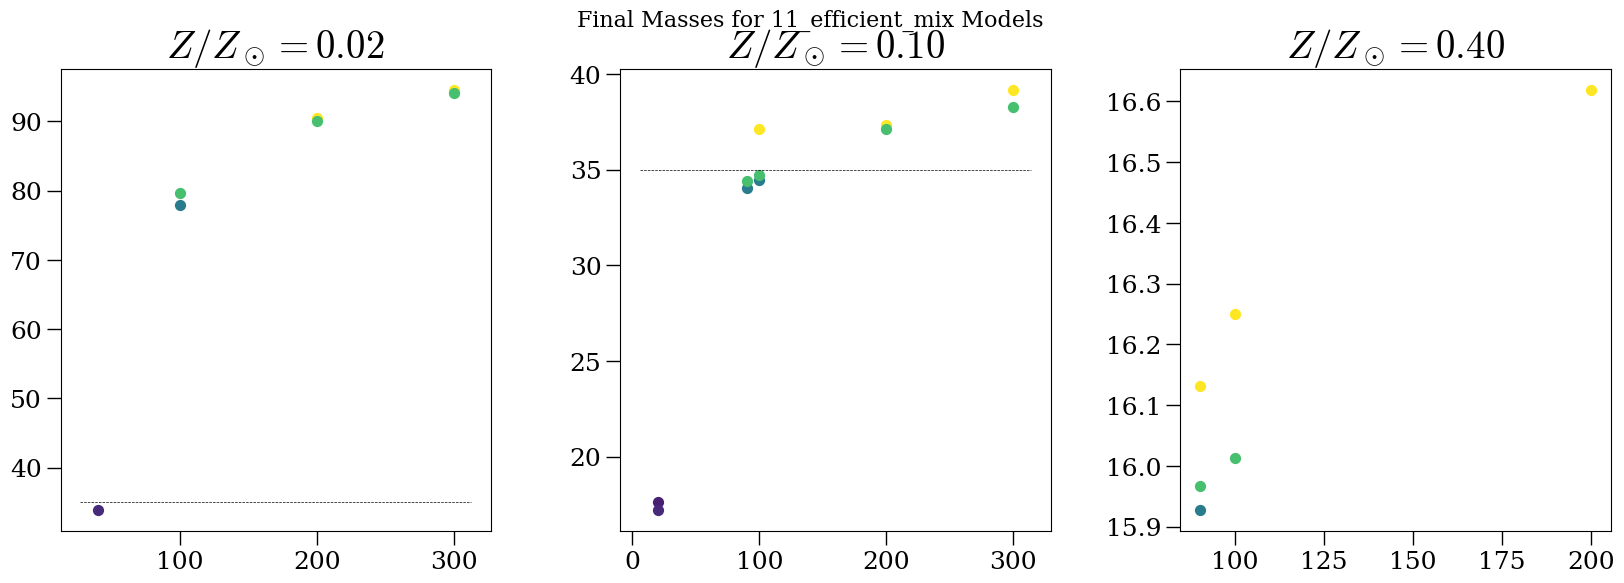

In [20]:
mf_dict = final_m_dict

min_p = 0.3
max_p = 2.0
cmap = cm.viridis

fig, axes = plt.subplots(1, 3, figsize=(20, 6))
fig.subplots_adjust(wspace=0.3)

z_keys = list(mf_dict.keys())
z_keys = sorted(z_keys, key=lambda x: float(x.replace('d', 'e')))
for i, zdivzsun in enumerate(z_keys):
    z_dict = mf_dict[zdivzsun]
    ax = axes[i]
    zdivzsun = float(zdivzsun.replace('d', 'e'))
    z_label = f'$Z/Z_\\odot = {zdivzsun:.2f}$'
    
    for j, (MI, m_dict) in enumerate(z_dict.items()):
        MI = float(MI.replace('d', 'e'))
        
        p_list = list(m_dict.keys())
        for p in p_list:
            Mf = m_dict[p]
            p = float(p)
            c = cmap(Normalize(vmin=min_p, vmax=max_p)(p))
            ax.scatter(MI, Mf, color=c, s=50)
        
    ax.set_title(z_label)
    y_up = ax.get_ylim()[1]
    if y_up > 35:
        ax.hlines(35, *ax.get_xlim(), color='k', linestyle='--', linewidth=0.5)
    
fig.suptitle(f'Final Masses for {physics_pick} Models', fontsize=16)

### Fixed metallicity

Now we attempt to fit our analytical modal to the data at fixed metallicities. We use the variable definitions to avoid fitting all parameters simultaneously. We have already defined our variables in such a way that, for $0.1\mathrm{Z}_\odot$,

$$
m_f^{-(\beta-1)} = m_i^{-(\beta-1)} + (\beta-1) \dot{m}_r m_i^{-\alpha},
$$

leaving three free parameters. We can start with a simple least-squares fit.

In [21]:
from scipy.optimize import curve_fit

In [22]:
# Collect data
def get_mi_mf_arrs(zdivzsun, final_var_dict):
    MI = []
    MF = []
    PP = []
    z_dict = final_var_dict[zdivzsun]
    zdivzsun = float(zdivzsun.replace('d', 'e'))
    for mi, m_dict in z_dict.items():
        mi = float(mi.replace('d', 'e'))
        p_list = list(m_dict.keys())
        for p in p_list:
            mf = m_dict[p]
            if not np.isnan(mf):
                MI.append(mi)
                MF.append(mf)
                PP.append(p)
    MI = np.array(MI)
    MF = np.array(MF)
    PP = np.array(PP)
    return MI, MF, PP

MI, MF, P = get_mi_mf_arrs(zdivzsun='1e-01', final_var_dict=mf_dict)

# Perform fit
def f(x, Mdot_r, alpha, beta): return Mf_from_Mi(x, Mdot_r, alpha, beta, gamma=1)
popt, pcov = curve_fit(f, MI, MF, p0=[1.e-4, 0.2, 2.5])
print(f'Fitted parameters: Mdot_r={popt[0]:.3e}, alpha={popt[1]:.3e}, beta={popt[2]:.3e}')

Fitted parameters: Mdot_r=1.028e-05, alpha=7.116e-02, beta=3.034e+00


/tmp/ipykernel_214919/3506894336.py:9: RuntimeWarning: invalid value encountered in power
  mf = mf_power**(1/(1-beta))


Now let's check,

Text(0.5, 1.0, 'Fitted parameters: $\\dot{M}_r=1.028e-05$, $\\alpha=7.116e-02$, $\\beta=3.034e+00$')

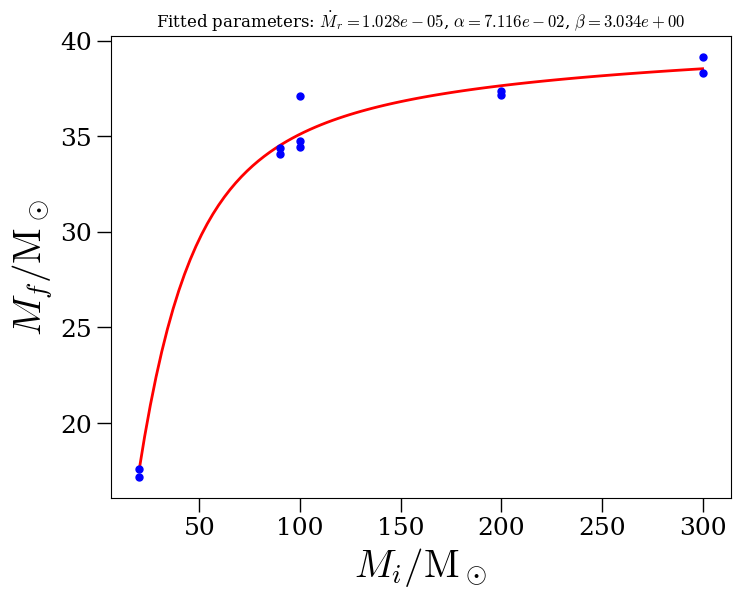

In [23]:
fig, ax = plt.subplots(figsize=(8,6))

ax.plot(np.linspace(MI.min(), MI.max(), 100), f(np.sort(np.linspace(MI.min(), MI.max(), 100)), *popt), 'r-')
ax.plot(MI, MF, 'b.', markersize=10)

ax.set_xlabel('$M_i/\\mathrm{M}_\\odot$')
ax.set_ylabel('$M_f/\\mathrm{M}_\\odot$')

descr_str1 = f'Fixed parameters: '
descr_str2 = f'Fitted parameters: $\dot{{M}}_r={popt[0]:.3e}$, $\\alpha={popt[1]:.3e}$, $\\beta={popt[2]:.3e}$'
ax.set_title(descr_str2, fontsize=12)

While the fit *looks* good, the parameter values we get are pushing the limits of what is achievable for our MESA models. A lifetime that depends as weakly on mass as $\propto\alpha^{0.07}$ in particular is about as weakly-dependent as we have seen under fine-tuned circumstances (strong winds, quick transition, high metallicities) while a $\dot{M}\propto M^{\beta=3}$ mass-loss rate scaling is steeper than any of our individual mass-loss rate recipes (although it might fit their combined mean affect).

Overall, a linear regression is limited by not accounting for priors and not easily allowing us to visualize the correlated uncertainties of all parameters. We know this correlation *should* exists, because, e.g., stronger winds soften the steep mass-dependency requirement for creating a pile-up. We would like to constrain the region of our whole $n$-dimensional parameter space where the creation of a pileup is possible. Therefore, a Bayesian approach with PyMC and simple but appropriate priors is more adequate for our problem.

Multiprocess sampling (4 chains in 4 jobs)
DEMetropolisZ: [log_Mdot_r, alpha, beta, sigma]


/home/ldesa/.pyenv/versions/cher/lib/python3.10/site-packages/rich/live.py:256: UserWarning: install "ipywidgets" 
for Jupyter support
  warnings.warn('install "ipywidgets" for Jupyter support')

Sampling 4 chains for 4_000 tune and 8_000 draw iterations (16_000 + 32_000 draws total) took 12 seconds.


         mean     sd  hdi_3%  hdi_97%  mcse_mean  mcse_sd  ess_bulk  ess_tail  \
Mdot_r  0.000  0.000   0.000    0.000      0.000    0.000    1131.0    1280.0   
alpha   0.082  0.098  -0.102    0.262      0.003    0.002    1147.0    1441.0   
beta    3.136  0.447   2.357    3.968      0.014    0.017    1045.0    1341.0   
sigma   0.986  0.293   0.542    1.498      0.008    0.008    1417.0    2289.0   

        r_hat  
Mdot_r   1.01  
alpha    1.00  
beta     1.00  
sigma    1.00  


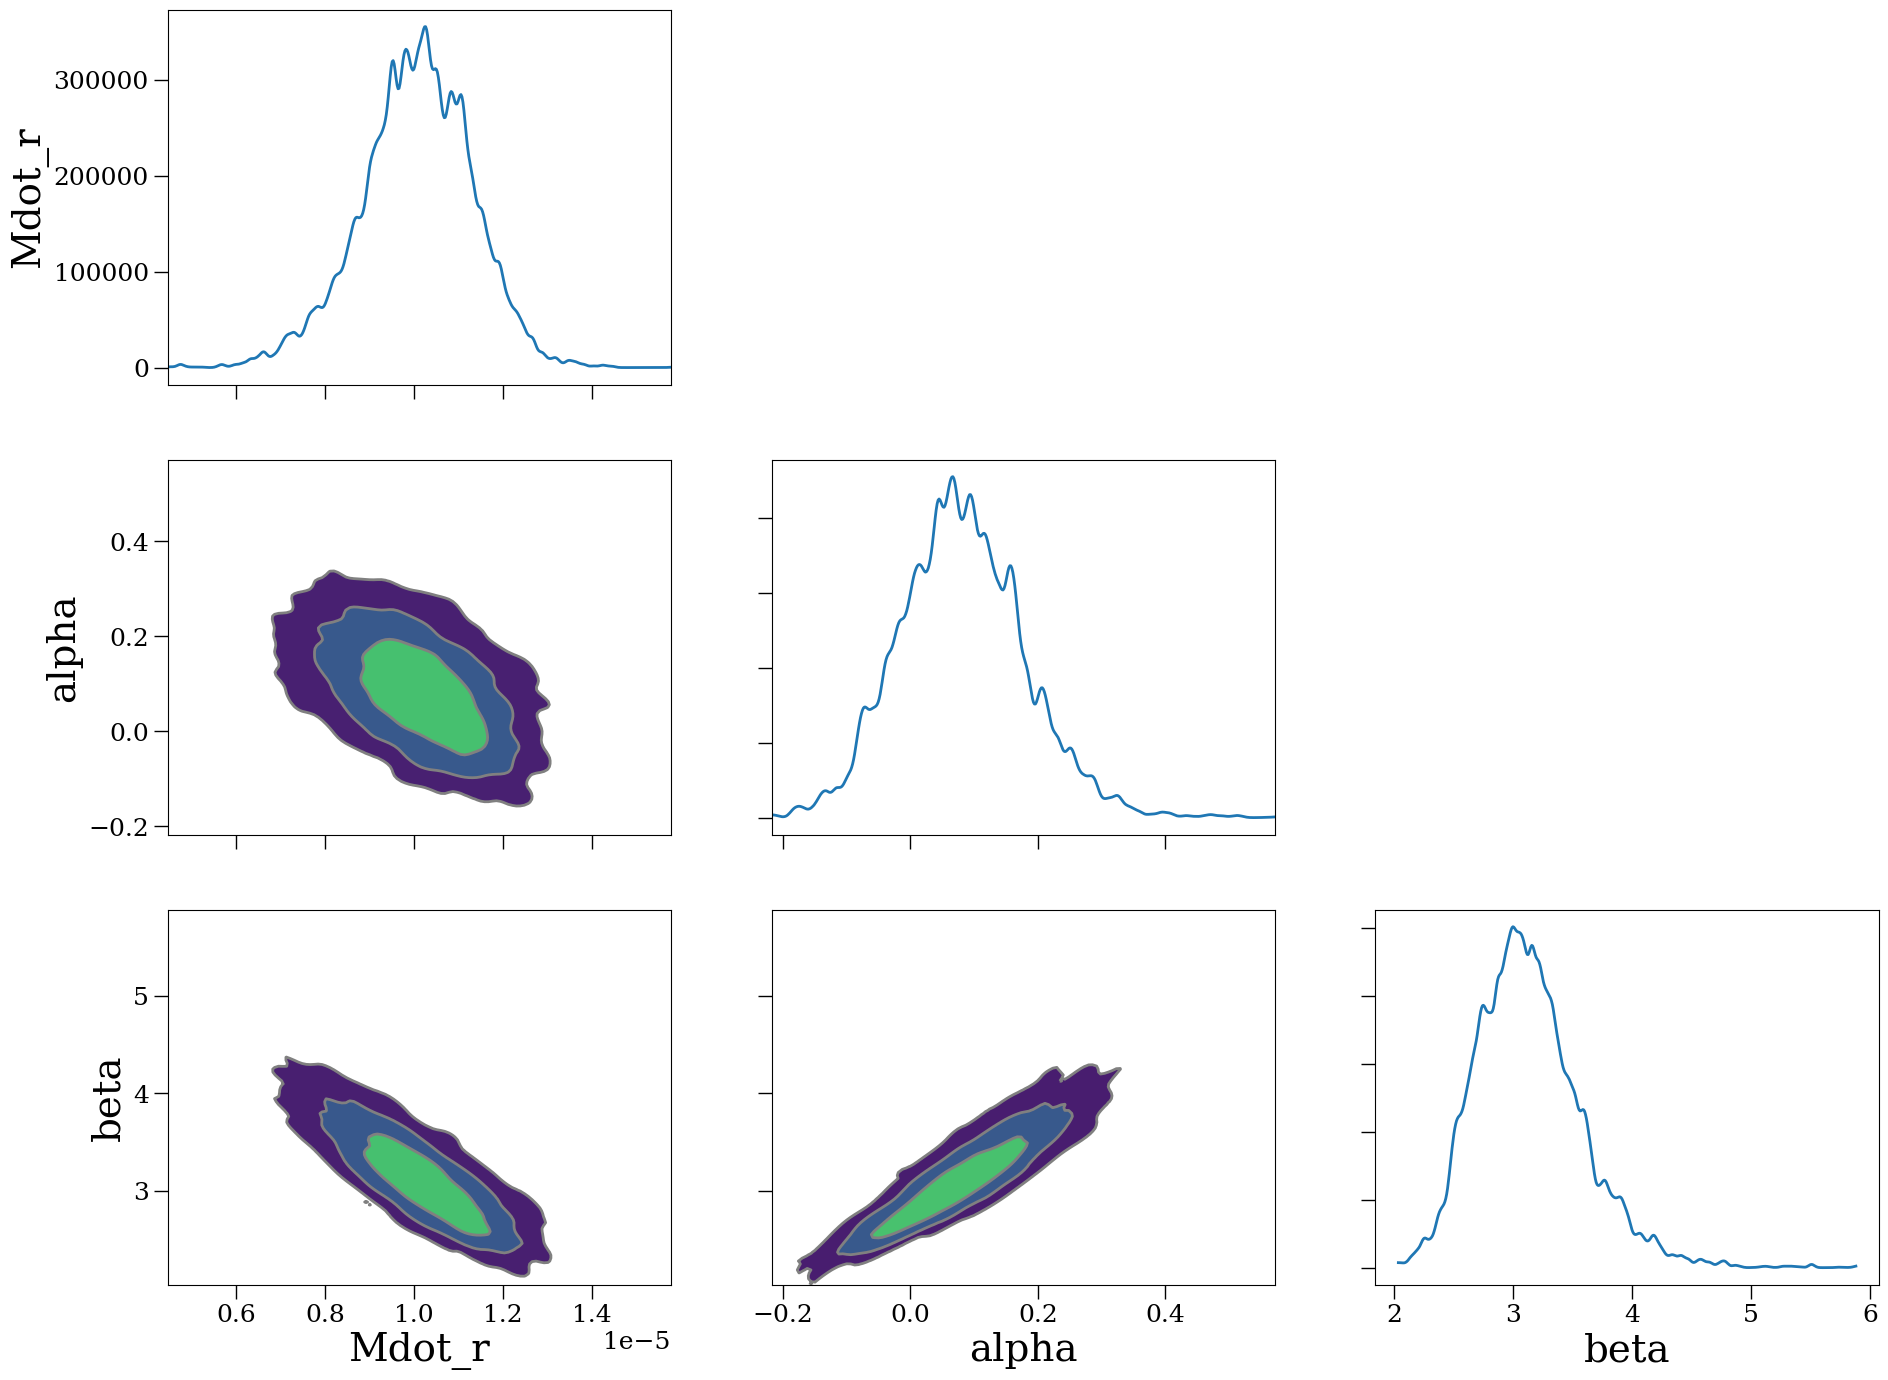

In [24]:
# wrap existing np function (no gradients → no NUTS)
@as_op(itypes=[pt.dvector, pt.dscalar, pt.dscalar, pt.dscalar], otypes=[pt.dvector])
def Mf_from_Mi_op(x, Mdot_r, alpha, beta):
    # IMPORTANT: ensure this returns np.float64 and shape == x.shape
    return Mf_from_Mi(np.asarray(x), float(Mdot_r), float(alpha), float(beta), gamma=1.0).astype(np.float64)

with pm.Model() as model:
    # broad priors
    # still missing fine adjustment (parameters must be positive, etc.)
    log_Mdot_r = pm.Normal("log_Mdot_r", mu=np.log(5e-6), sigma=1.0)
    Mdot_r = pm.Deterministic("Mdot_r", pt.exp(log_Mdot_r))

    alpha = pm.Normal("alpha", mu=0.2, sigma=1.0,)
    beta  = pm.TruncatedNormal("beta",  mu=2.0, sigma=1.0, lower=1.0)  # widen if needed

    sigma = pm.HalfNormal("sigma", sigma=max(1e-12, 0.5 * np.std(MF)))

    mu = Mf_from_Mi_op(pt.as_tensor_variable(MI), Mdot_r, alpha, beta)
    pm.Normal("obs", mu=mu, sigma=sigma, observed=MF)

    # Gradient-free sampler because the model includes a black-box op
    # but does it?
    idata = pm.sample(draws=8000, tune=4000, chains=4, step=pm.DEMetropolisZ(),
                      random_seed=123, idata_kwargs={"log_likelihood": True})

print(az.summary(idata, var_names=["Mdot_r","alpha","beta","sigma"]))
az.plot_pair(idata, var_names=["Mdot_r","alpha","beta"], kind="kde", marginals=True);


We now can see that a range of reasonable parameters exist, if we account for correlated uncertainties. A value of $\alpha=0.1-0.2$ respects the results from MESA, setting new limits on $\dot{M}_r$ and shifting $\beta$ towards $\beta=2.5-3.0$ which is high but achievable. The true test of the model itself, however, is whether this calibrated model can account for metallicity and physics variations.

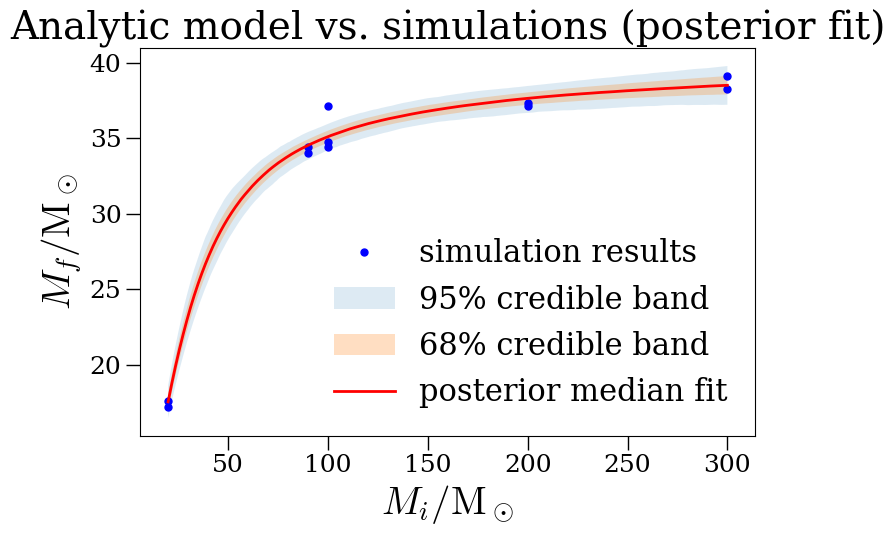

In [25]:
# 1) Build a smooth grid in Mi
AI = np.linspace(MI.min(), MI.max(), 300)

# 2) Pull posterior draws for parameters
post = idata.posterior
Mdot_r_samps = post["Mdot_r"].stack(sample=("chain","draw")).values
alpha_samps  = post["alpha"].stack(sample=("chain","draw")).values
beta_samps   = post["beta"].stack(sample=("chain","draw")).values
sigma_samps  = post["sigma"].stack(sample=("chain","draw")).values

# Optionally thin to speed up the predictive grid
thin = min(2000, Mdot_r_samps.size)
idx  = np.random.default_rng(0).choice(Mdot_r_samps.size, size=thin, replace=False)

Mdot_r_samps = Mdot_r_samps[idx]
alpha_samps  = alpha_samps[idx]
beta_samps   = beta_samps[idx]
sigma_samps  = sigma_samps[idx]

# 3) Evaluate the model on the grid for each draw
#    (parameter-uncertainty only; comment IN the noise line below to include observation mismatch)
AF = np.empty((thin, AI.size))
for i, (mr, a, b) in enumerate(zip(Mdot_r_samps, alpha_samps, beta_samps)):
    y_mean = Mf_from_Mi(AI, mr, a, b, gamma=1.0)
    # y = y_mean + np.random.normal(0, sigma_samps[i], size=xg.size)  # include noise if desired
    AF[i] = y_mean

# 4) Summaries for shaded bands
q05, q16, q50, q84, q95 = np.percentile(AF, [2.5, 16, 50, 84, 97.5], axis=0)

# 5) Plot
fig, ax = plt.subplots(figsize=(8,6))
ax.plot(MI, MF, 'b.', markersize=10, label='simulation results')

ax.fill_between(AI, q05, q95, alpha=0.15, label='95% credible band')
ax.fill_between(AI, q16, q84, alpha=0.25, label='68% credible band')
ax.plot(AI, q50, 'r-', lw=2, label='posterior median fit')

ax.set_xlabel(r'$M_i/\mathrm{M}_\odot$')
ax.set_ylabel(r'$M_f/\mathrm{M}_\odot$')
ax.legend(frameon=False)
ax.set_title('Analytic model vs. simulations (posterior fit)')
plt.tight_layout()


### Metallicity variations

We now have estimates $\dot{M}_r$, $\alpha$ and $\beta$. To find $\gamma$, we can write a root-finding problem, since, for a fixed $m_i$, the $m_f$ for two differents metallicities $\zeta$ and $\zeta^\prime$ are related by

$$
\begin{align}
&\frac{
    {m_f^\prime}^{-(\beta-1)} - m_i^{-(\beta-1)}
}{
    {m_f}^{-(\beta-1)} - m_i^{-(\beta-1)}
} = \left(
    \frac{\zeta^\prime}{\zeta}
\right)^\gamma \\
\Rightarrow &\gamma =
\frac{1}{\log\zeta^\prime/\zeta} \left[
    \log \left(
        {m_f^\prime}^{-(\beta-1)} - m_i^{-(\beta-1)}
    \right) -
    \log \left(
        {m_f}^{-(\beta-1)} - m_i^{-(\beta-1)}
    \right)
\right].
\end{align}
$$

If we set $\zeta=1$ (previous section), then

$$
\gamma = f(\beta) =
\frac{1}{\log\zeta^\prime} \left[
    \log \left(
        {m_f^\prime}^{-(\beta-1)} - m_i^{-(\beta-1)}
    \right) -
    \log \left(
        {m_f}^{-(\beta-1)} - m_i^{-(\beta-1)}
    \right)
\right].
$$

We can then compute $\gamma$ by taking the relevant difference ratios between different datasets and solving

$$
\gamma-f(\beta) = 0
$$

for every $\beta$ drawn.

In [26]:
def gamma_root(gamma, beta, MI, MF1, zeta1, MF2, zeta2):
    log2 = np.log10(
        MF2**(1-beta) - MI**(1-beta)
    )
    log1 = np.log10(
        MF1**(1-beta) - MI**(1-beta)
    )
    f_beta = (log2 - log1) / np.log10(zeta2/zeta1)
    root = np.abs(gamma-f_beta)
    return root

def gamma_from_beta(beta, MI, MF1, zeta1, MF2, zeta2, bracket=(1.e-6, 1.e1)):
    sol = root_scalar(
        lambda g: gamma_root(g, beta, MI, MF1, zeta1, MF2, zeta2),
        bracket=bracket
    )
    if not sol.converged:
        raise RuntimeError("Failed to converge for beta={beta}")
    return sol.root

Now let's load our data. The baseline is always the $\zeta=1$ case, but we can compute $\gamma$ for every pairing, and it *should* remain consistent.

In [27]:
df_cols = ['zeta', 'p', 'Mi', 'Mf']
df = pd.DataFrame(columns=df_cols)
for key in z_keys:
    MI, MF, PP = get_mi_mf_arrs(key, mf_dict)
    ZETA = np.tile(float(key.replace('d', 'e')), MI.shape)/0.1
    df = pd.concat([df, pd.DataFrame({'zeta': ZETA, 'p': PP, 'Mi': MI, 'Mf': MF})], ignore_index=True)
df

/tmp/ipykernel_214919/561180022.py:6: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  df = pd.concat([df, pd.DataFrame({'zeta': ZETA, 'p': PP, 'Mi': MI, 'Mf': MF})], ignore_index=True)


,zeta,p,Mi,Mf
0,0.2,0.50,40.0,33.825526
1,0.2,1.50,100.0,79.657878
2,0.2,1.00,100.0,77.959271
3,0.2,2.00,200.0,90.491770
4,0.2,1.50,200.0,90.003104
5,0.2,2.00,300.0,94.495993
6,0.2,1.50,300.0,94.026786
7,1.0,0.45,20.0,17.616624
8,1.0,0.50,20.0,17.193173
9,1.0,1.00,90.0,34.051140


Now let's define the functions necessary for the pairwise computations of gamma.

In [28]:
def _logdiffexp(loga, logb):
    """Safely return log(exp(loga)-exp(logb)) assuming loga > logb."""
    if not np.all(loga > logb):
        raise ValueError('Need loga > logb for positive different within log.')
    return loga + np.log1p(-np.exp(logb - loga))

def gamma_from_pair(beta, Mi, Mf, zeta, Mi_p, Mf_p, zeta_p, tol=1e-12):
    """Compute gamma assuming usual boundaries.

    Assumes beta > 1, Mf > Mi, Mf_p > Mi_p, zeta != zeta_p.
    """
    if beta <= 1:
        return ValueError("beta must be >1.")
    if not (Mf < Mi - tol and Mf_p < Mi_p - tol):
        return ValueError("Mf must be < Mi and Mf_p must be < Mi_p.")
    if not (zeta != zeta_p):
        return ValueError("zeta must be != zeta_p.")
    
    # safe log(m^(-(beta-1)))
    t = beta - 1.0
    log_a = -t * np.log(Mf)
    log_b = -t * np.log(Mi)
    log_ap = -t * np.log(Mf_p)
    log_bp = -t * np.log(Mi_p)
    
    # safe log(mf^(-(beta-1)) - mi^(-(beta-1)))
    log_term = _logdiffexp(log_a, log_b)
    log_termp = _logdiffexp(log_ap, log_bp)
    denom = np.log(zeta_p/zeta)
    
    gamma = (log_termp - log_term) / denom
    return gamma
    
def valid_gamma_pair(row1, row2):
    """Check whether a pair of rows can be used to compute gamma."""
    if (row1.p != row2.p or row1.Mi != row2.Mi):
        return False
    elif row1.zeta == row2.zeta:
        return False
    else:
        return True

Now we can compute $\gamma$ for a $\beta$ draw and all valid pairs.

In [29]:
def gammas_from_row_pairs(beta, data):
    """Compute gammas for all valid pairs of rows in a dataframe, with a fixed beta."""
    gammas = []
    n_rows = data.shape[0]
    for i in range(n_rows):
        row1 = data.iloc[i]
        for j in range(i+1, n_rows):
            row2 = data.iloc[j]
            if valid_gamma_pair(row1, row2):
                g = gamma_from_pair(beta, row1.Mi, row1.Mf, row1.zeta,
                                    row2.Mi, row2.Mf, row2.zeta)
                gammas.append(g)
    return np.array(gammas)

In [30]:
%%time
from concurrent.futures import ProcessPoolExecutor, as_completed
from tqdm import tqdm
CPU_COUNT = 36

def pooled_gamma_from_b(b):
    GAMMA = gammas_from_row_pairs(b, df)
    return float(np.median(GAMMA))

beta_draws = idata.posterior['beta'].values.ravel()

gamma_pooled_draws = []
with ProcessPoolExecutor(max_workers=CPU_COUNT) as executor:
    futures = [executor.submit(pooled_gamma_from_b, b) for b in beta_draws]
    for future in tqdm(as_completed(futures), total=len(futures), desc='Computing gamma'):
        gamma_pooled_draws.append(future.result())

gamma_pooled_draws = np.asarray(gamma_pooled_draws)

g_med = np.median(gamma_pooled_draws)
g_q16, g_q84 = np.percentile(gamma_pooled_draws, [16, 84])
print(f"gamma ≈ {g_med:.6g}  (68% CI [{g_q16:.6g}, {g_q84:.6g}])")

Computing gamma: 100%|██████████| 32000/32000 [02:19<00:00, 228.72it/s]


gamma ≈ 1.25239  (68% CI [1.06242, 1.48255])
CPU times: user 40.2 s, sys: 4.69 s, total: 44.9 s
Wall time: 2min 22s


For visualization, we can now add our $\gamma$ array back to the original `InferenceData` instance.

In [31]:
beta_da = idata.posterior['beta']
gamma_vals = gamma_pooled_draws.reshape(beta_da.shape)
gamma_da = xr.DataArray(
    gamma_vals,
    dims=beta_da.dims,
    coords=beta_da.coords,
    name='gamma'
)
idata.posterior = idata.posterior.assign(gamma=gamma_da)

         mean     sd  hdi_3%  hdi_97%  mcse_mean  mcse_sd  ess_bulk  ess_tail  \
Mdot_r  0.000  0.000   0.000    0.000      0.000    0.000    1131.0    1280.0   
alpha   0.082  0.098  -0.102    0.262      0.003    0.002    1147.0    1441.0   
beta    3.136  0.447   2.357    3.968      0.014    0.017    1045.0    1341.0   
gamma   1.277  0.222   0.907    1.689      0.007    0.009    1150.0    1430.0   
sigma   0.986  0.293   0.542    1.498      0.008    0.008    1417.0    2289.0   

        r_hat  
Mdot_r   1.01  
alpha    1.00  
beta     1.00  
gamma    1.00  
sigma    1.00  


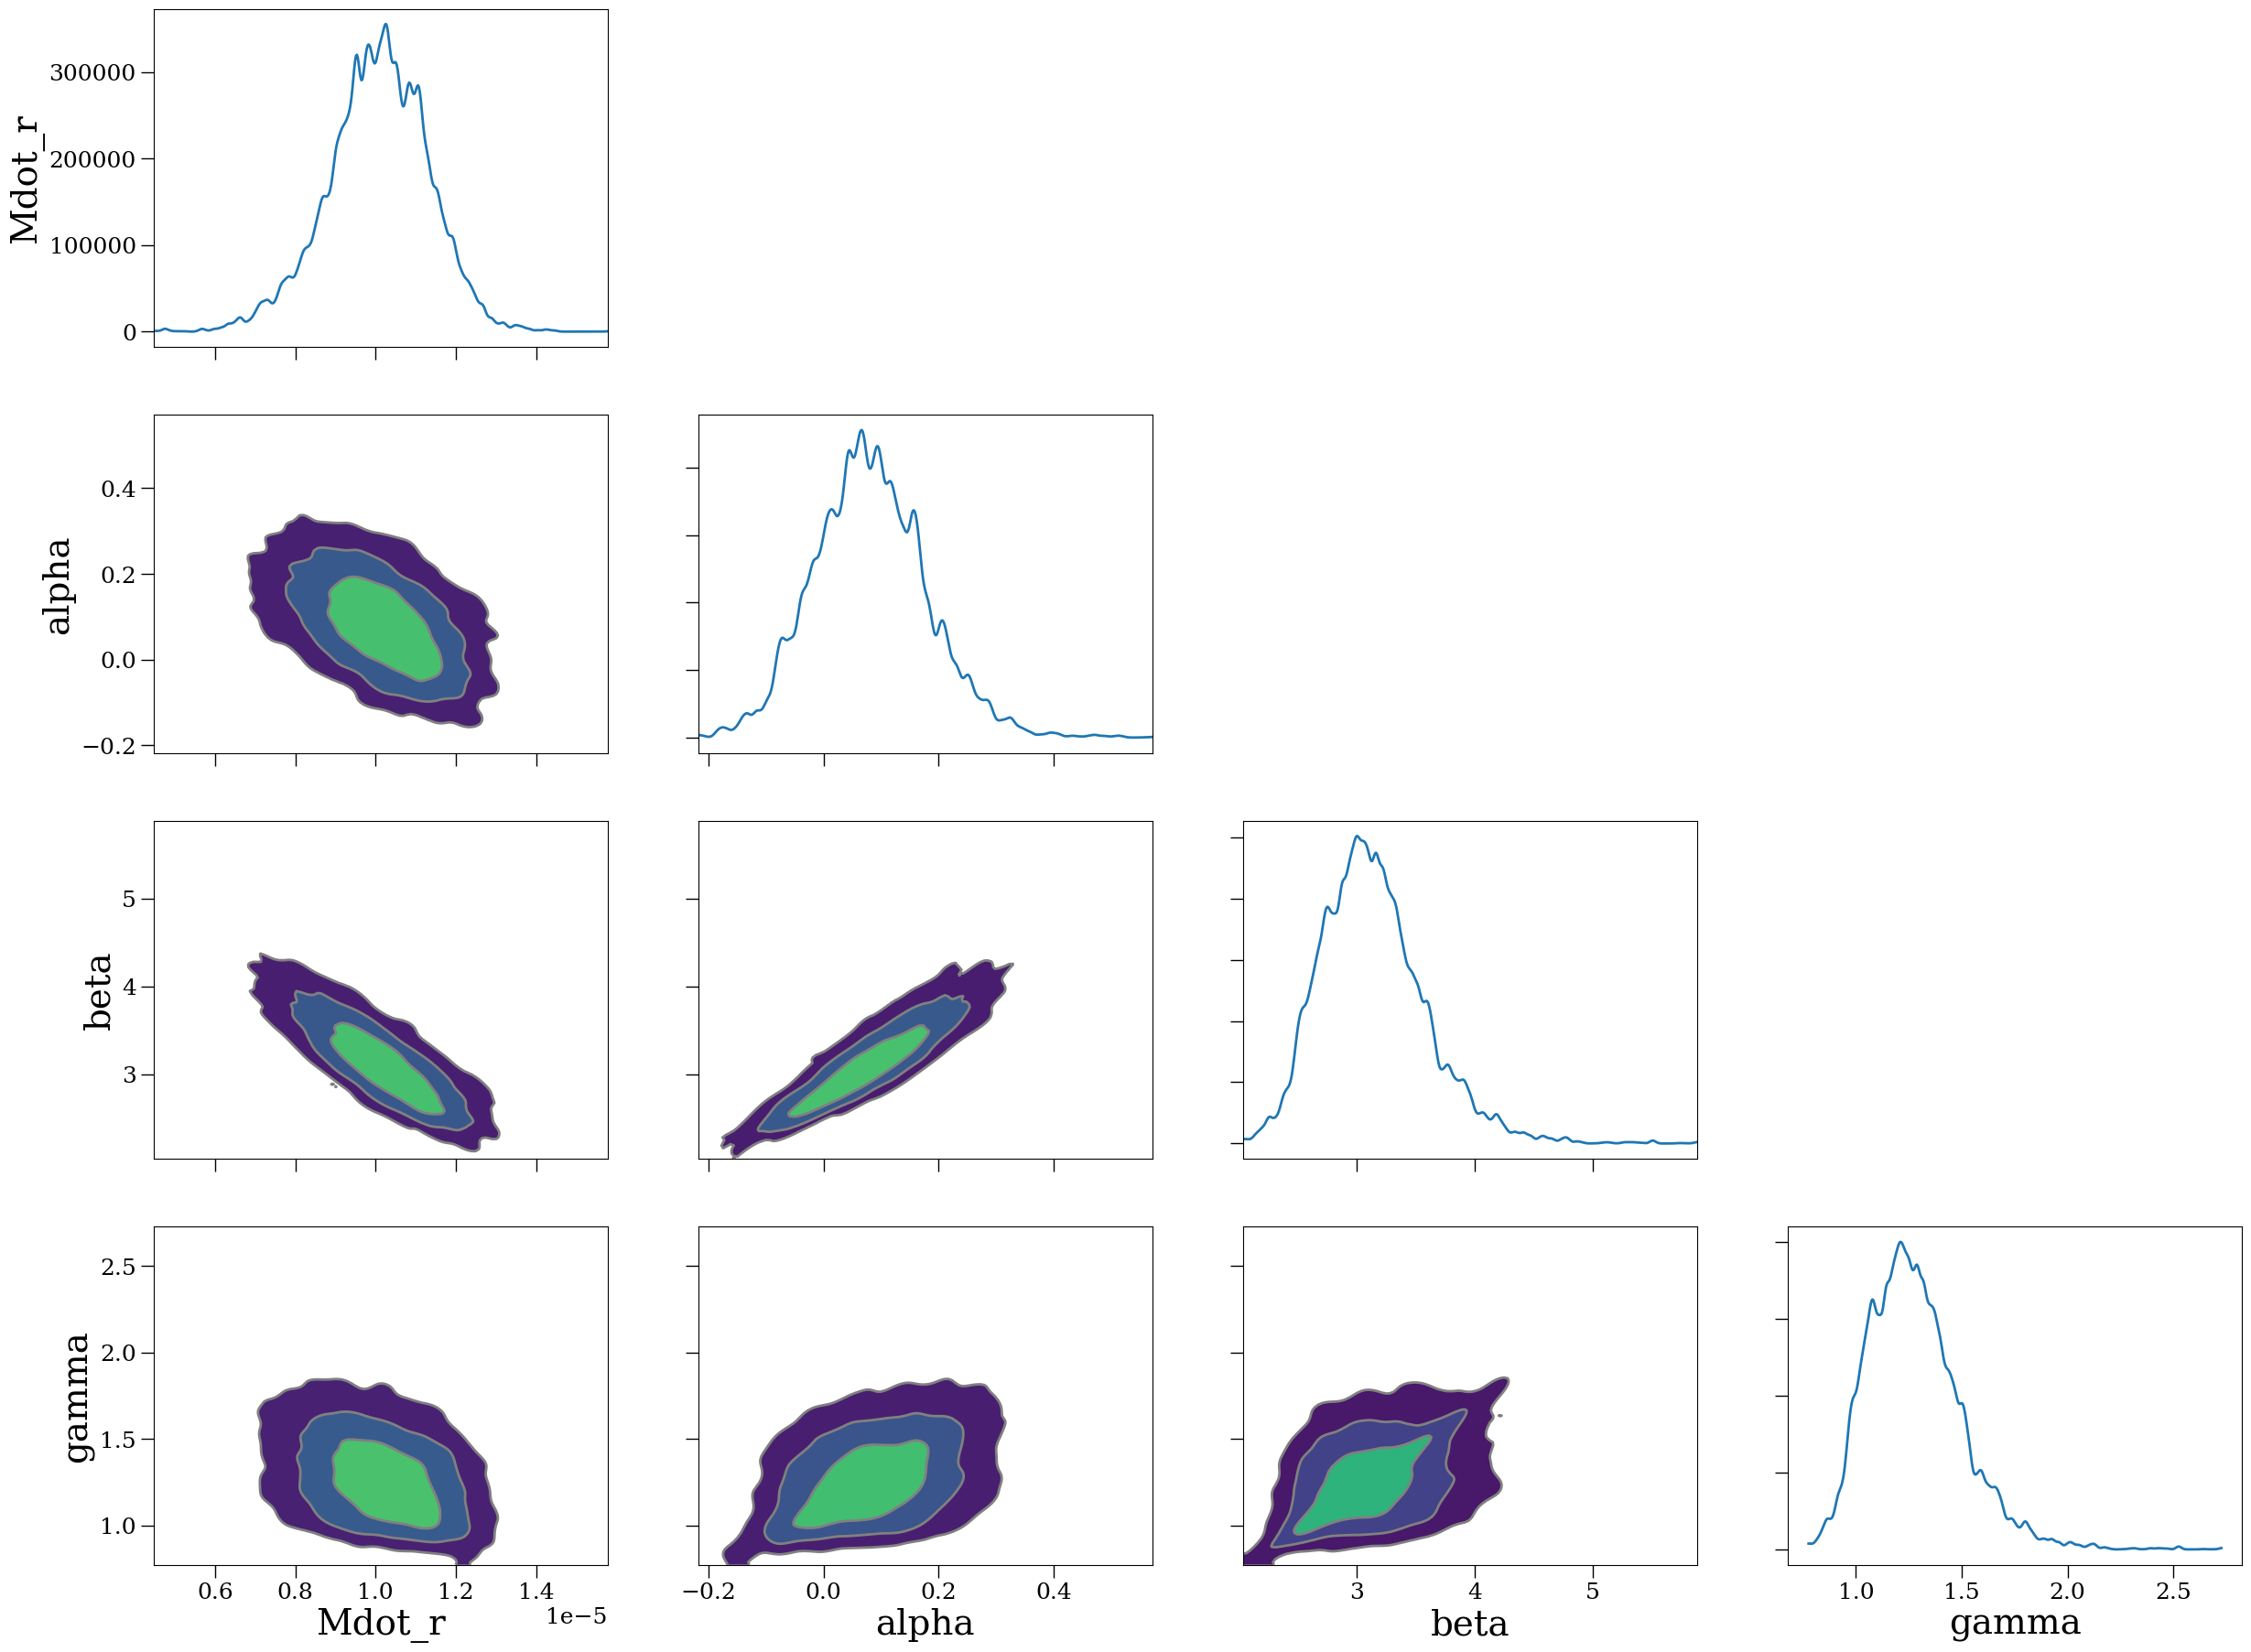

In [32]:
print(az.summary(idata, var_names=["Mdot_r","alpha","beta","gamma", "sigma"]))
az.plot_pair(idata, var_names=["Mdot_r","alpha","beta","gamma"], kind="kde", marginals=True);

In [33]:
default_multiplier_dict = {
    'mdot_r_add' : 0.,
    'mdot_r_mult' : 1.,
    'alpha_add' : 0.,
    'alpha_mult' : 1.,
    'beta_add' : 0.,
    'beta_mult' : 1.,
    'gamma_add' : 0.,
    'gamma_mult' : 1.
}

def plot_fixed_z(ax, final_var_dict, zdivzsun_key, multiplier_dict=default_multiplier_dict, legend=False, 
                 label_axes=False):
    X, Y, P = get_mi_mf_arrs(zdivzsun=zdivzsun_key, final_var_dict=final_var_dict)
    zdivzsun = float(zdivzsun_key.replace('d', 'e'))

    # 1) Build a smooth grid in Mi
    xg = np.linspace(X.min(), X.max(), 300)
    
    # 2) Pull posterior draws for parameters
    post = idata.posterior
    
    sigma_samps  = post["sigma"].stack(sample=("chain","draw")).values
    
    Mdot_r_samps = post["Mdot_r"].stack(sample=("chain","draw")).values
    Mdot_r_samps = Mdot_r_samps * multiplier_dict['mdot_r_mult'] + multiplier_dict['mdot_r_add']
    
    alpha_samps = post["alpha"].stack(sample=("chain","draw")).values
    alpha_samps = alpha_samps * multiplier_dict['alpha_mult'] + multiplier_dict['alpha_add']
    
    beta_samps = post["beta"].stack(sample=("chain","draw")).values
    beta_samps = beta_samps * multiplier_dict['beta_mult'] + multiplier_dict['beta_add']

    gamma_samps  = post["gamma"].stack(sample=("chain","draw")).values
    gamma_samps = gamma_samps * multiplier_dict['gamma_mult'] + multiplier_dict['gamma_add']

    # Optionally thin to speed up the predictive grid
    thin = min(2000, Mdot_r_samps.size)
    idx  = np.random.default_rng(0).choice(Mdot_r_samps.size, size=thin, replace=False)

    Mdot_r_samps = Mdot_r_samps[idx]
    alpha_samps  = alpha_samps[idx]
    beta_samps   = beta_samps[idx]
    sigma_samps  = sigma_samps[idx]
    gamma_samps = gamma_samps[idx]

    # 3) Evaluate the model on the grid for each draw
    #    (parameter-uncertainty only; comment IN the noise line below to include observation mismatch)
    Yg = np.empty((thin, xg.size))
    for i, (mr, a, b, g) in enumerate(zip(Mdot_r_samps, alpha_samps, beta_samps, gamma_samps)):
        y_mean = Mf_from_Mi(xg, mr, a, b, g, zeta=zdivzsun/0.1)
        # y = y_mean + np.random.normal(0, sigma_samps[i], size=xg.size)  # include noise if desired
        Yg[i] = y_mean

    # 4) Summaries for shaded bands
    q05, q16, q50, q84, q95 = np.percentile(Yg, [2.5, 16, 50, 84, 97.5], axis=0)

    # 5) Plot
    ax.plot(X, Y, 'b.', markersize=10, label='simulation results')

    ax.fill_between(xg, q05, q95, alpha=0.15, label='95% credible band')
    ax.fill_between(xg, q16, q84, alpha=0.25, label='68% credible band')
    ax.plot(xg, q50, 'r-', lw=2, label='posterior median fit')
    
    if label_axes:
        ax.set_xlabel(r'$M_i/\mathrm{M}_\odot$')
        ax.set_ylabel(r'$M_f/\mathrm{M}_\odot$')
    if legend:
        ax.legend(frameon=False, loc='upper left', bbox_to_anchor=(1,1))
    ax.set_title(f'$Z/\\mathrm{{Z}}_\\odot = {zdivzsun:.2g}$')


Text(0.5, 0, '$M_i/\\mathrm{M}_\\odot$')

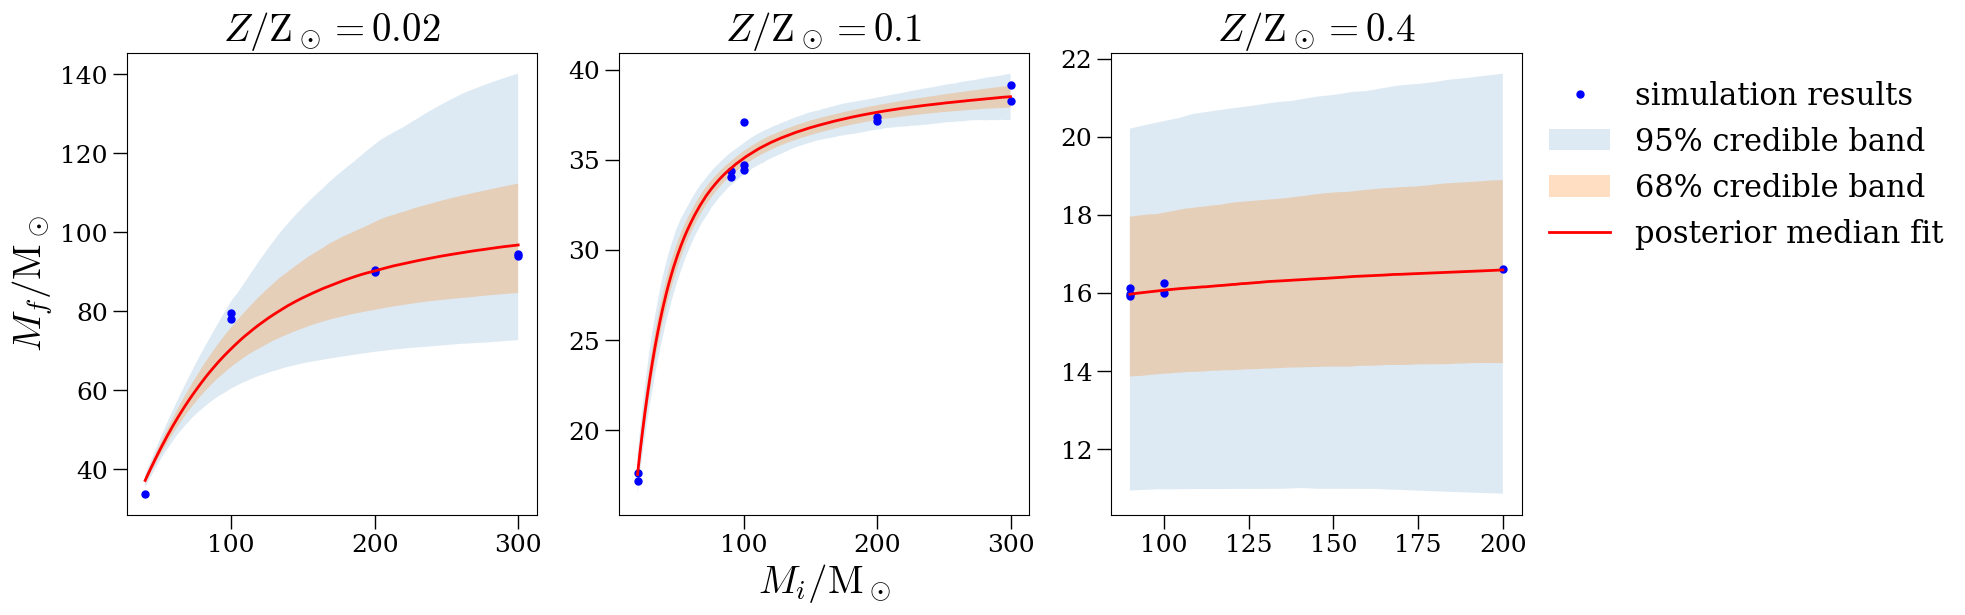

In [34]:
fig, axes = plt.subplots(1, 3, figsize=(18, 6))

for i, (zdivzsun_key, ax) in enumerate(zip(z_keys, axes)):
    legend = False if i < len(axes)-1 else True
    plot_fixed_z(ax, mf_dict, zdivzsun_key, legend=legend, label_axes=False)
axes[0].set_ylabel('$M_f/\\mathrm{M}_\\odot$')
axes[1].set_xlabel('$M_i/\\mathrm{M}_\\odot$')

#### Delay time

Let us now compare the delay time computed from MESA results and the one we obtain from our analytical model. If we assume Jeans mode mass loss, the final orbital separation in our analytical model is given by

$$
\begin{equation}
A_f = A_i \left[
    1 + (\beta-1)\dot{m}_r \zeta^\gamma m_i^{\beta - (\alpha+1)}
\right]^{-\frac{1}{\beta-1}}
\end{equation}
$$

In [35]:
def Af_from_Ai(Ai, Mi, Mdot_r, alpha, beta, gamma, zeta=1, Mr=30, tau_r=1e6):
    zeta = max(zeta, ZETA_MIN)
    mi = Mi/Mr
    mdot_r = Mdot_r / (Mr/tau_r)

    root_term = 1 + (beta-1) * mdot_r * zeta**gamma * mi**(beta - (alpha+1))
    Af = Ai * root_term**(1/(beta-1))
    return Af

In [37]:
def plot_af_fixed_z(
    ax,
    mf_dict,                 # not used below (kept for signature parity)
    af_dict,                 # nested: z -> mi -> p -> Af_sim
    zdivzsun_key,
    multiplier_dict=default_multiplier_dict,
    legend=False,
    label_axes=False,
    p_list=None,             # optional subset of P values to plot
    q=1.0,                   # companion mass if a_from_p needs it
    thin_max=2000,
    seed=0,
):
    # data for this Z/Zsun
    MI, MF, P = get_mi_mf_arrs(zdivzsun=zdivzsun_key, final_var_dict=mf_dict)
    zdivzsun = float(zdivzsun_key.replace('d', 'e'))

    # grid in Mi for drawing the bands/median
    MI_PLOT = np.linspace(MI.min(), MI.max(), 300)
    P = np.asarray(P, dtype=float)

    # choose which P to show
    if p_list is None:
        p_list = np.quantile(P, [0.25, 0.5, 0.75])
    elif p_list == "all":                              # FIX: use '==' not 'is'
        p_list = np.unique(P)
    else:
        p_list = np.atleast_1d(p_list)

    # posterior draws (apply any post-scaling)
    post = idata.posterior

    Mr = post["Mdot_r"].stack(sample=("chain", "draw")).values
    Mr = Mr * multiplier_dict["mdot_r_mult"] + multiplier_dict["mdot_r_add"]

    Al = post["alpha"].stack(sample=("chain", "draw")).values
    Al = Al * multiplier_dict["alpha_mult"] + multiplier_dict["alpha_add"]

    Be = post["beta"].stack(sample=("chain", "draw")).values
    Be = Be * multiplier_dict["beta_mult"] + multiplier_dict["beta_add"]

    Ga = post["gamma"].stack(sample=("chain", "draw")).values
    Ga = Ga * multiplier_dict["gamma_mult"] + multiplier_dict["gamma_add"]

    # optional thinning for speed
    rng = np.random.default_rng(seed)
    n = Mr.size
    thin = min(thin_max, n)
    idx = rng.choice(n, size=thin, replace=False)
    Mr, Al, Be, Ga = Mr[idx], Al[idx], Be[idx], Ga[idx]

    # draw bands/median + same-color scatter for each P
    bands_labeled = False
    scatter_labeled = False

    for p in np.atleast_1d(p_list):
        # A_i as a function of Mi for this period (vectorized in MI_PLOT)
        AI_grid = a_from_p(p, MI_PLOT, q)

        # evaluate Af for each draw on the Mi grid
        AF = np.empty((thin, MI_PLOT.size))
        for i, (mr, a, b, g) in enumerate(zip(Mr, Al, Be, Ga)):
            AF[i] = Af_from_Ai(AI_grid, MI_PLOT, mr, a, b, g, zeta=zdivzsun / 0.1)

        # percentiles across draws
        q05, q16, q50, q84, q95 = np.percentile(AF, [2.5, 16, 50, 84, 97.5], axis=0)

        # draw bands (label only once)
        if not bands_labeled:
            ax.fill_between(MI_PLOT, q05, q95, alpha=0.15, label="95% credible band")
            ax.fill_between(MI_PLOT, q16, q84, alpha=0.25, label="68% credible band")
            bands_labeled = True
        else:
            ax.fill_between(MI_PLOT, q05, q95, alpha=0.15)
            ax.fill_between(MI_PLOT, q16, q84, alpha=0.25)

        # median curve for this P; capture its color
        (line_handle,) = ax.plot(MI_PLOT, q50, lw=2, label=fr"median, $P={p:.3g}$")
        line_color = line_handle.get_color()

        # --- simulation scatter for this P, in the SAME color ---
        # Build Af_sim(MI) for the MI values that exist in the dict
        mi_vals = []
        af_vals = []
        znode = af_dict.get(zdivzsun_key, {})
        for mi in MI:
            mi_key = f"{mi:.1f}"
            p_key = f"{p:.2f}"
            try:
                af_sim = znode[mi_key][p_key]
            except KeyError:
                continue
            mi_vals.append(mi)
            af_vals.append(af_sim)

        if mi_vals:
            # single scatter label once; same color as the median curve for this P
            ax.scatter(
                mi_vals,
                af_vals,
                s=20,
                marker="o",
                alpha=0.6,
                color=line_color,
                label="simulation" if not scatter_labeled else None,
                zorder=3,
            )
            scatter_labeled = True

    if label_axes:
        ax.set_xlabel(r"$M_i/\mathrm{M}_\odot$")
        ax.set_ylabel(r"$A_f/\mathrm{R}_\odot$")
    if legend:
        ax.legend(frameon=False, loc="upper left", bbox_to_anchor=(1, 1))
    ax.set_title(fr"$Z/\mathrm{{Z}}_\odot = {zdivzsun:.2g}$")


Text(0.5, 0, '$A_f/\\mathrm{R}_\\odot$')

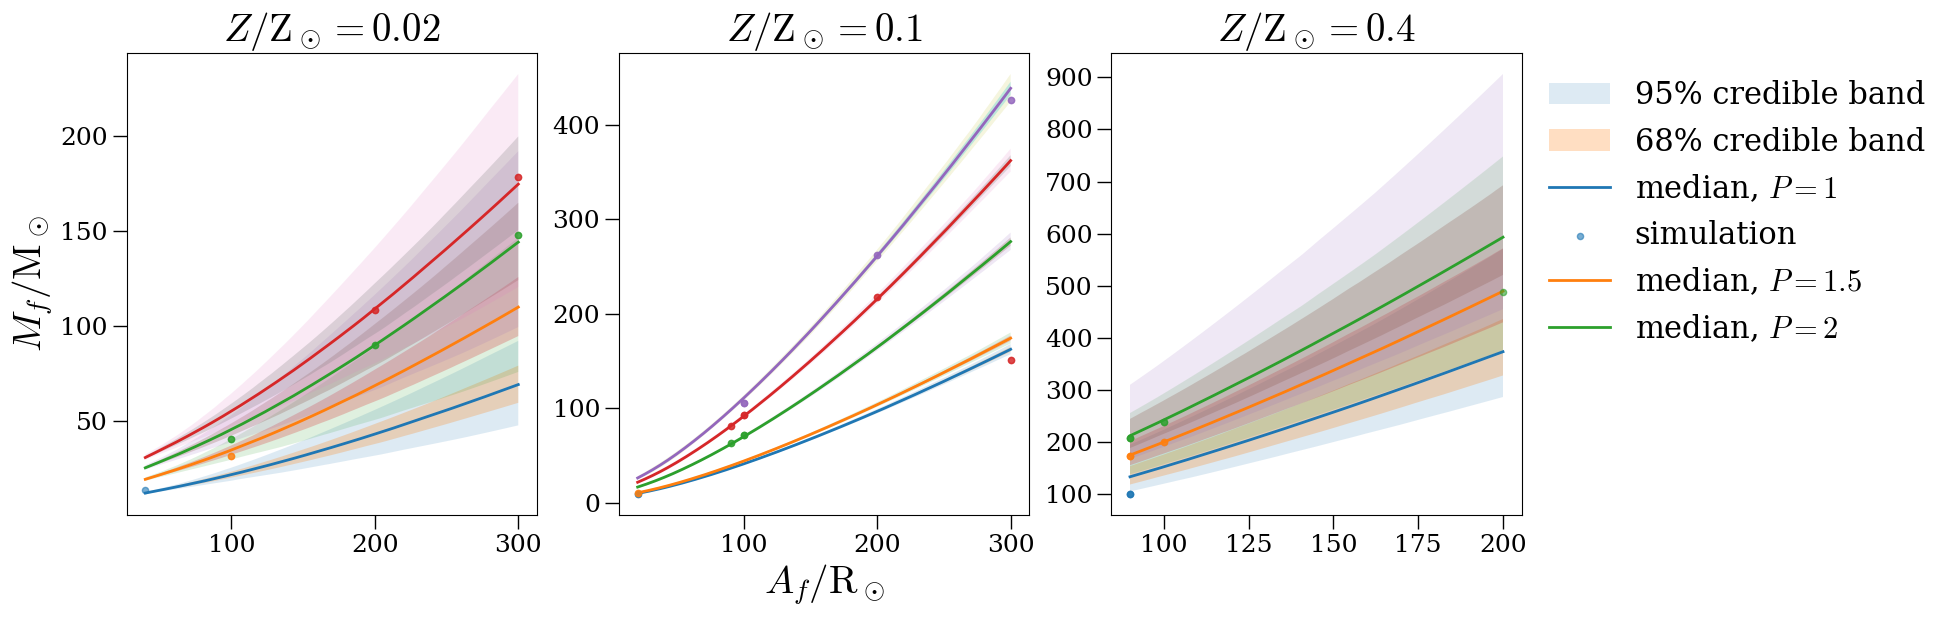

In [38]:
fig, axes = plt.subplots(1, 3, figsize=(18, 6))

for i, (zdivzsun_key, ax) in enumerate(zip(z_keys, axes)):
    legend = False if i < len(axes)-1 else True
    plot_af_fixed_z(ax, final_m_dict, final_a_dict, zdivzsun_key, legend=legend, label_axes=False, p_list='all')
    axes[0].set_ylabel('$M_f/\\mathrm{M}_\\odot$')
axes[1].set_xlabel(r'$A_f/\mathrm{R}_\odot$')

Now for the actual delay time.

In [39]:
def delay_time(mi, mf, af, alpha, m_r=30., tau_r=1e6):
    t_c = coalescence_time(mf, af, q)
    t_life = tau_r * (mi/m_r)**-alpha
    t_delay = t_c + t_life
    return t_delay

def plot_delay_fixed_z(
    ax,
    mf_dict,                 # used by get_mi_mf_arrs
    log_td_dict,             # nested: z -> mi -> p -> log10(t_delay_sim)
    zdivzsun_key,
    multiplier_dict=default_multiplier_dict,
    legend=False,
    label_axes=False,
    p_list=None,             # subset of P values to show; or "all"
    q=1.0,                   # mass ratio (or companion mass) used by a_from_p / coalescence_time
    thin_max=2000,
    seed=0,
    m_r=30.0,                # reference mass for t_life
    tau_r=1e6,               # reference lifetime
    log10_y=True,            # plot log10 delay time on y-axis
):
    # Data for this Z/Zsun
    MI, MF, P = get_mi_mf_arrs(zdivzsun=zdivzsun_key, final_var_dict=mf_dict)
    zdivzsun = float(zdivzsun_key.replace('d', 'e'))
    MI_PLOT = np.linspace(MI.min(), MI.max(), 300)
    P = np.asarray(P, dtype=float)

    # Choose P values
    if p_list is None:
        p_list = np.quantile(P, [0.25, 0.5, 0.75])
    elif p_list == "all":
        p_list = np.unique(P)
    else:
        p_list = np.atleast_1d(p_list)

    # Posterior draws (+ multipliers)
    post = idata.posterior
    Mr = post["Mdot_r"].stack(sample=("chain","draw")).values
    Mr = Mr * multiplier_dict['mdot_r_mult'] + multiplier_dict['mdot_r_add']

    Al = post["alpha"].stack(sample=("chain","draw")).values
    Al = Al * multiplier_dict['alpha_mult'] + multiplier_dict['alpha_add']

    Be = post["beta"].stack(sample=("chain","draw")).values
    Be = Be * multiplier_dict['beta_mult'] + multiplier_dict['beta_add']

    Ga = post["gamma"].stack(sample=("chain","draw")).values
    Ga = Ga * multiplier_dict['gamma_mult'] + multiplier_dict['gamma_add']

    # Optional thinning
    rng  = np.random.default_rng(seed)
    n    = Mr.size
    thin = min(thin_max, n)
    idx  = rng.choice(n, size=thin, replace=False)
    Mr, Al, Be, Ga = Mr[idx], Al[idx], Be[idx], Ga[idx]

    # Flags for legend entries
    bands_labeled = False
    scatter_labeled = False

    for p in np.atleast_1d(p_list):
        # A_i as function of Mi for this P
        AI_grid = a_from_p(p, MI_PLOT, q)

        # Delay time per draw on the Mi grid
        TD = np.empty((thin, MI_PLOT.size))
        for i, (mr, a, b, g) in enumerate(zip(Mr, Al, Be, Ga)):
            # model Af and Mf for this draw and grid
            AF = Af_from_Ai(AI_grid, MI_PLOT, mr, a, b, g, zeta=zdivzsun/0.1)
            MF_model = Mf_from_Mi(MI_PLOT, mr, a, b, g, zeta=zdivzsun/0.1)

            # coalescence + lifetime
            t_c = coalescence_time(MF_model, AF, q)
            t_life = tau_r * (MI_PLOT / m_r) ** (-a)
            t_delay = t_c + t_life

            # safety: ensure strictly positive before log10
            if log10_y:
                TD[i] = np.log10(np.clip(t_delay, 1e-300, np.inf))
            else:
                TD[i] = t_delay

        # Credible bands
        q05, q16, q50, q84, q95 = np.percentile(TD, [2.5, 16, 50, 84, 97.5], axis=0)

        # Bands (labeled once)
        if not bands_labeled:
            ax.fill_between(MI_PLOT, q05, q95, alpha=0.15, label="95% credible band")
            ax.fill_between(MI_PLOT, q16, q84, alpha=0.25, label="68% credible band")
            bands_labeled = True
        else:
            ax.fill_between(MI_PLOT, q05, q95, alpha=0.15)
            ax.fill_between(MI_PLOT, q16, q84, alpha=0.25)

        # Median curve and its color
        (line_handle,) = ax.plot(MI_PLOT, q50, lw=2, label=fr"median, $P={p:.3g}$")
        line_color = line_handle.get_color()

        # --- Simulation scatter for this P, SAME color ---
        mi_vals, td_vals = [], []
        znode = log_td_dict.get(zdivzsun_key, {})
        for mi in MI:
            mi_key = f"{mi:.1f}"
            p_key  = f"{p:.2f}"
            try:
                log_td = znode[mi_key][p_key]   # simulation stored as log10 delay time
            except KeyError:
                continue
            mi_vals.append(mi)
            td_vals.append(log_td if log10_y else (10.0 ** log_td))

        if mi_vals:
            ax.scatter(
                mi_vals, td_vals,
                s=20, marker="o", alpha=0.6, color=line_color,
                label="simulation" if not scatter_labeled else None,
                zorder=3,
            )
            scatter_labeled = True

    # Axes/legend/title
    if label_axes:
        ax.set_xlabel(r"$M_i/\mathrm{M}_\odot$")
        ax.set_ylabel(r"$\log_{10} t_{\rm delay}$" if log10_y else r"$t_{\rm delay}$")
    if legend:
        ax.legend(frameon=False, loc="upper left", bbox_to_anchor=(1, 1))
    ax.set_title(fr"$Z/\mathrm{{Z}}_\odot = {zdivzsun:.2g}$")


Text(0.5, 0, '$A_f/\\mathrm{R}_\\odot$')

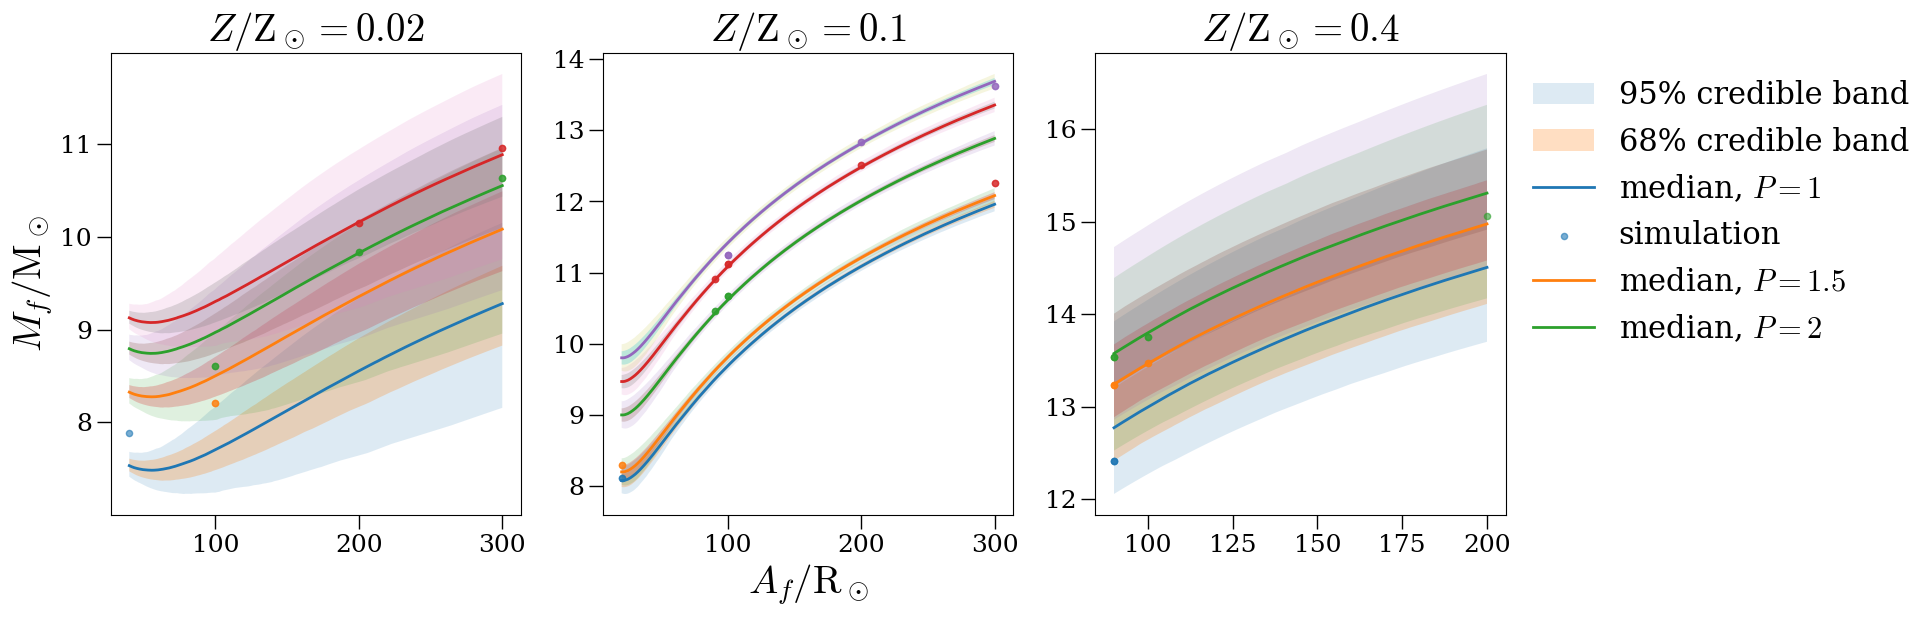

In [40]:
fig, axes = plt.subplots(1, 3, figsize=(18, 6))

for i, (zdivzsun_key, ax) in enumerate(zip(z_keys, axes)):
    legend = False if i < len(axes)-1 else True
    plot_delay_fixed_z(
        ax, final_m_dict, final_logtd_dict, zdivzsun_key,
        legend=legend, label_axes=False, p_list='all', log10_y=True
    )
    axes[0].set_ylabel('$M_f/\\mathrm{M}_\\odot$')
axes[1].set_xlabel(r'$A_f/\mathrm{R}_\odot$')

## Physics variations

In [ ]:
physics_pick = '02_weak_winds'
physics_model_dict = all_physics_dict[physics_pick]

In [ ]:
physics_data_path = nb_output_dir / f'{physics_pick}_final_var_dict.npy'
if physics_data_path.exists():
    mf_dict = pkl.load(open(physics_data_path, 'rb'))
else:
    mf_dict = get_final_var_dict(physics_model_dict)
    pkl.dump(mf_dict, open(physics_data_path, 'wb'))

Text(0.5, 0.98, 'Final Masses for 02_weak_winds Models')

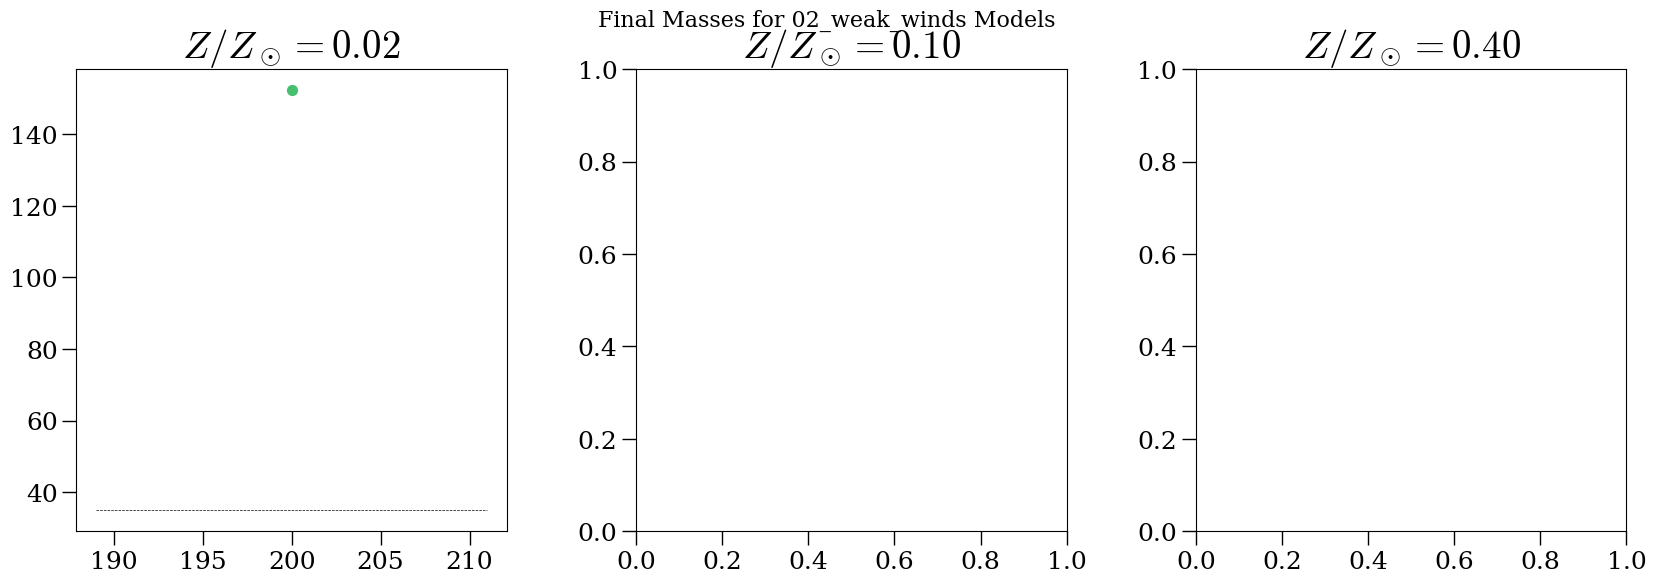

In [ ]:
min_p = 0.3
max_p = 2.0
cmap = cm.viridis

fig, axes = plt.subplots(1, 3, figsize=(20, 6))
fig.subplots_adjust(wspace=0.3)

z_keys = list(mf_dict.keys())
z_keys = sorted(z_keys, key=lambda x: float(x.replace('d', 'e')))
for i, zdivzsun in enumerate(z_keys):
    z_dict = mf_dict[zdivzsun]
    ax = axes[i]
    zdivzsun = float(zdivzsun.replace('d', 'e'))
    z_label = f'$Z/Z_\\odot = {zdivzsun:.2f}$'
    
    for j, (MI, m_dict) in enumerate(z_dict.items()):
        MI = float(MI.replace('d', 'e'))
        
        p_list = list(m_dict.keys())
        for p in p_list:
            Mf = m_dict[p]
            p = float(p)
            c = cmap(Normalize(vmin=min_p, vmax=max_p)(p))
            ax.scatter(MI, Mf, color=c, s=50)
        
    ax.set_title(z_label)
    y_up = ax.get_ylim()[1]
    if y_up > 35:
        ax.hlines(35, *ax.get_xlim(), color='k', linestyle='--', linewidth=0.5)
    
fig.suptitle(f'Final Masses for {physics_pick} Models', fontsize=16)

## Strong winds

In [ ]:
physics_pick = '03_strong_winds'
physics_model_dict = all_physics_dict[physics_pick]

In [ ]:
physics_data_path = nb_output_dir / f'{physics_pick}_final_var_dict.npy'
if physics_data_path.exists():
    mf_dict = pkl.load(open(physics_data_path, 'rb'))
else:
    mf_dict = get_final_var_dict(physics_model_dict)
    pkl.dump(mf_dict, open(physics_data_path, 'wb'))

Text(0.5, 0.98, 'Final Masses for 03_strong_winds Models')

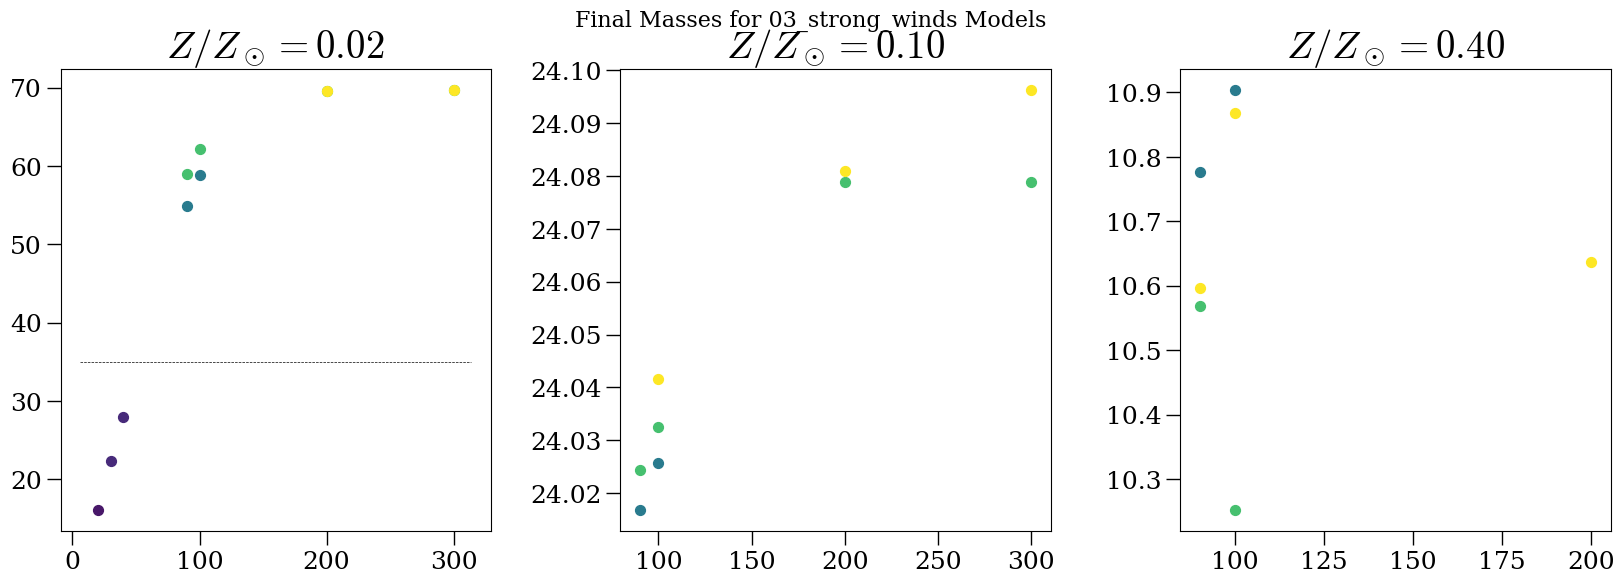

In [ ]:
min_p = 0.3
max_p = 2.0
cmap = cm.viridis

fig, axes = plt.subplots(1, 3, figsize=(20, 6))
fig.subplots_adjust(wspace=0.3)

z_keys = list(mf_dict.keys())
z_keys = sorted(z_keys, key=lambda x: float(x.replace('d', 'e')))
for i, zdivzsun in enumerate(z_keys):
    z_dict = mf_dict[zdivzsun]
    ax = axes[i]
    zdivzsun = float(zdivzsun.replace('d', 'e'))
    z_label = f'$Z/Z_\\odot = {zdivzsun:.2f}$'
    
    for j, (MI, m_dict) in enumerate(z_dict.items()):
        MI = float(MI.replace('d', 'e'))
        
        p_list = list(m_dict.keys())
        for p in p_list:
            Mf = m_dict[p]
            p = float(p)
            c = cmap(Normalize(vmin=min_p, vmax=max_p)(p))
            ax.scatter(MI, Mf, color=c, s=50)
        
    ax.set_title(z_label)
    y_up = ax.get_ylim()[1]
    if y_up > 35:
        ax.hlines(35, *ax.get_xlim(), color='k', linestyle='--', linewidth=0.5)
    
fig.suptitle(f'Final Masses for {physics_pick} Models', fontsize=16)

Text(0.5, 0, '$M_i/\\mathrm{M}_\\odot$')

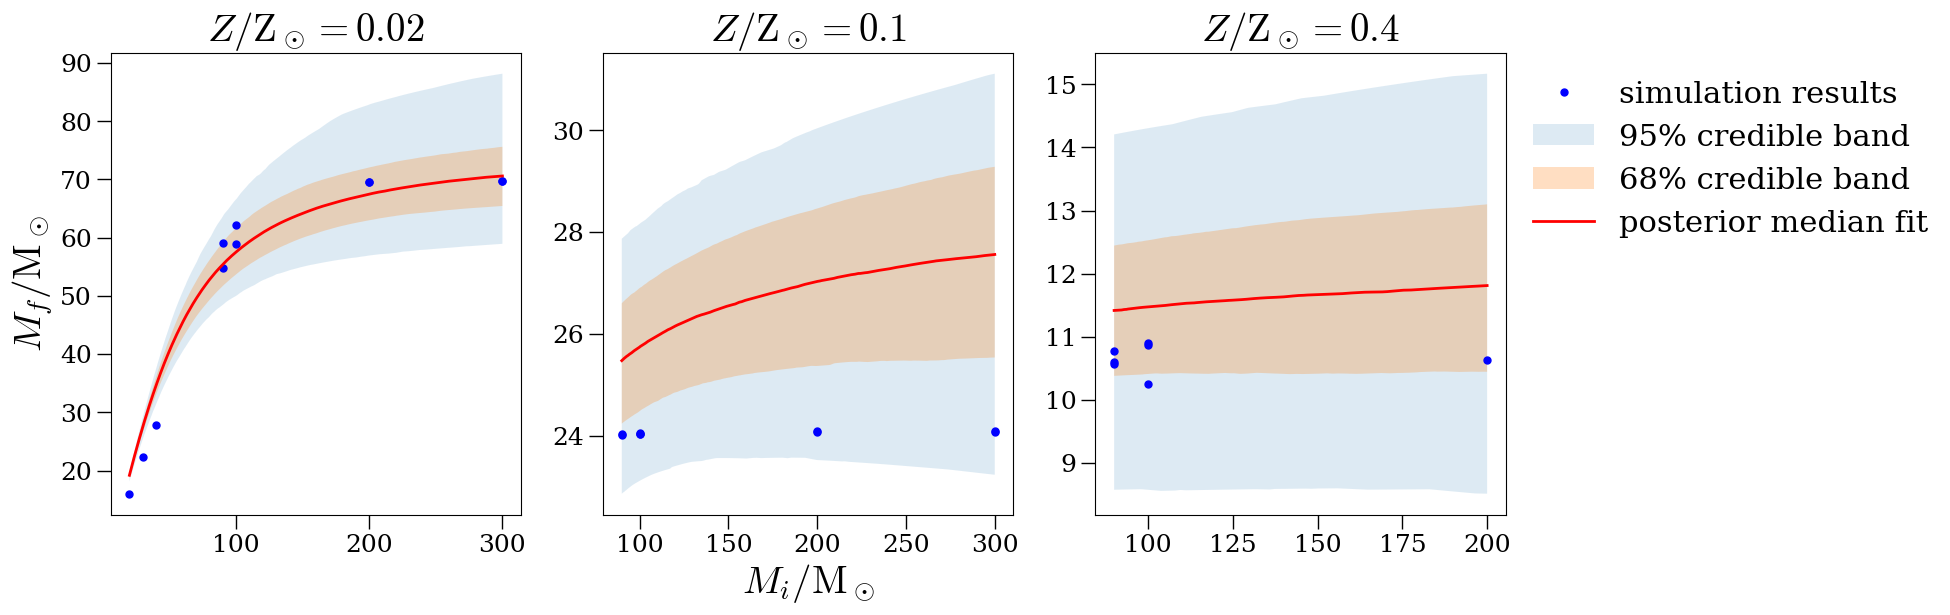

In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(18, 6))

multiplier_dict = default_multiplier_dict.copy()
multiplier_dict['mdot_r_mult'] = 2
multiplier_dict['alpha_add'] = 0.
multiplier_dict['beta_add'] = 0.

for i, (zdivzsun_key, ax) in enumerate(zip(z_keys, axes)):
    legend = False if i < len(axes)-1 else True
    plot_fixed_z(ax, mf_dict, zdivzsun_key, multiplier_dict=multiplier_dict, legend=legend, label_axes=False)
axes[0].set_ylabel('$M_f/\\mathrm{M}_\\odot$')
axes[1].set_xlabel('$M_i/\\mathrm{M}_\\odot$')

## Flat winds

In [ ]:
physics_pick = '04_flat_m_winds'
physics_model_dict = all_physics_dict[physics_pick]

In [ ]:
physics_data_path = nb_output_dir / f'{physics_pick}_final_var_dict.npy'
if physics_data_path.exists():
    mf_dict = pkl.load(open(physics_data_path, 'rb'))
else:
    mf_dict = get_final_var_dict(physics_model_dict)
    pkl.dump(mf_dict, open(physics_data_path, 'wb'))

Text(0.5, 0.98, 'Final Masses for 04_flat_m_winds Models')

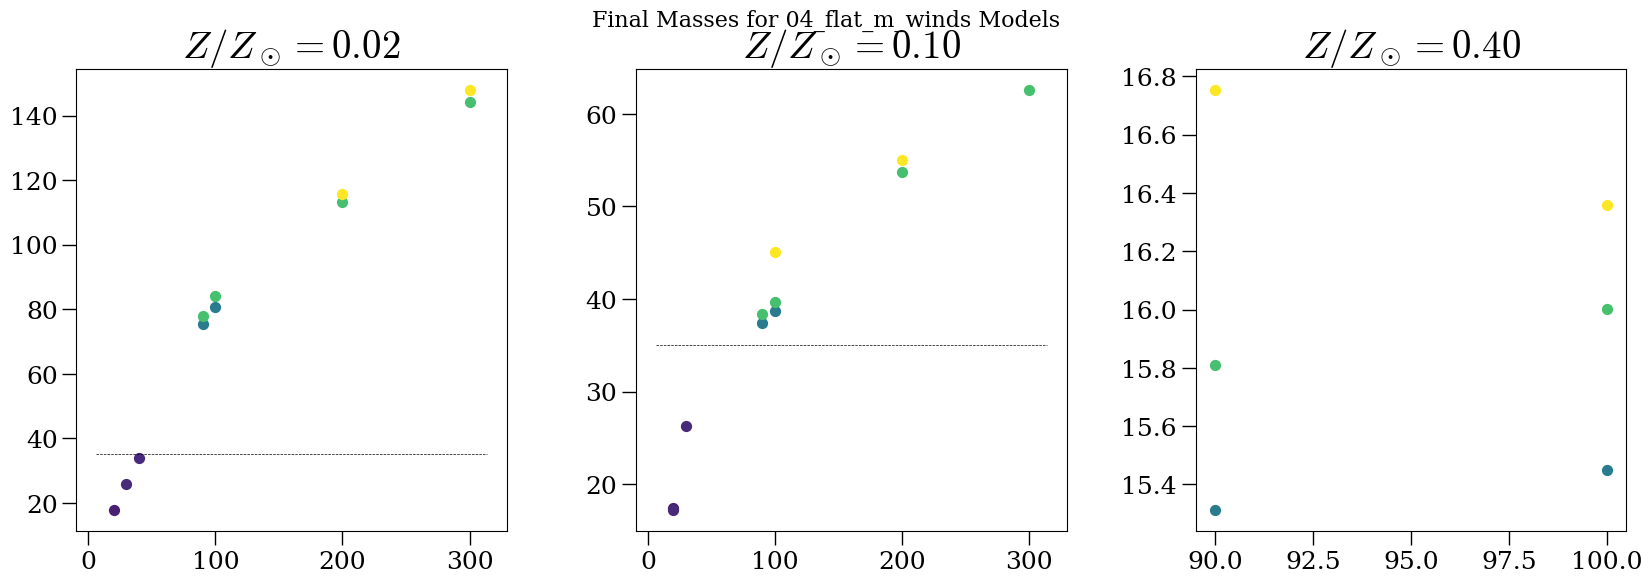

In [ ]:
min_p = 0.3
max_p = 2.0
cmap = cm.viridis

fig, axes = plt.subplots(1, 3, figsize=(20, 6))
fig.subplots_adjust(wspace=0.3)

z_keys = list(mf_dict.keys())
z_keys = sorted(z_keys, key=lambda x: float(x.replace('d', 'e')))
for i, zdivzsun in enumerate(z_keys):
    z_dict = mf_dict[zdivzsun]
    ax = axes[i]
    zdivzsun = float(zdivzsun.replace('d', 'e'))
    z_label = f'$Z/Z_\\odot = {zdivzsun:.2f}$'
    
    for j, (MI, m_dict) in enumerate(z_dict.items()):
        MI = float(MI.replace('d', 'e'))
        
        p_list = list(m_dict.keys())
        for p in p_list:
            Mf = m_dict[p]
            p = float(p)
            c = cmap(Normalize(vmin=min_p, vmax=max_p)(p))
            ax.scatter(MI, Mf, color=c, s=50)
        
    ax.set_title(z_label)
    y_up = ax.get_ylim()[1]
    if y_up > 35:
        ax.hlines(35, *ax.get_xlim(), color='k', linestyle='--', linewidth=0.5)
    
fig.suptitle(f'Final Masses for {physics_pick} Models', fontsize=16)

Text(0.5, 0, '$M_i/\\mathrm{M}_\\odot$')

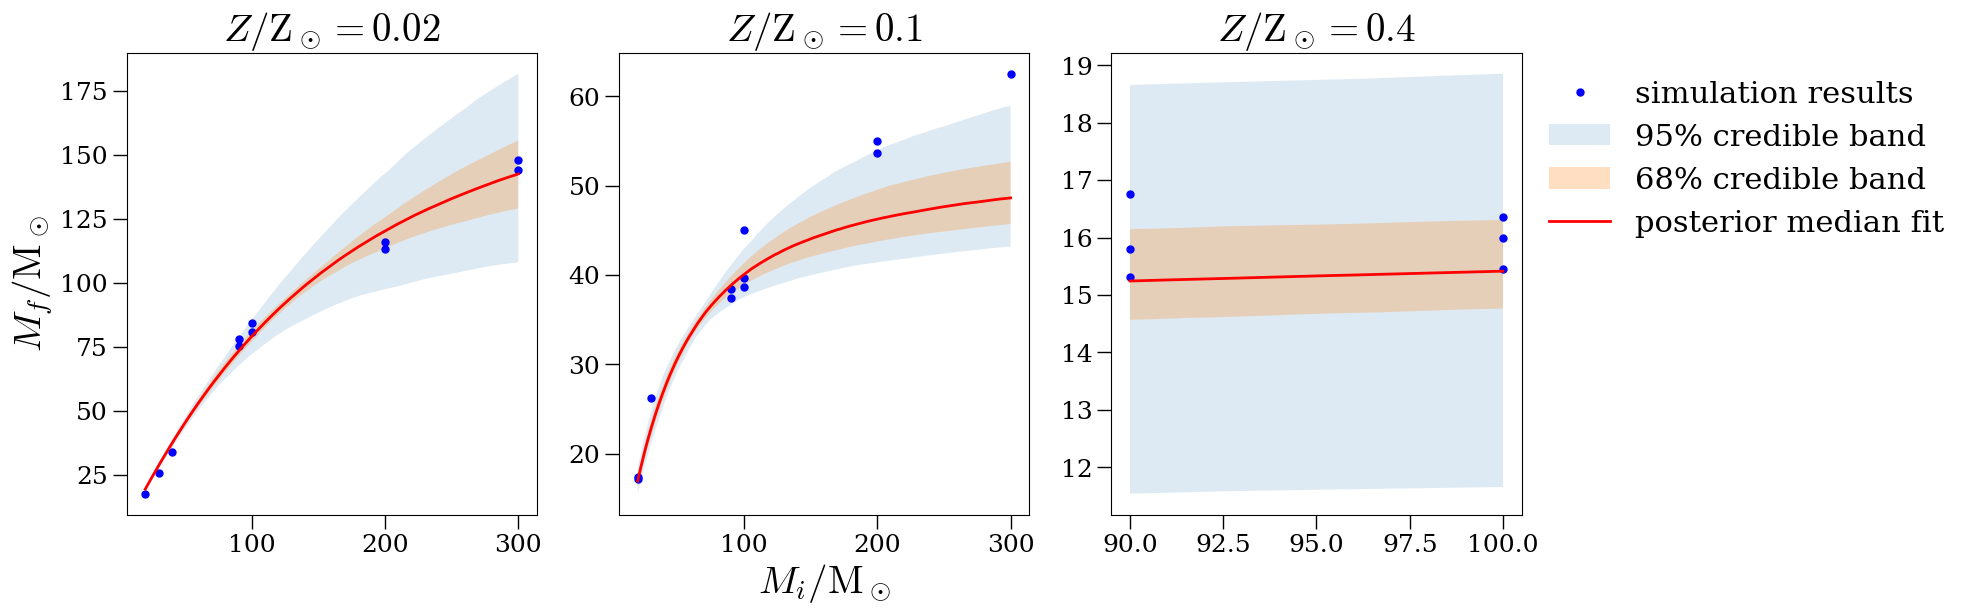

In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(18, 6))

multiplier_dict = default_multiplier_dict.copy()
multiplier_dict['mdot_r_mult'] = 1.
multiplier_dict['alpha_add'] = 0.
multiplier_dict['beta_add'] = -0.5

for i, (zdivzsun_key, ax) in enumerate(zip(z_keys, axes)):
    legend = False if i < len(axes)-1 else True
    plot_fixed_z(ax, mf_dict, zdivzsun_key, multiplier_dict=multiplier_dict, legend=legend, label_axes=False)
axes[0].set_ylabel('$M_f/\\mathrm{M}_\\odot$')
axes[1].set_xlabel('$M_i/\\mathrm{M}_\\odot$')

## Steep winds

In [ ]:
physics_pick = '05_steep_m_winds'
physics_model_dict = all_physics_dict[physics_pick]

In [ ]:
physics_data_path = nb_output_dir / f'{physics_pick}_final_var_dict.npy'
if physics_data_path.exists():
    mf_dict = pkl.load(open(physics_data_path, 'rb'))
else:
    mf_dict = get_final_var_dict(physics_model_dict)
    pkl.dump(mf_dict, open(physics_data_path, 'wb'))

Text(0.5, 0.98, 'Final Masses for 05_steep_m_winds Models')

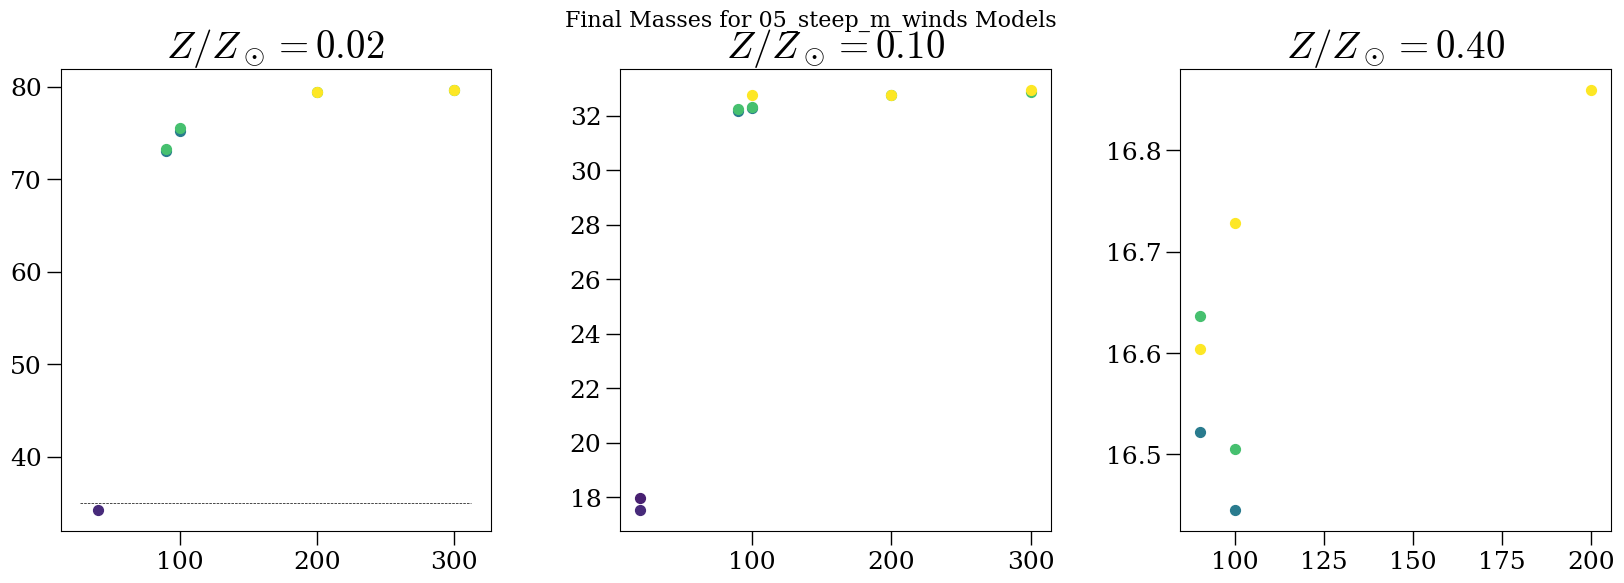

In [ ]:
min_p = 0.3
max_p = 2.0
cmap = cm.viridis

fig, axes = plt.subplots(1, 3, figsize=(20, 6))
fig.subplots_adjust(wspace=0.3)

z_keys = list(mf_dict.keys())
z_keys = sorted(z_keys, key=lambda x: float(x.replace('d', 'e')))
for i, zdivzsun in enumerate(z_keys):
    z_dict = mf_dict[zdivzsun]
    ax = axes[i]
    zdivzsun = float(zdivzsun.replace('d', 'e'))
    z_label = f'$Z/Z_\\odot = {zdivzsun:.2f}$'
    
    for j, (MI, m_dict) in enumerate(z_dict.items()):
        MI = float(MI.replace('d', 'e'))
        
        p_list = list(m_dict.keys())
        for p in p_list:
            Mf = m_dict[p]
            p = float(p)
            c = cmap(Normalize(vmin=min_p, vmax=max_p)(p))
            ax.scatter(MI, Mf, color=c, s=50)
        
    ax.set_title(z_label)
    y_up = ax.get_ylim()[1]
    if y_up > 35:
        ax.hlines(35, *ax.get_xlim(), color='k', linestyle='--', linewidth=0.5)
    
fig.suptitle(f'Final Masses for {physics_pick} Models', fontsize=16)

Text(0.5, 0, '$M_i/\\mathrm{M}_\\odot$')

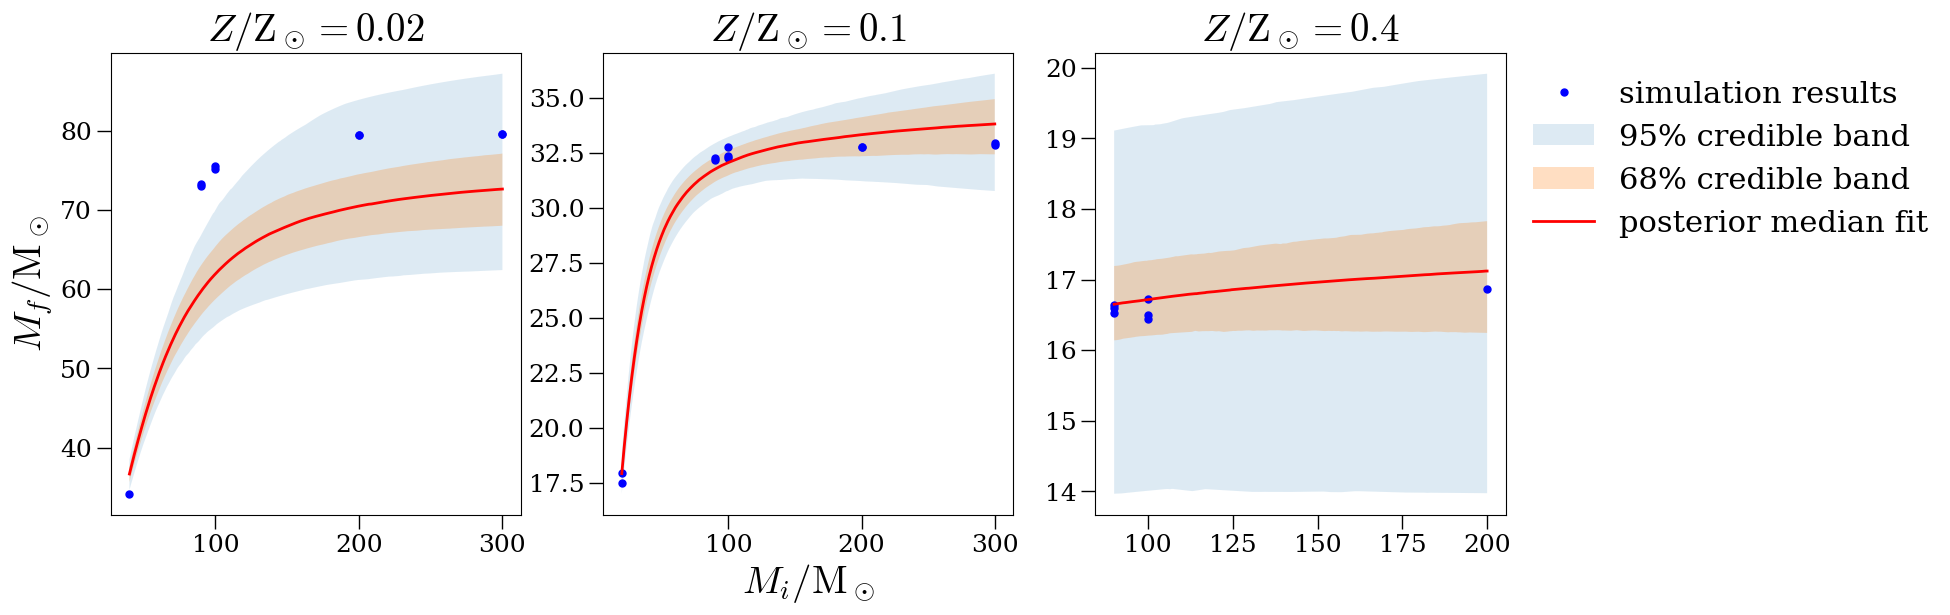

In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(18, 6))

multiplier_dict = default_multiplier_dict.copy()
multiplier_dict['mdot_r_mult'] = 1.
multiplier_dict['alpha_add'] = 0.
multiplier_dict['beta_add'] = 0.5

for i, (zdivzsun_key, ax) in enumerate(zip(z_keys, axes)):
    legend = False if i < len(axes)-1 else True
    plot_fixed_z(ax, mf_dict, zdivzsun_key, multiplier_dict=multiplier_dict, legend=legend, label_axes=False)
axes[0].set_ylabel('$M_f/\\mathrm{M}_\\odot$')
axes[1].set_xlabel('$M_i/\\mathrm{M}_\\odot$')

## Late wind

In [ ]:
physics_pick = '08_late_wind_transition'
physics_model_dict = all_physics_dict[physics_pick]

In [ ]:
physics_data_path = nb_output_dir / f'{physics_pick}_final_var_dict.npy'
if physics_data_path.exists():
    mf_dict = pkl.load(open(physics_data_path, 'rb'))
else:
    mf_dict = get_final_var_dict(physics_model_dict)
    pkl.dump(mf_dict, open(physics_data_path, 'wb'))

Text(0.5, 0.98, 'Final Masses for 08_late_wind_transition Models')

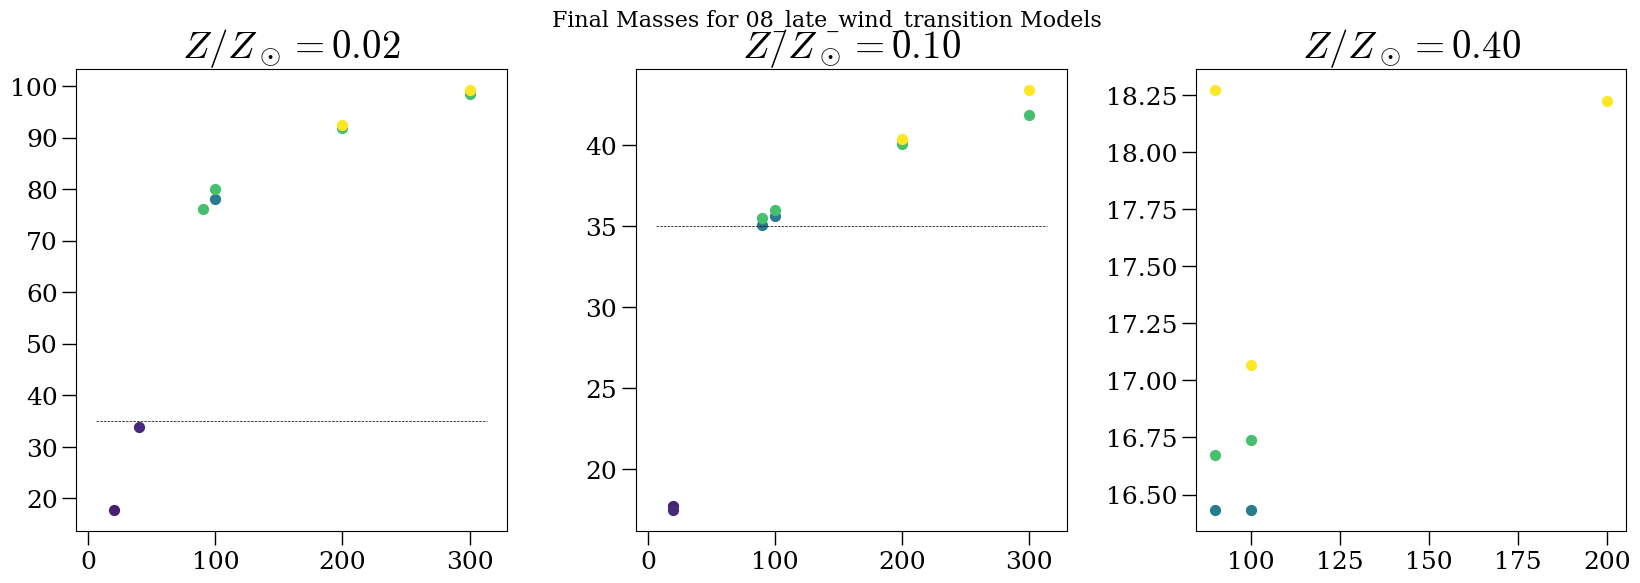

In [ ]:
min_p = 0.3
max_p = 2.0
cmap = cm.viridis

fig, axes = plt.subplots(1, 3, figsize=(20, 6))
fig.subplots_adjust(wspace=0.3)

z_keys = list(mf_dict.keys())
z_keys = sorted(z_keys, key=lambda x: float(x.replace('d', 'e')))
for i, zdivzsun in enumerate(z_keys):
    z_dict = mf_dict[zdivzsun]
    ax = axes[i]
    zdivzsun = float(zdivzsun.replace('d', 'e'))
    z_label = f'$Z/Z_\\odot = {zdivzsun:.2f}$'
    
    for j, (MI, m_dict) in enumerate(z_dict.items()):
        MI = float(MI.replace('d', 'e'))
        
        p_list = list(m_dict.keys())
        for p in p_list:
            Mf = m_dict[p]
            p = float(p)
            c = cmap(Normalize(vmin=min_p, vmax=max_p)(p))
            ax.scatter(MI, Mf, color=c, s=50)
        
    ax.set_title(z_label)
    y_up = ax.get_ylim()[1]
    if y_up > 35:
        ax.hlines(35, *ax.get_xlim(), color='k', linestyle='--', linewidth=0.5)
    
fig.suptitle(f'Final Masses for {physics_pick} Models', fontsize=16)

Text(0.5, 0, '$M_i/\\mathrm{M}_\\odot$')

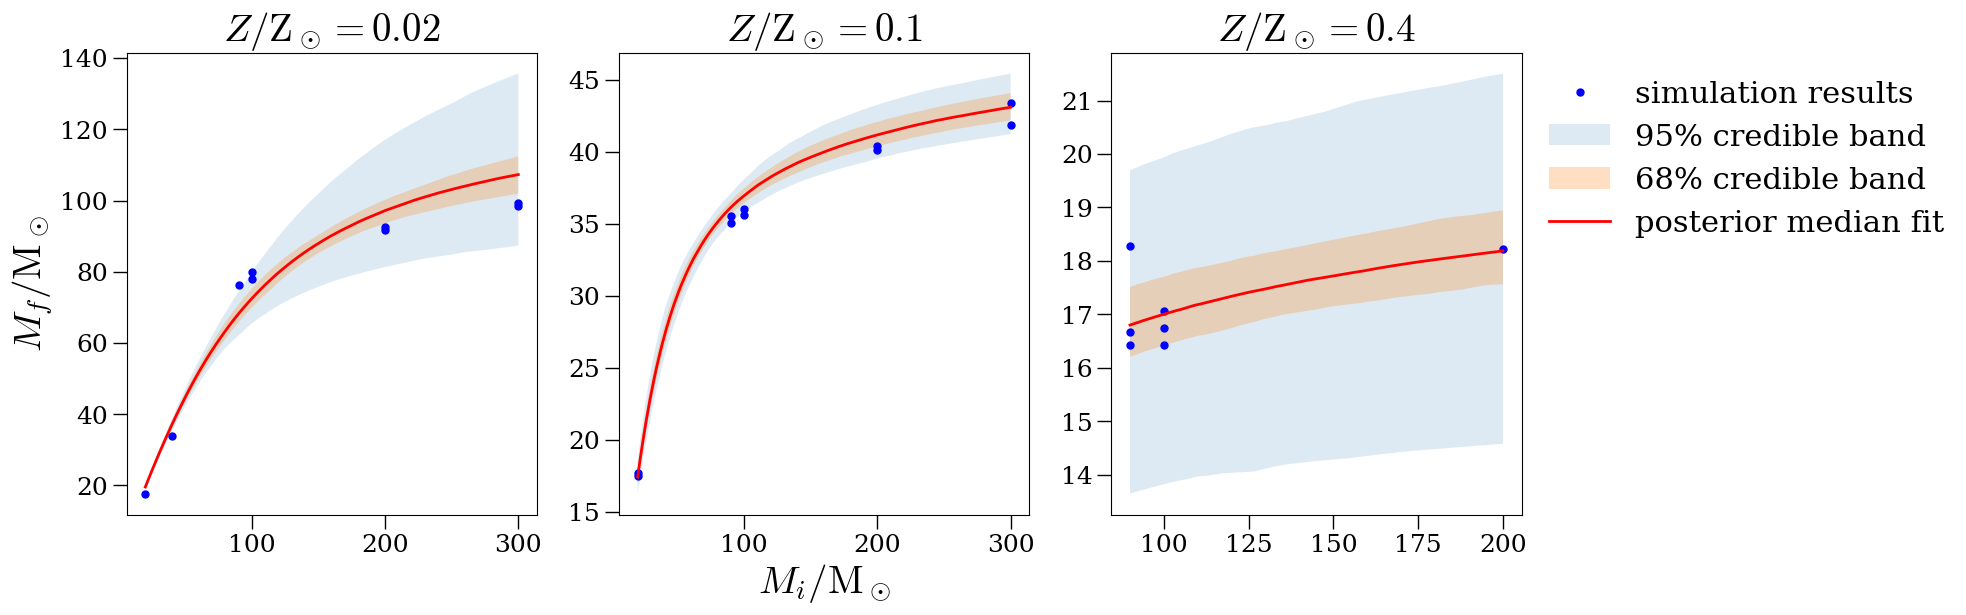

In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(18, 6))

multiplier_dict = default_multiplier_dict.copy()
multiplier_dict['mdot_r_mult'] = 1.
multiplier_dict['alpha_add'] = 0.1
multiplier_dict['beta_add'] = 0.

for i, (zdivzsun_key, ax) in enumerate(zip(z_keys, axes)):
    legend = False if i < len(axes)-1 else True
    plot_fixed_z(ax, mf_dict, zdivzsun_key, multiplier_dict=multiplier_dict, legend=legend, label_axes=False)
axes[0].set_ylabel('$M_f/\\mathrm{M}_\\odot$')
axes[1].set_xlabel('$M_i/\\mathrm{M}_\\odot$')

## Early wind

In [ ]:
physics_pick = '09_early_wind_transition'
physics_model_dict = all_physics_dict[physics_pick]

In [ ]:
physics_data_path = nb_output_dir / f'{physics_pick}_final_var_dict.npy'
if physics_data_path.exists():
    mf_dict = pkl.load(open(physics_data_path, 'rb'))
else:
    mf_dict = get_final_var_dict(physics_model_dict)
    pkl.dump(mf_dict, open(physics_data_path, 'wb'))

Text(0.5, 0.98, 'Final Masses for 09_early_wind_transition Models')

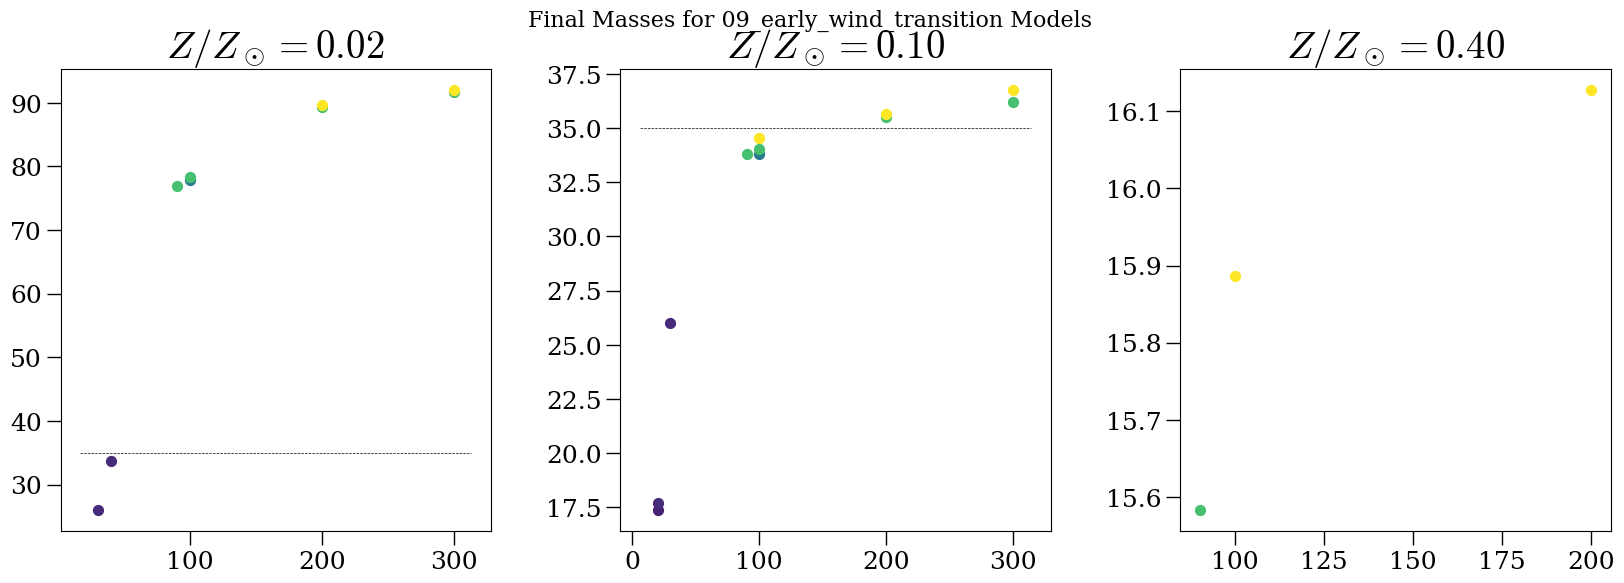

In [ ]:
min_p = 0.3
max_p = 2.0
cmap = cm.viridis

fig, axes = plt.subplots(1, 3, figsize=(20, 6))
fig.subplots_adjust(wspace=0.3)

z_keys = list(mf_dict.keys())
z_keys = sorted(z_keys, key=lambda x: float(x.replace('d', 'e')))
for i, zdivzsun in enumerate(z_keys):
    z_dict = mf_dict[zdivzsun]
    ax = axes[i]
    zdivzsun = float(zdivzsun.replace('d', 'e'))
    z_label = f'$Z/Z_\\odot = {zdivzsun:.2f}$'
    
    for j, (MI, m_dict) in enumerate(z_dict.items()):
        MI = float(MI.replace('d', 'e'))
        
        p_list = list(m_dict.keys())
        for p in p_list:
            Mf = m_dict[p]
            p = float(p)
            c = cmap(Normalize(vmin=min_p, vmax=max_p)(p))
            ax.scatter(MI, Mf, color=c, s=50)
        
    ax.set_title(z_label)
    y_up = ax.get_ylim()[1]
    if y_up > 35:
        ax.hlines(35, *ax.get_xlim(), color='k', linestyle='--', linewidth=0.5)
    
fig.suptitle(f'Final Masses for {physics_pick} Models', fontsize=16)

Text(0.5, 0, '$M_i/\\mathrm{M}_\\odot$')

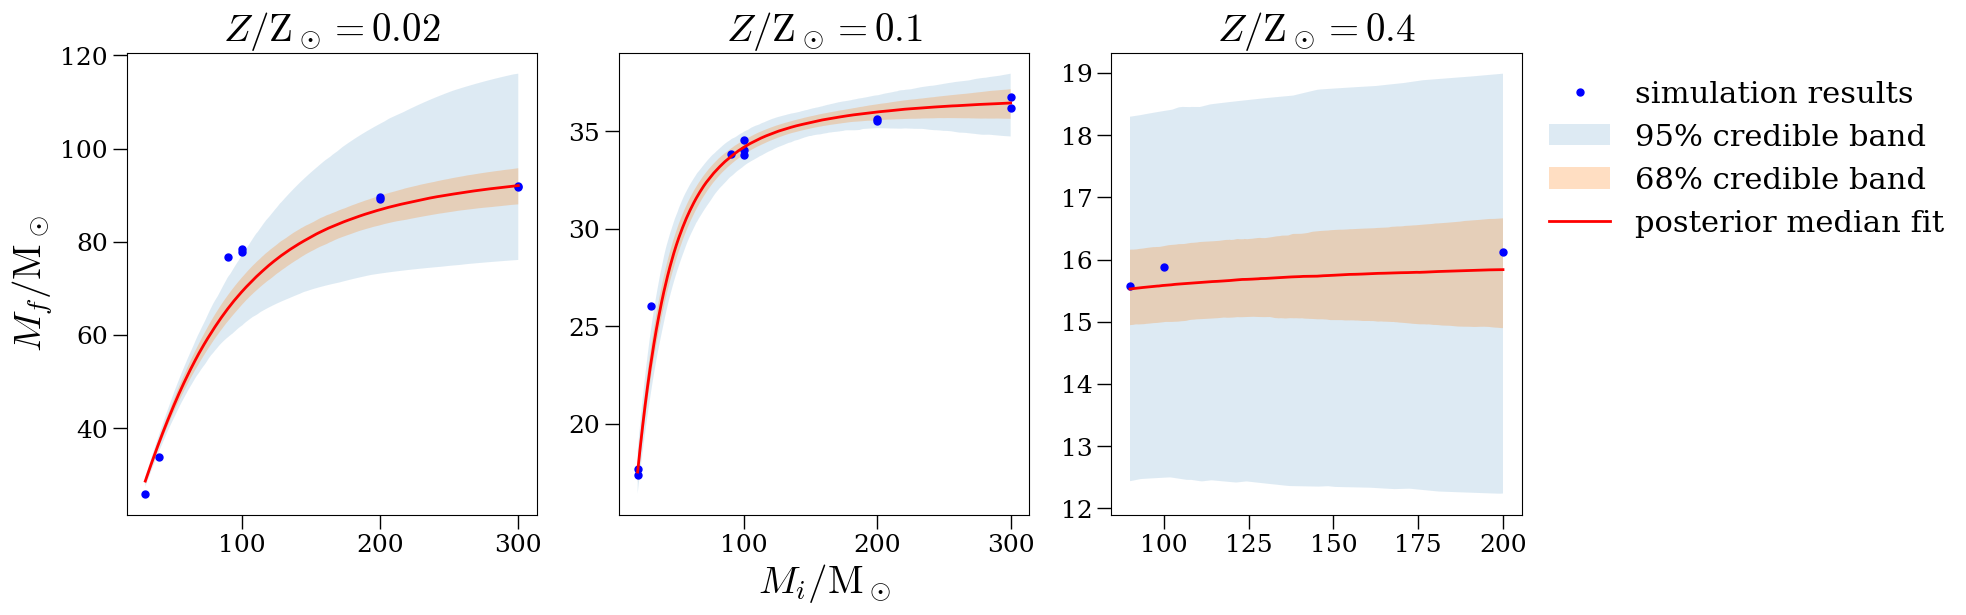

In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(18, 6))

multiplier_dict = default_multiplier_dict.copy()
multiplier_dict['mdot_r_mult'] = 1.
multiplier_dict['alpha_add'] = -0.05
multiplier_dict['beta_add'] = 0.

for i, (zdivzsun_key, ax) in enumerate(zip(z_keys, axes)):
    legend = False if i < len(axes)-1 else True
    plot_fixed_z(ax, mf_dict, zdivzsun_key, multiplier_dict=multiplier_dict, legend=legend, label_axes=False)
axes[0].set_ylabel('$M_f/\\mathrm{M}_\\odot$')
axes[1].set_xlabel('$M_i/\\mathrm{M}_\\odot$')

### Inefficient mixing

In [ ]:
physics_pick = '10_inefficient_mix'
physics_model_dict = all_physics_dict[physics_pick]

In [ ]:
physics_data_path = nb_output_dir / f'{physics_pick}_final_var_dict.npy'
if physics_data_path.exists():
    mf_dict = pkl.load(open(physics_data_path, 'rb'))
else:
    mf_dict = get_final_var_dict(physics_model_dict)
    pkl.dump(mf_dict, open(physics_data_path, 'wb'))

Text(0.5, 0.98, 'Final Masses for 10_inefficient_mix Models')

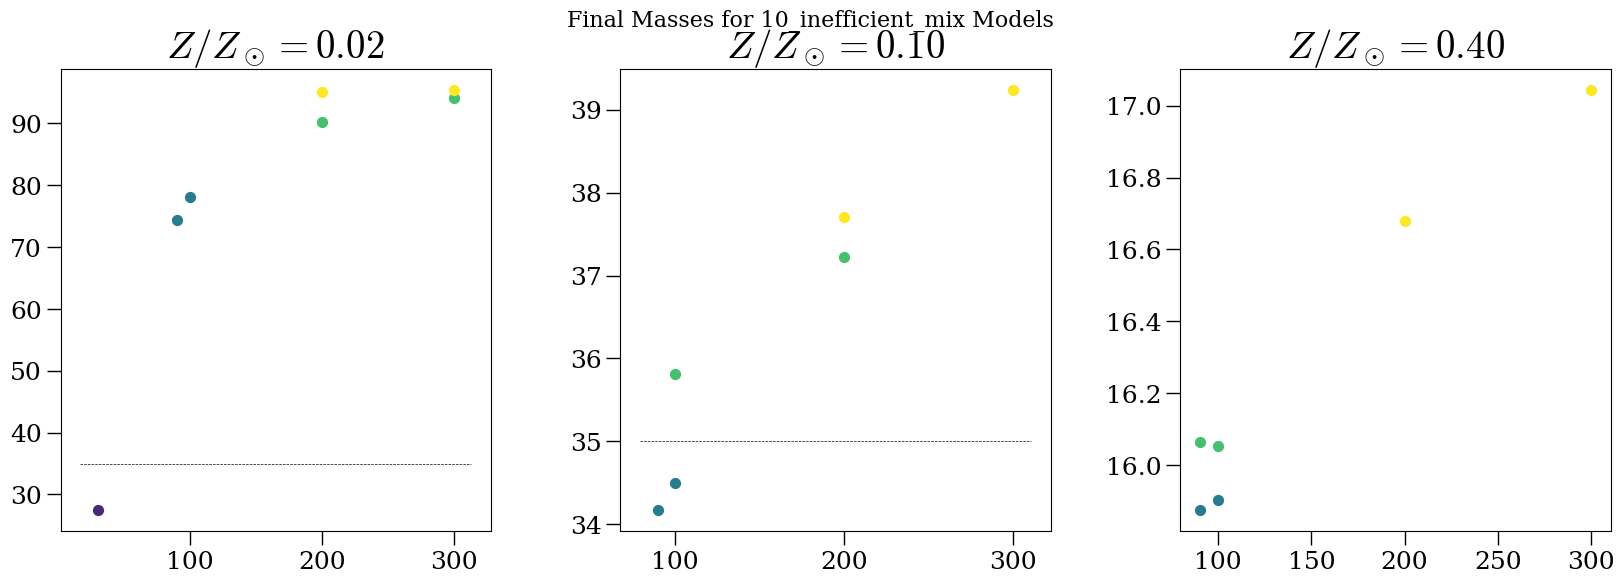

In [ ]:
min_p = 0.3
max_p = 2.0
cmap = cm.viridis

fig, axes = plt.subplots(1, 3, figsize=(20, 6))
fig.subplots_adjust(wspace=0.3)

z_keys = list(mf_dict.keys())
z_keys = sorted(z_keys, key=lambda x: float(x.replace('d', 'e')))
for i, zdivzsun in enumerate(z_keys):
    z_dict = mf_dict[zdivzsun]
    ax = axes[i]
    zdivzsun = float(zdivzsun.replace('d', 'e'))
    z_label = f'$Z/Z_\\odot = {zdivzsun:.2f}$'
    
    for j, (MI, m_dict) in enumerate(z_dict.items()):
        MI = float(MI.replace('d', 'e'))
        
        p_list = list(m_dict.keys())
        for p in p_list:
            Mf = m_dict[p]
            p = float(p)
            c = cmap(Normalize(vmin=min_p, vmax=max_p)(p))
            ax.scatter(MI, Mf, color=c, s=50)
        
    ax.set_title(z_label)
    y_up = ax.get_ylim()[1]
    if y_up > 35:
        ax.hlines(35, *ax.get_xlim(), color='k', linestyle='--', linewidth=0.5)
    
fig.suptitle(f'Final Masses for {physics_pick} Models', fontsize=16)

Text(0.5, 0, '$M_i/\\mathrm{M}_\\odot$')

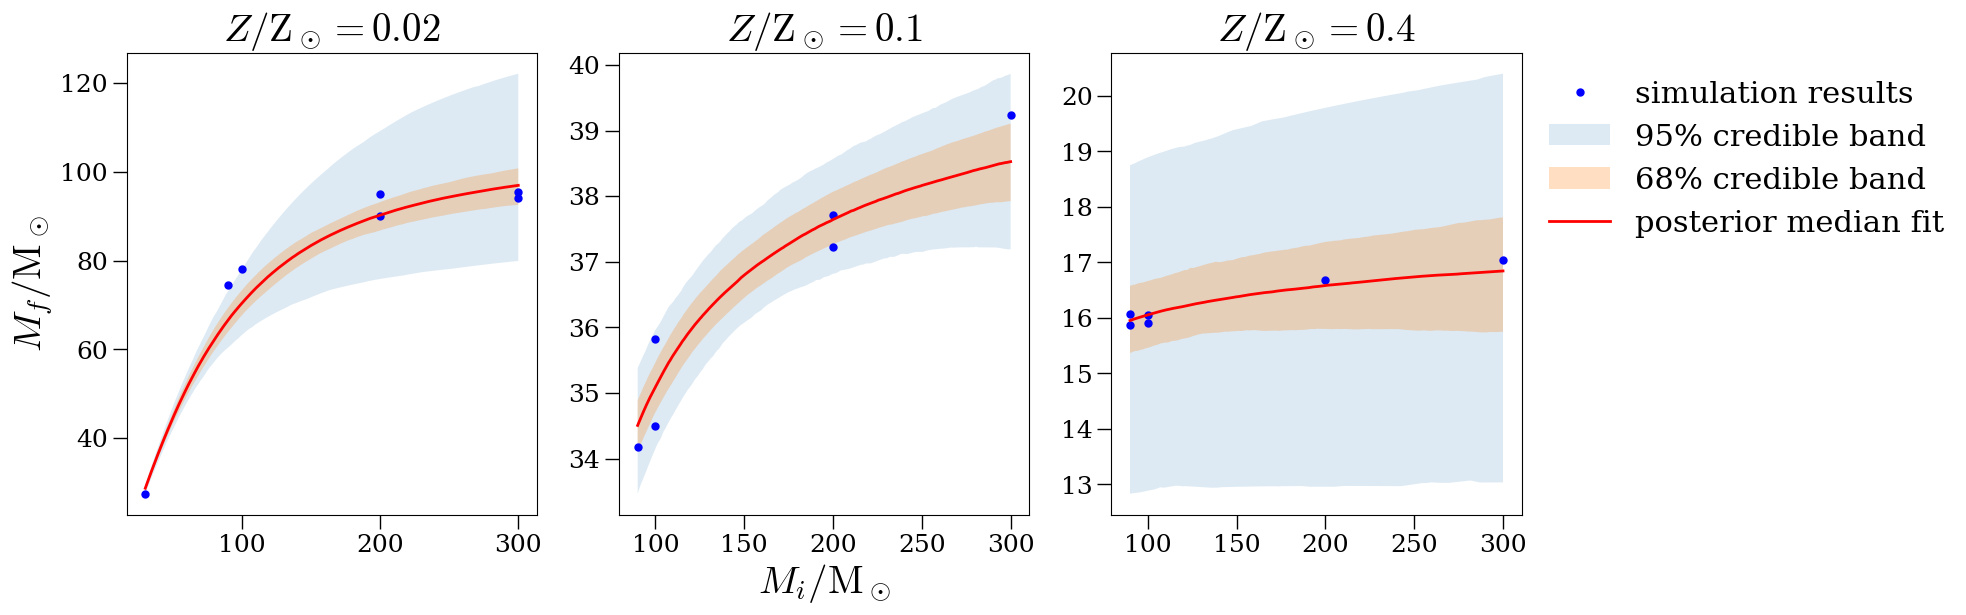

In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(18, 6))

multiplier_dict = default_multiplier_dict.copy()
multiplier_dict['mdot_r_mult'] = 1.
multiplier_dict['alpha_add'] = 0.
multiplier_dict['beta_add'] = 0.

for i, (zdivzsun_key, ax) in enumerate(zip(z_keys, axes)):
    legend = False if i < len(axes)-1 else True
    plot_fixed_z(ax, mf_dict, zdivzsun_key, multiplier_dict=multiplier_dict, legend=legend, label_axes=False)
axes[0].set_ylabel('$M_f/\\mathrm{M}_\\odot$')
axes[1].set_xlabel('$M_i/\\mathrm{M}_\\odot$')

## Inefficient mixing

In [ ]:
physics_pick = '11_efficient_mix'
physics_model_dict = all_physics_dict[physics_pick]

In [ ]:
physics_data_path = nb_output_dir / f'{physics_pick}_final_var_dict.npy'
if physics_data_path.exists():
    mf_dict = pkl.load(open(physics_data_path, 'rb'))
else:
    mf_dict = get_final_var_dict(physics_model_dict)
    pkl.dump(mf_dict, open(physics_data_path, 'wb'))

Text(0.5, 0.98, 'Final Masses for 11_efficient_mix Models')

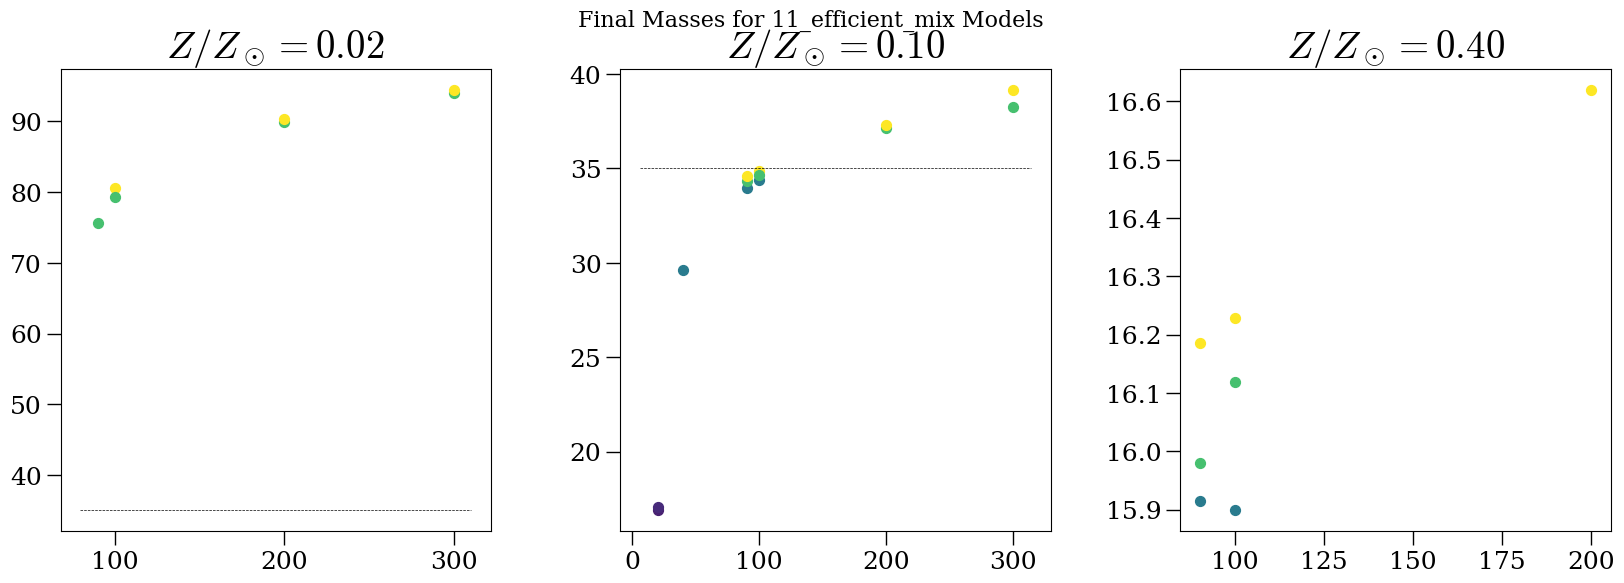

In [ ]:
min_p = 0.3
max_p = 2.0
cmap = cm.viridis

fig, axes = plt.subplots(1, 3, figsize=(20, 6))
fig.subplots_adjust(wspace=0.3)

z_keys = list(mf_dict.keys())
z_keys = sorted(z_keys, key=lambda x: float(x.replace('d', 'e')))
for i, zdivzsun in enumerate(z_keys):
    z_dict = mf_dict[zdivzsun]
    ax = axes[i]
    zdivzsun = float(zdivzsun.replace('d', 'e'))
    z_label = f'$Z/Z_\\odot = {zdivzsun:.2f}$'
    
    for j, (MI, m_dict) in enumerate(z_dict.items()):
        MI = float(MI.replace('d', 'e'))
        
        p_list = list(m_dict.keys())
        for p in p_list:
            Mf = m_dict[p]
            p = float(p)
            c = cmap(Normalize(vmin=min_p, vmax=max_p)(p))
            ax.scatter(MI, Mf, color=c, s=50)
        
    ax.set_title(z_label)
    y_up = ax.get_ylim()[1]
    if y_up > 35:
        ax.hlines(35, *ax.get_xlim(), color='k', linestyle='--', linewidth=0.5)
    
fig.suptitle(f'Final Masses for {physics_pick} Models', fontsize=16)

Text(0.5, 0, '$M_i/\\mathrm{M}_\\odot$')

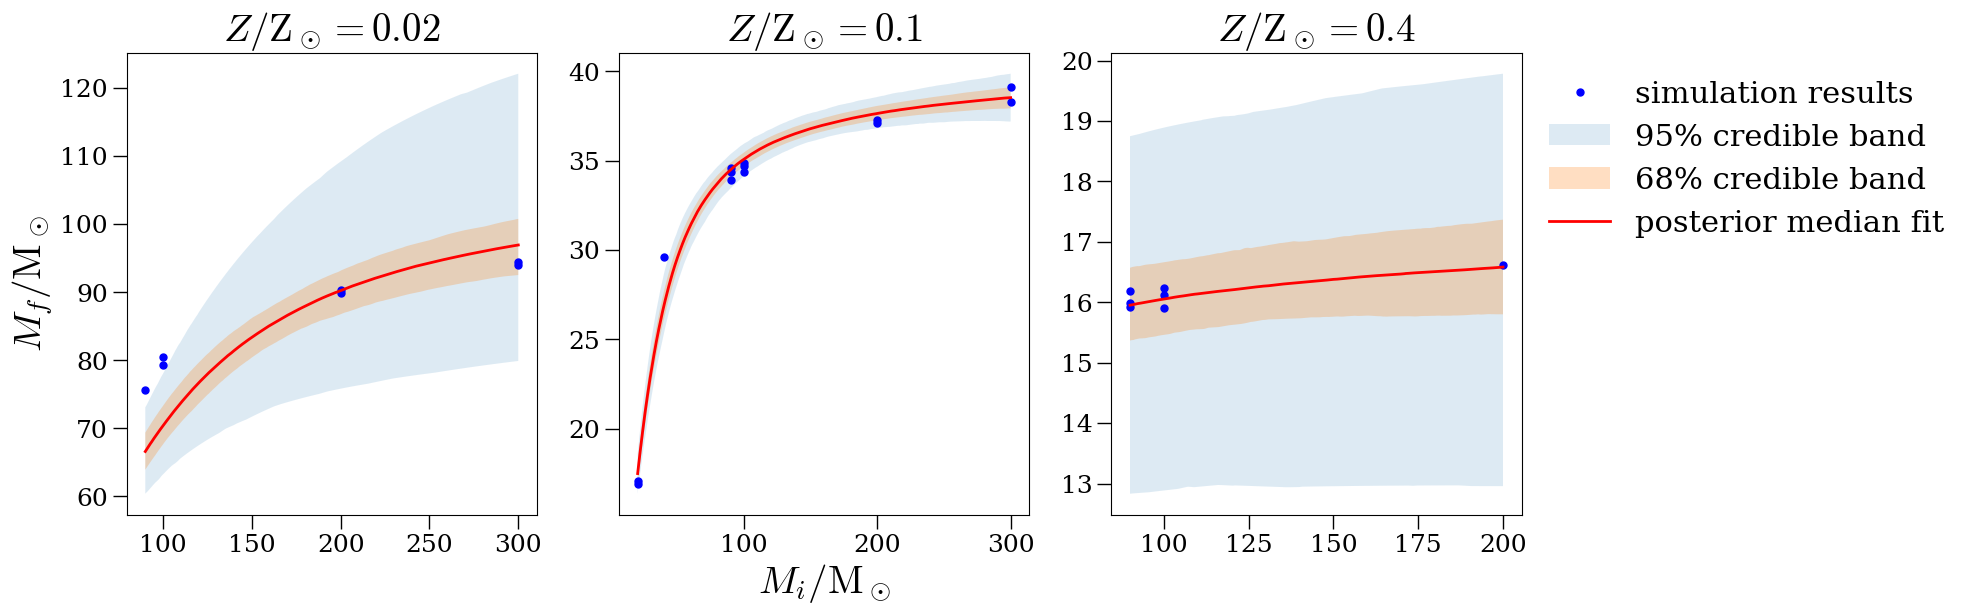

In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(18, 6))

multiplier_dict = default_multiplier_dict.copy()
multiplier_dict['mdot_r_mult'] = 1.
multiplier_dict['alpha_add'] = 0.
multiplier_dict['beta_add'] = 0.

for i, (zdivzsun_key, ax) in enumerate(zip(z_keys, axes)):
    legend = False if i < len(axes)-1 else True
    plot_fixed_z(ax, mf_dict, zdivzsun_key, multiplier_dict=multiplier_dict, legend=legend, label_axes=False)
axes[0].set_ylabel('$M_f/\\mathrm{M}_\\odot$')
axes[1].set_xlabel('$M_i/\\mathrm{M}_\\odot$')

# Predicting the final mass distribution

A properly calibrated analytical model allows us to compute the following derivative,

$$
\begin{equation}
\frac{\mathrm{d}m_i}{\mathrm{d}m_f} = \frac{(m_i/m_f)^\beta}{
    1 + \alpha \dot{m}_r \zeta^\gamma (m_i/m_f)^{\beta-(1+\alpha)}
    }.
\end{equation}
$$

With this in hand, we can easily find the distribution of final masses from CHE at a fixed metallicity, as

$$
\begin{equation}
\left.\frac{\mathrm{d}N_\mathrm{CHE}}{\mathrm{d}m_f}\right|_Z = \left.\frac{\mathrm{d}m_i}{\mathrm{d}m_f}\right|_Z
\overbrace{\frac{\mathrm{d}N_\mathrm{CHE}}{\mathrm{d}N}
 \frac{\mathrm{d}N}{\mathrm{d}m_i}}^{\xi_\mathrm{CHE}},
\end{equation}
$$

where

$$\begin{equation}
\frac{\mathrm{d}N}{\mathrm{d}m_i} \propto m_i^{-2.3}
\end{equation}$$

and

$$
\frac{\mathrm{d}N_\mathrm{CHE}}{\mathrm{d}N} = \frac{
    \int_{P_\mathrm{min}(m_i)}^{P_\mathrm{max}(m_i)}\mathrm{d}P\, 
   \frac{\mathrm{d}n}{\mathrm{d}P}}{
    \int_{P_\mathrm{min}(m_i)}^{10^8\,\mathrm{d}}\mathrm{d}P\, 
   \frac{\mathrm{d}n}{\mathrm{d}P}
   },
$$

with an appropriate distribution of birth periods, which we take as Öpik's law,

$$
\frac{\mathrm{d}n}{\mathrm{d}P} \propto \frac{1}{P}.
$$

With an appropriate metallicity over redshift distribution, we can get the final CHE mass distribution as

$$
\left.\frac{\mathrm{d}N_\mathrm{CHE}}{\mathrm{d}m_f}\right|_z  = \int \mathrm{d}Z\,\left.\frac{dP}{dZ}\right|_{Z} \frac{\mathrm{d}m_i}{\mathrm{d}m_f\mathrm{d}Z}
\frac{\mathrm{d}N_\mathrm{CHE}}{\mathrm{d}N}
 \frac{\mathrm{d}N}{\mathrm{d}m_i}
$$

In [ ]:

def dn_dmi(M_i):
    return M_i**-2.3

def dMi_dMf_from_Mi(Mi, Mf, Mdot_r, alpha, beta, gamma, zeta=1. ,Mr=30., tau_r=1e6):
    zeta = max(zeta, ZETA_MIN)
    mi = Mi / Mr
    mf = Mf / Mr
    mdot_r = Mdot_r / (Mr / tau_r)
    
    der = (
        (mi/mf)**beta
        / (1 + alpha * mdot_r * zeta**gamma * (mi/mf)**(beta-(1+alpha)))
    )
    
    return der

def dnche_dn(M_i, m_min=30., p_min=0.4, lower_slope=0.002, upper_slope=0.01):
    lower_intercept = p_min - lower_slope * m_min
    upper_intercept = p_min - upper_slope * m_min
    
    min_che_p = lower_intercept + lower_slope * M_i
    max_che_p = upper_intercept + upper_slope * M_i
    
    dnche_dn = np.log(max_che_p/min_che_p) / np.log(1e8/min_che_p)

    dnche_dn = np.array([dnche_dn]).ravel()
    dnche_dn = np.max((dnche_dn, np.tile(0, len(dnche_dn))), axis=0)
    return dnche_dn

def dnche_dmi(M_i, m_min=30., p_min=0.4, lower_slope=0.002, upper_slope=0.01):
    return (dnche_dn(M_i, m_min, p_min, lower_slope, upper_slope)
            * dn_dmi(M_i))

def dnche_dmf(m_i_arr, m_f_arr, Mdot_r, alpha, beta, gamma, zeta=1., M_r=30., tau_r=1e6, che_m_min=30., che_p_min=0.4, che_lower_slope=0.002, che_upper_slope=0.01):
    return (dMi_dMf_from_Mi(m_i_arr, m_f_arr, Mdot_r, alpha, beta, gamma, zeta, M_r, tau_r) 
            * dn_dmi(m_i_arr)
            * dnche_dn(m_i_arr, che_m_min, che_p_min, che_lower_slope, che_upper_slope))
    
@np.vectorize
def safe_log10(x):
    if np.isinf(x) or x == 0.:
        return np.nan
    else:
        return np.log10(x)

In [ ]:
def plot_fixed_z_dnche(ax, final_var_dict, zdivzsun_key, multiplier_dict=default_multiplier_dict, legend=False, 
                 label_axes=False, mi_plot_lims=(20, 300)):
    zdivzsun = float(zdivzsun_key.replace('d', 'e'))

    # 1) Build a smooth grid in Mi
    xg = np.linspace(*mi_plot_lims, 300)
    
    # 2) Pull posterior draws for parameters
    post = idata.posterior
    
    sigma_samps  = post["sigma"].stack(sample=("chain","draw")).values
    
    Mdot_r_samps = post["Mdot_r"].stack(sample=("chain","draw")).values
    Mdot_r_samps = Mdot_r_samps * multiplier_dict['mdot_r_mult'] + multiplier_dict['mdot_r_add']
    
    alpha_samps = post["alpha"].stack(sample=("chain","draw")).values
    alpha_samps = alpha_samps * multiplier_dict['alpha_mult'] + multiplier_dict['alpha_add']
    
    beta_samps = post["beta"].stack(sample=("chain","draw")).values
    beta_samps = beta_samps * multiplier_dict['beta_mult'] + multiplier_dict['beta_add']

    gamma_samps  = post["gamma"].stack(sample=("chain","draw")).values
    gamma_samps = gamma_samps * multiplier_dict['gamma_mult'] + multiplier_dict['gamma_add']

    # Optionally thin to speed up the predictive grid
    thin = min(2000, Mdot_r_samps.size)
    idx  = np.random.default_rng(0).choice(Mdot_r_samps.size, size=thin, replace=False)

    Mdot_r_samps = Mdot_r_samps[idx]
    alpha_samps  = alpha_samps[idx]
    beta_samps   = beta_samps[idx]
    sigma_samps  = sigma_samps[idx]
    gamma_samps = gamma_samps[idx]

    # 3) Evaluate the model on the grid for each draw
    #    (parameter-uncertainty only; comment IN the noise line below to include observation mismatch)
    Yg = np.empty((thin, xg.size))
    for i, (mr, a, b, g) in enumerate(zip(Mdot_r_samps, alpha_samps, beta_samps, gamma_samps)):
        xg2 = Mf_from_Mi(xg, mr, a, b, g, zeta=zdivzsun/0.1)
        y_mean = dnche_dmf(xg, xg2, mr, a, b, g, zeta=zdivzsun/0.1)
        # y = y_mean + np.random.normal(0, sigma_samps[i], size=xg.size)  # include noise if desired
        Yg[i] = y_mean

    # 4) Summaries for shaded bands
    q05, q16, q50, q84, q95 = np.percentile(Yg, [2.5, 16, 50, 84, 97.5], axis=0)

    # 5) Plot
    #ax.plot(X, Y, 'b.', markersize=10, label='simulation results')

    ax.fill_between(xg, q05, q95, alpha=0.15, label='95% credible band')
    ax.fill_between(xg, q16, q84, alpha=0.25, label='68% credible band')
    ax.plot(xg, q50, 'r-', lw=2, label='posterior median fit')
    
    if label_axes:
        ax.set_xlabel(r'$M_i/\mathrm{M}_\odot$')
        ax.set_ylabel(r'$M_f/\mathrm{M}_\odot$')
    if legend:
        ax.legend(frameon=False, loc='upper left', bbox_to_anchor=(1,1))
    ax.set_title(f'$Z/\\mathrm{{Z}}_\\odot = {zdivzsun:.2g}$')

In [ ]:
def plot_fixed_z_dnche_vs_mf_ensemble(
    ax,
    idata,
    final_var_dict,
    zdivzsun_key,
    multiplier_dict=default_multiplier_dict,
    legend=False,
    label_axes=False,
    mi_plot_lims=(20, 300),
    ensemble_step=50,      # plot every Nth draw to avoid clutter (smaller -> more lines)
    rng_seed=0,
):
    zdivzsun = float(zdivzsun_key.replace('d', 'e'))
    zeta = zdivzsun / 0.1

    # 1) Smooth grid in Mi
    Mi_grid = np.linspace(*mi_plot_lims, 300)

    # 2) Pull posterior draws (apply your multipliers)
    post = idata.posterior
    Mr_all = (post["Mdot_r"].values * multiplier_dict['mdot_r_mult'] + multiplier_dict['mdot_r_add']).ravel()
    a_all  = (post["alpha"].values  * multiplier_dict['alpha_mult'] + multiplier_dict['alpha_add']).ravel()
    b_all  = (post["beta"].values   * multiplier_dict['beta_mult']  + multiplier_dict['beta_add']).ravel()
    g_all  = (post["gamma"].values  * multiplier_dict['gamma_mult'] + multiplier_dict['gamma_add']).ravel()

    # 3) Median-of-parameters curve (your requested "median curve")
    Mr_med = np.median(Mr_all)
    a_med  = np.median(a_all)
    b_med  = np.median(b_all)
    g_med  = np.median(g_all)

    Mf_med = Mf_from_Mi(Mi_grid, Mr_med, a_med, b_med, g_med, zeta=zeta)
    y_med  = dnche_dmf(Mi_grid, Mf_med, Mr_med, a_med, b_med, g_med, zeta=zeta)

    # Sort by Mf so the line is monotone in x for plotting
    order_med = np.argsort(Mf_med)
    Mf_med_s  = Mf_med[order_med]
    y_med_s   = y_med[order_med]

    # 4) Ensemble (thin so it’s readable)
    n = Mr_all.size
    if ensemble_step is None or ensemble_step <= 0:
        idx = np.arange(n)
    else:
        # random thinning for visual variety
        rng = np.random.default_rng(rng_seed)
        keep = max(1, n // max(1, n // ensemble_step))  # approx n/ensemble_step lines
        idx = rng.choice(n, size=keep, replace=False)

    # Plot faint ensemble lines: x = Mf(Mi), y = dnche_dmf(Mi, Mf)
    for i in idx:
        Mr, a, b, g = float(Mr_all[i]), float(a_all[i]), float(b_all[i]), float(g_all[i])
        Mf_curve = Mf_from_Mi(Mi_grid, Mr, a, b, g, zeta=zeta)
        y_curve  = dnche_dmf(Mi_grid, Mf_curve, Mr, a, b, g, zeta=zeta)

        order = np.argsort(Mf_curve)           # ensure ascending x
        ax.plot(Mf_curve[order], y_curve[order], color="0.6", alpha=0.08, lw=1)

    # 5) Highlight the median-of-parameters curve
    ax.plot(Mf_med_s, y_med_s, "r-", lw=2.2, label="median params")

    # Axes/labels
    if label_axes:
        ax.set_xlabel(r"$M_f$")
        ax.set_ylabel(r"$\mathrm{d}n_{\rm che}/\mathrm{d}M_f$")
    if legend:
        ax.legend(frameon=False, loc='upper left', bbox_to_anchor=(1,1))
    ax.set_title(rf"$Z/\mathrm{{Z}}_\odot = {zdivzsun:.2g}$")

    # Optional: nice limits if needed
    # ax.set_xlim(np.nanmin(Mf_med_s), np.nanmax(Mf_med_s))


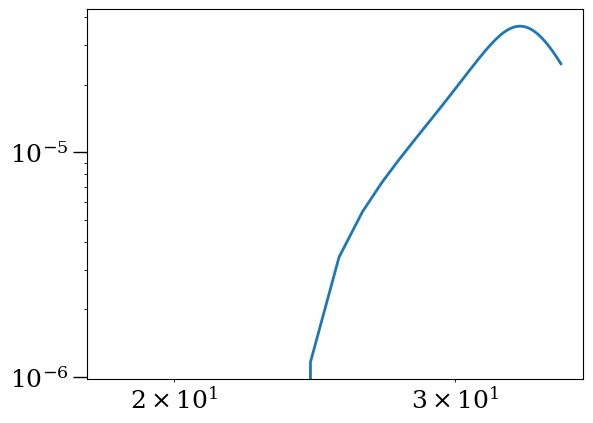

In [ ]:
xx  = np.linspace(20, 300, 100)
alpha = 0.2
beta  = 4.
gamma = 0.5
zdivzsun = 0.1
Mdot_r = 1e-5

xx2 = Mf_from_Mi(xx, Mdot_r, alpha, beta, gamma, zeta=zdivzsun/0.1)
yy  = dMi_dMf_from_Mi(xx, xx2, Mdot_r, alpha, beta, gamma, zeta=zdivzsun/0.1) * dn_dmi(xx) * dnche_dmi(xx)
yy = dnche_dmf(xx, xx2, Mdot_r, alpha, beta ,gamma, zeta=zdivzsun/0.1)

plt.plot(xx2, yy)
plt.xscale('log')
plt.yscale('log')

CPU times: user 417 ms, sys: 15.3 ms, total: 433 ms
Wall time: 431 ms


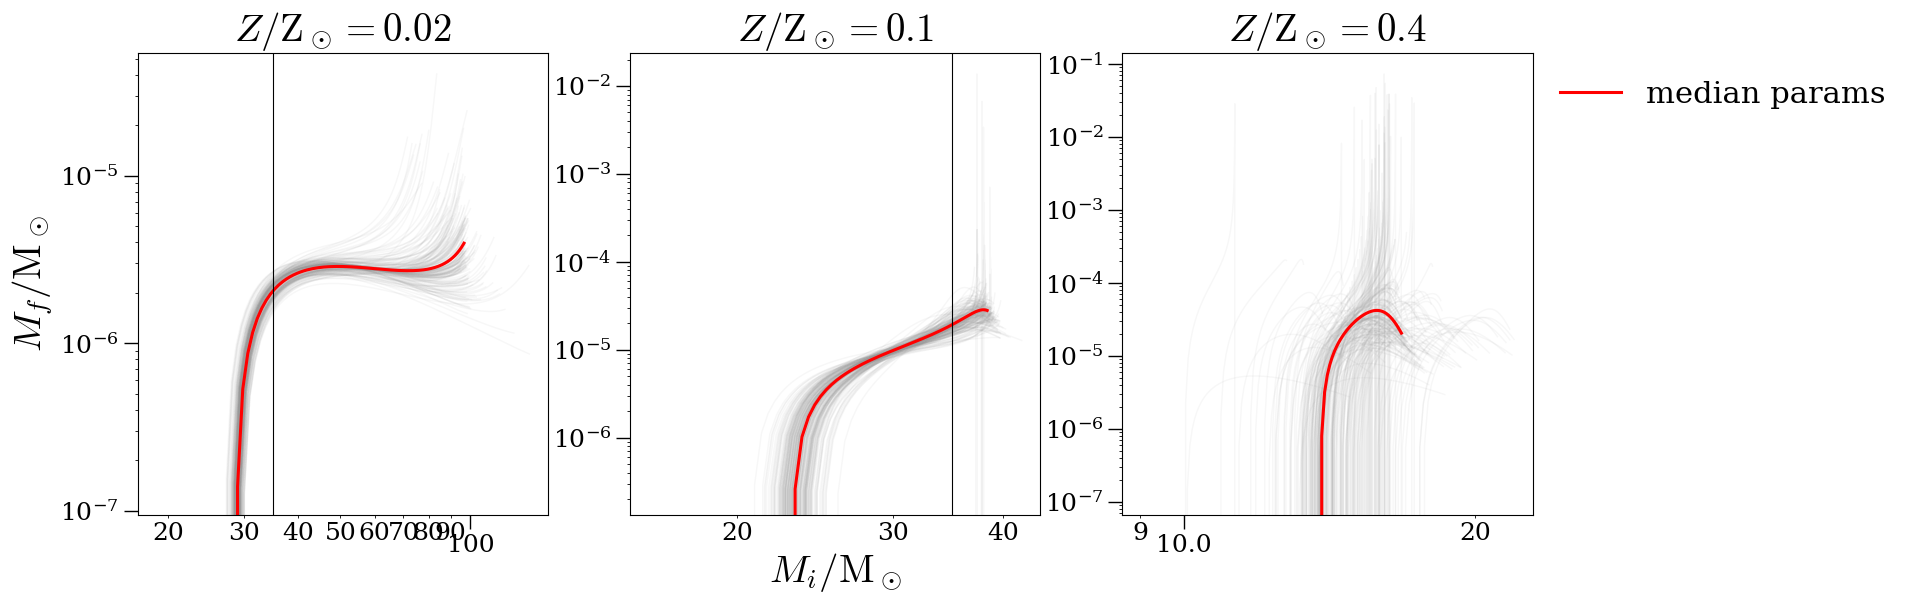

In [ ]:
%%time
fig, axes = plt.subplots(1, 3, figsize=(18, 6))

for i, (zdivzsun_key, ax) in enumerate(zip(z_keys, axes)):
    legend = False if i < len(axes)-1 else True
    plot_fixed_z_dnche_vs_mf_ensemble(ax, idata, final_var_dict, zdivzsun_key, legend=legend, label_axes=False, ensemble_step=200)
    axes[0].set_ylabel('$M_f/\\mathrm{M}_\\odot$')
axes[1].set_xlabel('$M_i/\\mathrm{M}_\\odot$')

for ax in axes:
    ax.set_yscale('log')
    ax.set_xscale('log')
    xlims = ax.get_xlim()
    ylims = ax.get_ylim()
    ax.vlines(35, *ylims, color='k', linewidth=0.8)
    ax.set_ylim(ylims)
    ax.set_xlim(xlims)
    
    # Force xticklabels to not use scientific notation
    formatter = ScalarFormatter(useMathText=False)
    formatter.set_scientific(False)
    ax.xaxis.set_major_formatter(formatter)
    ax.xaxis.set_minor_formatter(formatter)

We can now bring in the metallicity distribution.

In [ ]:
from scipy.stats import norm as NormDist

def find_metallicity_distribution(redshifts, min_logZ_COMPAS, max_logZ_COMPAS,
                                  mu0=0.035, muz=-0.23, sigma_0=0.39, 
                                  sigma_z=0.0, alpha=0.0, min_logZ=-12.0, 
                                  max_logZ=0.0, step_logZ=0.01):
    """
    Calculate the distribution of metallicities at different redshifts 
    using a log skew normal distribution. The log-normal distribution 
    is a special case of this log skew normal distribution and is 
    retrieved by setting the skewness to zero (alpha=0). Based on the 
    method in Neijssel+19. Default values retrieve the dP/dZ 
    distribution used in Neijssel+19. See van Son+2022 for skewed 
    log-normal distribution.

    NOTE: This assumes that metallicities in COMPAS are drawn from a 
    flat-in-log distribution!

    Args:
        max_redshift       --> [float] Max redshift for calculation
        redshift_step      --> [float] Step used in redshift calculation
        min_logZ_COMPAS    --> [float] Min logZ value that COMPAS samples
        max_logZ_COMPAS    --> [float] Max logZ value that COMPAS samples
        mu0                --> [float] Location (mean in normal) at z=0
        muz                --> [float] Redshift scaling of location
        sigma_0            --> [float] Scale (variance in normal) at z=0
        sigma_z            --> [float] Redshift scaling of the scale
        alpha              --> [float] Shape (skewness, alpha=0 gives 
                                  normal dist as in Neijssel+19)
        min_logZ           --> [float] Min logZ for dPdlogZ calculation
        max_logZ           --> [float] Max logZ for dPdlogZ calculation
        step_logZ          --> [float] Step size for logZ range

    Returns:
        dPdlogZ            --> [2D float array] Probability of getting a 
                                  particular logZ at a certain redshift
        metallicities      --> [list of floats] Metallicities at which 
                                  dPdlogZ is evaluated
        p_draw_metallicity --> [float] Probability of drawing a certain 
                                  metallicity in COMPAS
    """
    # Log-linear redshift dependence of sigma
    sigma = sigma_0 * 10**(sigma_z * redshifts)

    # Mean metallicities evolve with redshift (Langer & Norman 2006)
    mean_metallicities = mu0 * 10**(muz * redshifts)

    # Rewrite expected value of log-skew-normal to retrieve mu
    beta = alpha / (np.sqrt(1 + alpha**2))
    PHI = NormDist.cdf(beta * sigma)
    mu_metallicities = np.log(mean_metallicities / 2. / 
                              (np.exp(0.5 * sigma**2) * PHI))

    # Create a range of metallicities (x-values or random variables)
    log_metallicities = np.arange(min_logZ, max_logZ + step_logZ, step_logZ)
    metallicities = np.exp(log_metallicities)

    # Probabilities of log-skew-normal (without 1/Z factor)
    dPdlogZ = (2. / sigma[:, np.newaxis] * 
               NormDist.pdf((log_metallicities - mu_metallicities[:, np.newaxis]) / sigma[:, np.newaxis]) * 
               NormDist.cdf(alpha * (log_metallicities - mu_metallicities[:, np.newaxis]) / sigma[:, np.newaxis]))

    # Normalize distribution over all metallicities
    norm = dPdlogZ.sum(axis=-1) * step_logZ
    dPdlogZ = dPdlogZ / norm[:, np.newaxis]

    # Flat-in-log distribution for sampled metallicity in COMPAS
    p_draw_metallicity = 1 / (max_logZ_COMPAS - min_logZ_COMPAS)

    return dPdlogZ, metallicities, p_draw_metallicity


In [ ]:
min_redshift = 0.
max_redshift = 10.
redshift_step = 1.
redshifts = np.arange(min_redshift, max_redshift + redshift_step, redshift_step)
Z_arr = np.logspace(-3, 0, 10) * Z_SUN

# van Son et al. (2023) ApJ 948 105 Tab 1
mu0 = 0.025
muz = -0.049
sigma0 = 1.122
sigmaz = 0.049
alpha = -1.778
min_logZ = -12.0
max_logZ = -5. 
step_logZ = 0.01

min_Z = Z_arr.min()
max_Z = Z_arr.max()

dPdlogZ, metallicities, p_draw_metallicity = find_metallicity_distribution(
    redshifts=redshifts,
    min_logZ_COMPAS=np.log(min_Z),
    max_logZ_COMPAS=np.log(max_Z),
    mu0=mu0,
    muz=muz,
    sigma_0=sigma0,
    sigma_z=sigmaz,
    alpha=alpha,
    min_logZ=min_logZ,
    max_logZ=max_logZ,
    step_logZ=step_logZ
)

In [ ]:
np.exp(-5)/Z_SUN

0.3963498234756157

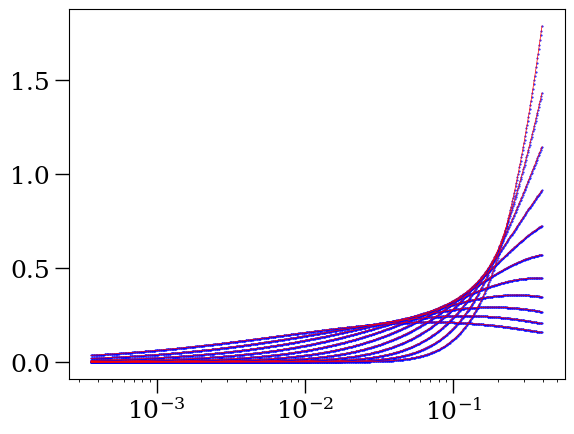

In [ ]:
for arr in dPdlogZ:
    ip = CubicSpline(metallicities, arr)
    plt.scatter(metallicities/Z_SUN, arr, c='b', marker='.', s=1)
    plt.plot(metallicities/Z_SUN, ip(metallicities), c='r', lw=0.5)
plt.xscale('log')
#plt.yscale('log')

In [ ]:
def metallicity_convolve(
    redshift_arr,
    m_i_arr,
    Mdot_r,
    Z_arr,
    alpha,
    beta,
    gamma,
    m_i_lims=(20, 300),
    M_r=30.,
    tau_r=1e6,
    mu0=0.025,
    muz=-0.049,
    sigma0=1.122,
    sigmaz=0.049,
    alphaz=-1.778,
    min_logZ=-12.0,
    max_logZ=0.0,
    step_logZ=0.01
    ):
    
    min_Z = Z_arr.min()
    max_Z = Z_arr.max()
    
    dPdlogZ, metallicities, _ = find_metallicity_distribution(
                    redshifts=redshift_arr,
                    min_logZ_COMPAS=np.log(min_Z), # yes ln not log10
                    max_logZ_COMPAS=np.log(max_Z), # yes ln not log10
                    mu0=mu0,
                    muz=muz,
                    sigma_0=sigma0,
                    sigma_z=sigmaz,
                    alpha=alphaz,
                    min_logZ=min_logZ,
                    max_logZ=max_logZ,
                    step_logZ=step_logZ
            )
    dPdlogZ = dPdlogZ[0]
    spline = CubicSpline(np.log10(metallicities/Z_SUN), dPdlogZ, extrapolate=False)
    logZ_bin_centers = np.log10(Z_arr/Z_SUN)
    dlogZ = np.diff(logZ_bin_centers)[0]

    logZ_bin_edges = np.arange(logZ_bin_centers.min() - dlogZ/2, logZ_bin_centers.max() + dlogZ, dlogZ)
    logZ_bin_weights = np.array([
        spline.integrate(logZ_bin_edges[i], logZ_bin_edges[i+1]) for i in range(len(logZ_bin_edges)-1)
    ])
    
    mass_bin_edges = np.linspace(*m_i_lims, 101)
    mass_bin_weights = np.zeros_like(mass_bin_edges[:-1])
    
    for k, Z in enumerate(Z_arr):
        Z = Z_arr[k]

        m_f_arr = Mf_from_Mi(m_i_arr, Mdot_r, alpha, beta, gamma, Z/Z_SUN/0.1)
        dnche_dmf_arr = dnche_dmf(m_i_arr, m_f_arr, Mdot_r, alpha, beta, gamma, Z/Z_SUN/0.1)

        for i, m_f in enumerate(m_f_arr):
            # Calculate the probability of drawing a metallicity
            # for each mass bin
            if m_f < mass_bin_edges[0] or m_f > mass_bin_edges[-1]:
                continue
            # Find the bin index for the mass
            bin_index = np.digitize(m_f, mass_bin_edges) - 1
            mass_bin_weights[bin_index] += dnche_dmf_arr[i] * logZ_bin_weights[k]

    x_arr = mass_bin_edges[:-1] + np.diff(mass_bin_edges) / 2
    y_arr = safe_log10(mass_bin_weights)
    
    return x_arr, y_arr

In [ ]:

def plot_integrated_z_dnche_vs_mf_ensemble(
    ax,
    idata,
    redshift,
    Z_arr,
    max_che_logZ=0.0,
    multiplier_dict=default_multiplier_dict,
    legend=False,
    label_axes=False,
    mi_plot_lims=(20, 300),
    ensemble_step=50,      # plot every Nth draw to avoid clutter (smaller -> more lines)
    rng_seed=0,
):
    # 1) Smooth grid in Mi
    Mi_grid = np.linspace(*mi_plot_lims, 300)

    # 2) Pull posterior draws (apply your multipliers)
    post = idata.posterior
    Mr_all = (post["Mdot_r"].values * multiplier_dict['mdot_r_mult'] + multiplier_dict['mdot_r_add']).ravel()
    a_all  = (post["alpha"].values  * multiplier_dict['alpha_mult'] + multiplier_dict['alpha_add']).ravel()
    b_all  = (post["beta"].values   * multiplier_dict['beta_mult']  + multiplier_dict['beta_add']).ravel()
    g_all  = (post["gamma"].values  * multiplier_dict['gamma_mult'] + multiplier_dict['gamma_add']).ravel()

    # 3) Median-of-parameters curve (your requested "median curve")
    Mr_med = np.median(Mr_all)
    a_med  = np.median(a_all)
    b_med  = np.median(b_all)
    g_med  = np.median(g_all)

    Mf_med, y_med = metallicity_convolve(
        redshift_arr=np.array([redshift]),
        m_i_arr=Mi_grid,
        Mdot_r=Mr_med,
        Z_arr=Z_arr,
        alpha=a_med,
        beta=b_med,
        gamma=g_med,
        m_i_lims=mi_plot_lims,
        max_logZ=max_che_logZ
        )

    # Sort by Mf so the line is monotone in x for plotting
    order_med = np.argsort(Mf_med)
    Mf_med_s  = Mf_med[order_med]
    y_med_s   = y_med[order_med]

    # 4) Ensemble (thin so it’s readable)
    n = Mr_all.size
    if ensemble_step is None or ensemble_step <= 0:
        idx = np.arange(n)
    else:
        # random thinning for visual variety
        rng = np.random.default_rng(rng_seed)
        keep = max(1, n // max(1, n // ensemble_step))  # approx n/ensemble_step lines
        idx = rng.choice(n, size=keep, replace=False)

    # Plot faint ensemble lines: x = Mf(Mi), y = dnche_dmf(Mi, Mf)
    for i in idx:
        Mr, a, b, g = float(Mr_all[i]), float(a_all[i]), float(b_all[i]), float(g_all[i])
        
        
        x_arr, y_arr = metallicity_convolve(
                redshift_arr=np.array([redshift]),
                m_i_arr=Mi_grid,
                Mdot_r=Mr,
                Z_arr=Z_arr,
                alpha=a,
                beta=b,
                gamma=g,
                m_i_lims=mi_plot_lims,
                max_logZ=max_che_logZ
            )

        order = np.argsort(x_arr)           # ensure ascending x
        ax.plot(x_arr[order], y_arr[order], color="0.6", alpha=0.08, lw=1)

    # 5) Highlight the median-of-parameters curve
    ax.plot(Mf_med_s, y_med_s, "r-", lw=2.2, label="median params")

    # Axes/labels
    if label_axes:
        ax.set_xlabel(r"$M_f$")
        ax.set_ylabel(r"$\mathrm{d}n_{\rm che}/\mathrm{d}M_f$")
    if legend:
        ax.legend(frameon=False, loc='upper left', bbox_to_anchor=(1,1))
    ax.set_title(rf"$z = {redshift:.2g}$")

    # Optional: nice limits if needed
    # ax.set_xlim(np.nanmin(Mf_med_s), np.nanmax(Mf_med_s))


In [ ]:
x_arr1, y_arr1 = metallicity_convolve(
        redshift_arr=np.array([0.]),
        m_i_arr=np.linspace(1, 300, 100),
        Mdot_r=1.6e-6,
        Z_arr=np.logspace(-3, 0, 100)*Z_SUN,
        alpha=0.2,
        beta=2.67,
        gamma=0.8,
        m_i_lims=(20, 300),
        max_logZ=np.log(0.1*Z_SUN),
    )

In [ ]:
x_arr2, y_arr2 = metallicity_convolve(
        redshift_arr=np.array([0.]),
        m_i_arr=np.linspace(1, 300, 100),
        Mdot_r=1.6e-6,
        Z_arr=np.logspace(-3, 0, 100)*Z_SUN,
        alpha=0.2,
        beta=2.67,
        gamma=0.8,
        m_i_lims=(20, 300),
        max_logZ=0,
    )

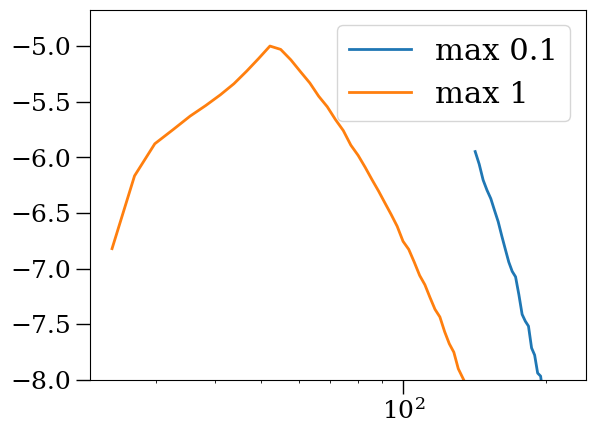

In [ ]:
plt.plot(x_arr1, y_arr1, label='max 0.1')
plt.plot(x_arr2, y_arr2, label='max 1')
plt.xscale('log')
plt.ylim(-8)
plt.legend()

/tmp/ipykernel_429101/2198955823.py:44: RuntimeWarning: invalid value encountered in log10
  return np.log10(x)


(-10.0, -2.0)

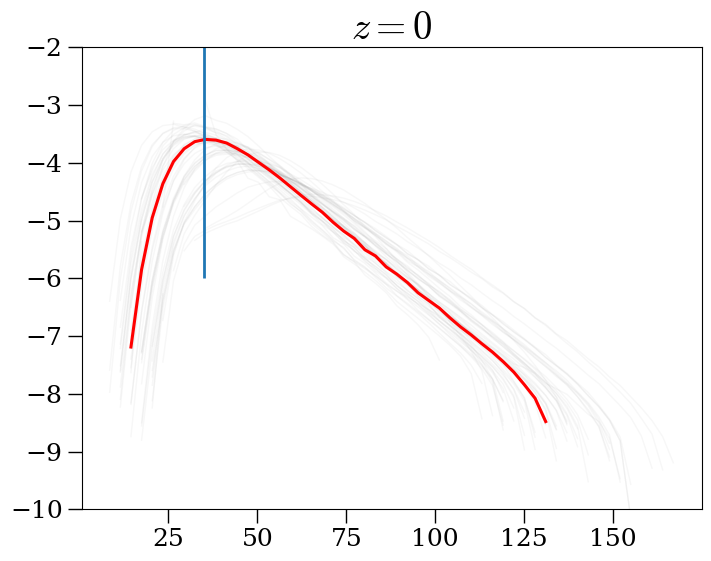

In [ ]:
fig, ax = plt.subplots(figsize=(8,6))
multiplier_dict = default_multiplier_dict.copy()
multiplier_dict['mdot_r_mult'] = 0.1
multiplier_dict['gamma_add'] = -0.45

plot_integrated_z_dnche_vs_mf_ensemble(ax, idata, 0, np.logspace(-3, 0, 100), mi_plot_lims=(1, 300), multiplier_dict=multiplier_dict)
ax.vlines(35, -6, -2)
ax.set_ylim(-10, -2)

/tmp/ipykernel_429101/883493527.py:43: RuntimeWarning: invalid value encountered in log10
  return np.log10(x)


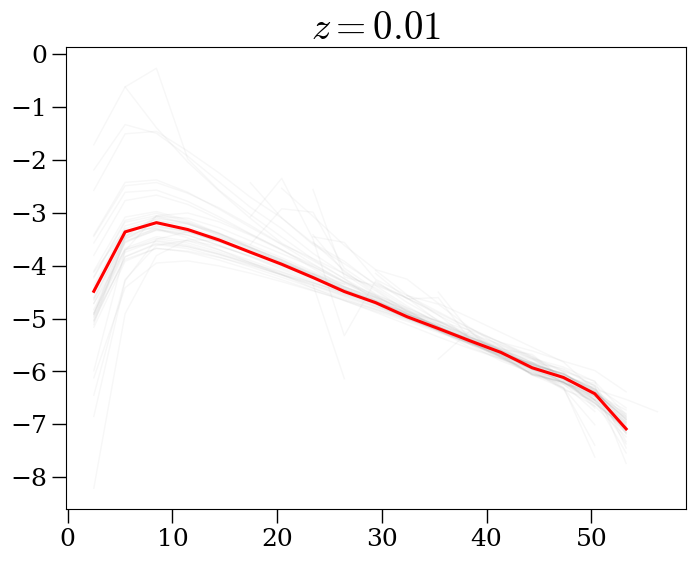

In [ ]:
fig, ax = plt.subplots(figsize=(8,6))
plot_integrated_z_dnche_vs_mf_ensemble(ax, idata, 0.01, np.logspace(-3, 0, 100), mi_plot_lims=(1, 300))

<timed exec>:18: UserWarning: Attempt to set non-positive xlim on a log-scaled axis will be ignored.


CPU times: user 1.26 s, sys: 168 ms, total: 1.43 s
Wall time: 1.42 s


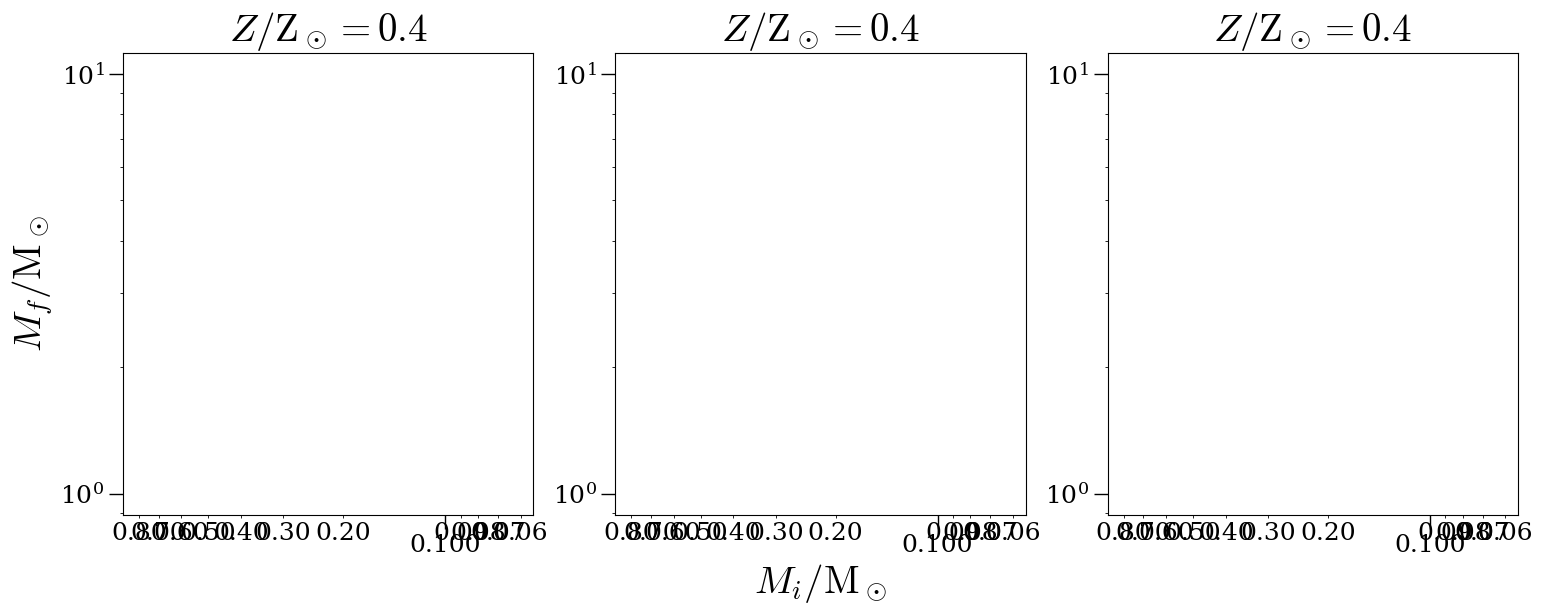

In [ ]:
%%time
fig, axes = plt.subplots(1, 3, figsize=(18, 6))
redshifts = [0.1, 1, 2]

for i, (redshift, ax) in enumerate(zip(redshifts, axes)):
    legend = False if i < len(axes)-1 else True
    #plot_fixed_z_dnche_vs_mf_ensemble(ax, idata, final_var_dict, zdivzsun_key, legend=legend, label_axes=False, ensemble_step=200)
    plot_integrated_z_dnche_vs_mf_ensemble(ax, idata, redshift, Z_arr)
    axes[0].set_ylabel('$M_f/\\mathrm{M}_\\odot$')
axes[1].set_xlabel('$M_i/\\mathrm{M}_\\odot$')

for ax in axes:
    ax.set_yscale('log')
    ax.set_xscale('log')
    xlims = ax.get_xlim()
    ylims = ax.get_ylim()
    ax.vlines(35, *ylims, color='k', linewidth=0.8)
    ax.set_ylim(ylims)
    ax.set_xlim(xlims)
    
    # Force xticklabels to not use scientific notation
    formatter = ScalarFormatter(useMathText=False)
    formatter.set_scientific(False)
    ax.xaxis.set_major_formatter(formatter)
    ax.xaxis.set_minor_formatter(formatter)

## Old sections

In [ ]:
all_model_dicts = {
    '0.0005': model_dicts_00005zsun,
    '0.005': model_dicts_0005zsun,
    '0.02': model_dicts_002zsun,
    '0.05': model_dicts_005zsun,
    '0.1': model_dicts_01zsun,
    '0.2': model_dicts_02zsun,
    '0.4': model_dicts_04zsun,
    '0.6': model_dicts_06zsun,
    '0.8': model_dicts_08zsun,
    '1.0': model_dicts_10zsun
}

final_core_prop_array_dict = {
    '0.0005': np.load(DATA_ROOT/'09_enhanced_w_core_props.npy'),
    '0.005': np.load(DATA_ROOT/'08_enhanced_w_core_props.npy'),
    '0.02': np.load(DATA_ROOT/'07_enhanced_w_core_props.npy'),
    '0.05': np.load(DATA_ROOT/'06_enhanced_w_core_props.npy'),
    '0.1': np.load(DATA_ROOT/'00_enhanced_w_core_props.npy'),
    '0.2': np.load(DATA_ROOT/'01_enhanced_w_core_props.npy'),
    '0.4': np.load(DATA_ROOT/'02_enhanced_w_core_props.npy'),
    '0.6': np.load(DATA_ROOT/'03_enhanced_w_core_props.npy'),
    '0.8': np.load(DATA_ROOT/'04_enhanced_w_core_props.npy'),
    '1.0': np.load(DATA_ROOT/'05_enhanced_w_core_props.npy')
}

NameError: name 'model_dicts_00005zsun' is not defined

In [ ]:
h = mr.MesaData(str(model_dicts_01zsun['300.0']['4.00']/'LOGS/history.data'))

In [ ]:
def get_m_ht_het(h):
    m_i = h.star_mass[0]
    
    try:
        he_poor_end_i = np.where(h.surface_he4 >= 0.3)[0][0]
    except:
        return None, None, None, None
    
    try:
        he_rich_start_i = np.where(h.surface_he4 >= 0.7)[0][0]
    except IndexError:
        return None, None, None, None

    try:
        he_rich_end_i = np.where(((h.center_c12 < 1e-3)
                                & (h.center_he4 < 1e-2)
                                & (h.center_h1 < 0.5)))[0][0]
    except:
        try:
            he_rich_end_i = np.where(((h.center_c12 < 0.5)
                                & (h.center_he4 < 0.5)
                                & (h.center_h1 < 0.5)))[0][0]
        except:
            return None, None, None, None
   
    he_poor_end_t = h.star_age[he_poor_end_i]
    he_rich_end_t = h.star_age[he_rich_end_i]
    he_rich_start_t = h.star_age[he_rich_start_i]
    he_poor_dt = he_poor_end_t
    he_rich_dt = he_rich_end_t - he_rich_start_t
    m_f = h.star_mass[he_rich_end_i]
        
    return m_i, m_f, he_poor_dt, he_rich_dt

In [ ]:
dict_ = all_model_dicts
z_keys = np.array(list(dict_.keys()))
z_keys = z_keys[z_keys.astype(float).argsort()]

dict_ = model_dicts_01zsun
m_keys = np.array(list(dict_.keys()))
m_keys = m_keys[m_keys.astype(float).argsort()]

dict_ = model_dicts_01zsun['300.0']
p_keys = np.array(list(dict_.keys()))
p_keys = p_keys[p_keys.astype(float).argsort()]

## Bulding models

Collect the duration of the He-poor and He-rich phases as a function on Mzams and Pzams from our MESA models.

In [ ]:
def get_m_dt_arr_singlez(model_dicts, m_keys, p_keys):
    m_dt_arr_singlez = np.zeros((len(m_keys), len(p_keys), 4))

    for i_m, m_key in enumerate(m_keys):
        print(f'Loading models for m = {m_key}')
        for i_p, p_key in enumerate(p_keys):
            model_folder = model_dicts[m_key][p_key]
            try:
                h = mr.MesaData(str(model_folder/'LOGS/history.data'))
            except:
                print(f'No history data for m = {m_key}, p = {p_key}')
                continue
            m_i, m_f, he_poor_dt, he_rich_dt = get_m_ht_het(h)
            if m_i is None:
                continue
            m_dt_arr_singlez[i_m, i_p] = [m_i, m_f, he_poor_dt, he_rich_dt]
            
    return m_dt_arr_singlez

def get_m_dt_arr(all_model_dicts, m_keys, p_keys):
    with ProcessPoolExecutor(max_workers=30) as executor:
        futures = {
            executor.submit(get_m_dt_arr_singlez, model_dicts, m_keys, p_keys): z_key
            for z_key, model_dicts in all_model_dicts.items()
        }
        
        unsorted_z_keys = []
        unsorted_z_arrs = []
        for future in as_completed(futures):
            unsorted_z_keys.append(futures[future])
            unsorted_z_arrs.append(future.result())
        sorted_z_arrs = [unsorted_z_arrs[i] for i in np.argsort(unsorted_z_keys)]
        
    m_dt_arr = np.array(sorted_z_arrs)
    return m_dt_arr

In [ ]:
mdat_path = DATA_ROOT/'m_dt_arr.npy'
if mdat_path.exists():
    m_dt_arr = np.load(mdat_path)
else:
    m_dt_arr = get_m_dt_arr(all_model_dicts, m_keys, p_keys)
    np.save(mdat_path, m_dt_arr)

Text(0, 0.5, '$\\tau_\\mathrm{H}/\\mathrm{yr}$')

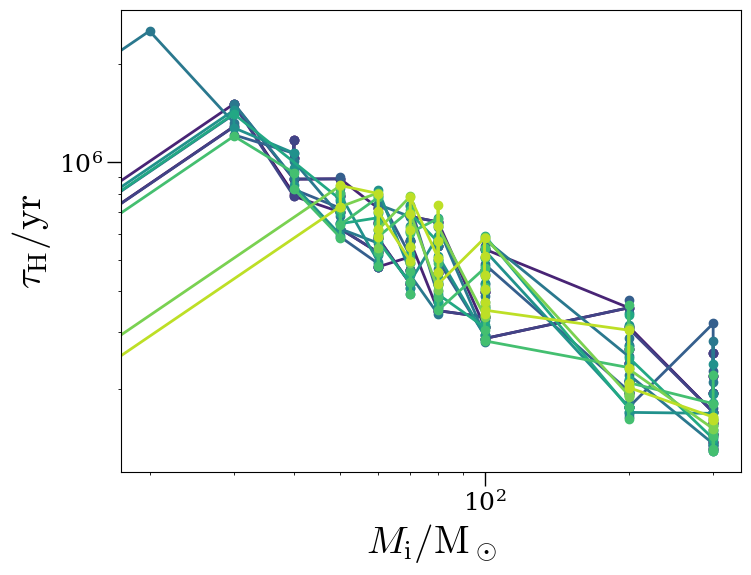

In [ ]:
fig, ax = plt.subplots(figsize=(8, 6))
cmap = cm.viridis
for i_z, z_key in enumerate(z_keys):

    c = cmap(i_z / len(z_keys))
    m_dt_arr_singlez = m_dt_arr[i_z]
    m_dt_arr_singlez = m_dt_arr_singlez[~np.isnan(m_dt_arr_singlez).any(axis=2)]
    x = m_dt_arr_singlez[:, 0]
    y = m_dt_arr_singlez[:, 2]
    y = y[x.argsort()]
    x = x[x.argsort()]
    ax.plot(x, y, '-o', c=c)
    
ax.set_xscale('log')
ax.set_yscale('log')
ax.set_xlabel('$M_\mathrm{i}/\\mathrm{M}_\\odot$')
ax.set_ylabel('$\\tau_\\mathrm{H}/\\mathrm{yr}$')

Text(0, 0.5, '$\\tau_\\mathrm{He}/\\mathrm{yr}$')

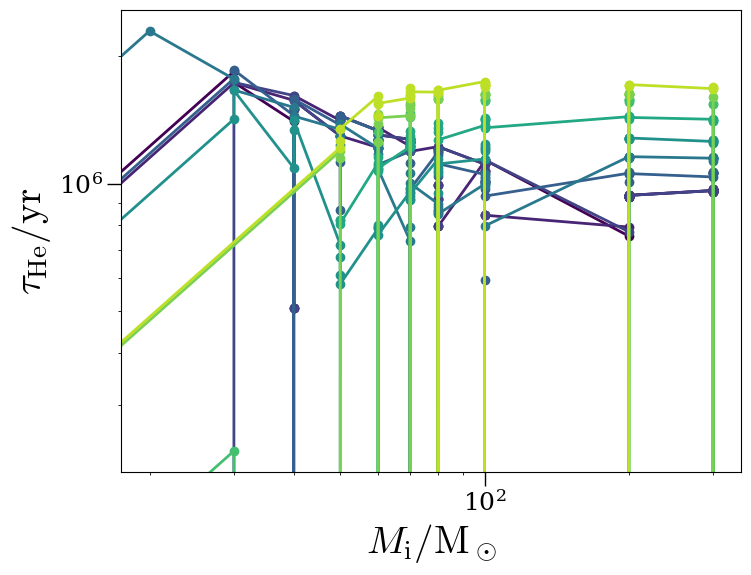

In [ ]:
fig, ax = plt.subplots(figsize=(8, 6))
cmap = cm.viridis
for i_z, z_key in enumerate(z_keys):

    c = cmap(i_z / len(z_keys))
    m_dt_arr_singlez = m_dt_arr[i_z]
    m_dt_arr_singlez = m_dt_arr_singlez[~np.isnan(m_dt_arr_singlez).any(axis=2)]
    x = m_dt_arr_singlez[:, 0]
    y = m_dt_arr_singlez[:, 3]
    y = y[x.argsort()]
    x = x[x.argsort()]
    ax.plot(x, y, '-o', c=c)
    
ax.set_xscale('log')
ax.set_yscale('log')
ax.set_xlabel('$M_\mathrm{i}/\\mathrm{M}_\\odot$')
ax.set_ylabel('$\\tau_\\mathrm{He}/\\mathrm{yr}$')

Approximate our He-poor and He-rich thick winds as power-laws over mass. For now we consider the mass loss from thin winds negligible.

In [ ]:
def grafener_l_to_m_he_burning(l):
    """Equation 18 from Gräfener et al. (2011).
    
    From relations 17, 16 and 18 in Table A.1 Switch at logL=6.5 is from
    Sabhahit et al. (2023).
    """
    
    FF = [8.177, -1.0, 105.5, -10.10] # 18
    #FF = [3.997, -1.0, 25.83, -3.268] # 16
    #FF = [3.059, -1.0, 14.76, -2.049] # 17
    logm = FF[0] + FF[1] * np.sqrt(FF[2] + FF[3] * np.log10(l))
    return 10.**logm

pl_t = 1.41e5
pl_z = 10.**np.arange(-5, 1, 1) * Z_SUN
pl_l = np.logspace(3.8, 8, 10000)
pl_m = np.array([grafener_l_to_m_he_burning(l) for l in pl_l])


In [ ]:
def edd_gamma(l, m, x):
    return 10**-4.817 * (1+x) * l/m


def sander2020_ge_w(g_e, z):
    g_eb = -0.324*np.log10(z/Z_SUN) + 0.244
    c = -0.44*np.log10(z/Z_SUN) + 9.15
    d = 0.23*np.log10(z/Z_SUN) - 2.61
    
    #print(g_eb, c, d, g_e, z)
    
    log_mdot = 2.932 * np.log10(-np.log10(1-g_e)) - np.log10(2) * (g_eb/g_e)**c + d
    #print(2.932 , np.log10(-np.log10(1-g_e)), np.log10(2), (g_eb/g_e), c, d)
    w = 10.**log_mdot
    #print(log_mdot)
    return w

def sander2023_ge_w(l, m, t_eff, z, x):
    g_e = edd_gamma(l, m, x)
    #print(g_e)
    w20 = sander2020_ge_w(g_e, z)
    #print(w20)
    if t_eff > 1.e5:
        log_mdot = np.log10(w20) - 6*np.log10(t_eff/1.41e5)
        w = 10.**log_mdot
    else:
        w = w20
    return w

@np.vectorize
def sander2023_l_w(l, t, z):
    logz = np.log10(z/Z_SUN)
    alpha = 0.32 * logz + 1.4
    l0 = 10.**(-0.87*logz + 5.06)
    mdot10 = 10.**(-0.75*logz - 4.06)
    
    if l <= l0:
        log_power_term = 0
    else:
        log_power_term = np.log10(l/l0) ** alpha
              
    w = mdot10 * log_power_term * (l/(10*l0))**0.75
    
    if t > 1e5 and l > l0:
        log_w = np.log10(w) - 6*np.log10(t/1.41e5)
        w = 10.**log_w
    return w

def vink2017_w(l, z):
    log_mdot = -13.3 + 1.36*np.log10(l) + 0.61*np.log10(z/Z_SUN)
    w = 10.**log_mdot
    return w


/tmp/ipykernel_2086287/2012806839.py:9: RuntimeWarning: divide by zero encountered in log10
  y = np.log10(sander2023_l_w(pl_l, pl_t, z))


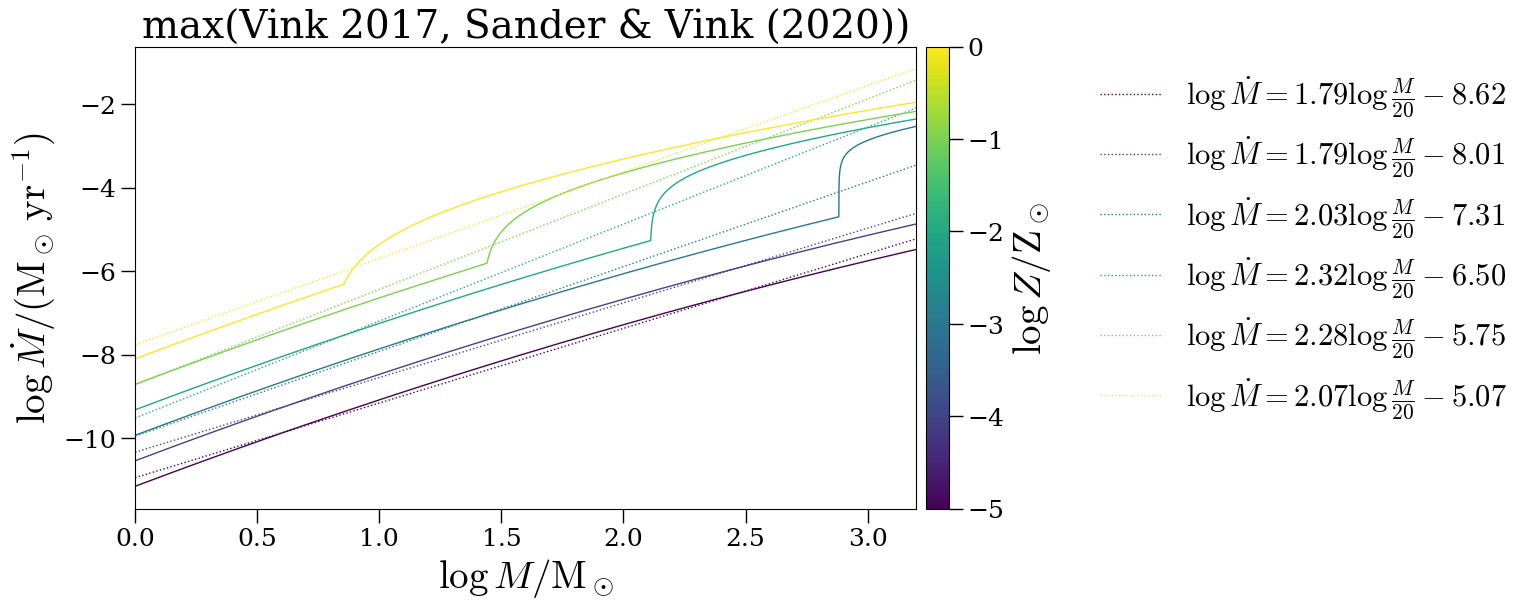

In [ ]:
fig, ax = plt.subplots(figsize=(12, 6))
cmap = cm.viridis

z_norm = np.zeros((len(pl_z), 2))
pl_fits = np.zeros((len(pl_z), 3))
x = np.log10(pl_m)
for i, z in enumerate(pl_z):
    c = cmap((np.log10(z/Z_SUN)+5)/5)
    y = np.log10(sander2023_l_w(pl_l, pl_t, z))
    y2 = np.log10(vink2017_w(pl_l, z))
    y3 = np.max([y, y2], axis=0)
    #ax.plot(x, y, '--', c=c, lw=0.5)
    #ax.plot(x, y2, '--', c=c, lw=0.5)
    ax.plot(x, y3, '-', c=c, lw=1)
    
    
    reg_x = x[~np.isinf(y3)] - np.log10(20)
    reg_y = y3[~np.isinf(y3)]
    slope, norm, *_ = linregress(np.copy(reg_x), np.copy(reg_y))
    ax.plot(x, norm+slope*(x-np.log10(20)), ':', c=c, lw=1, label=f'$\\log\dot{{M}}={slope:.2f}\\log \\frac{{M}}{{20}}{norm:.2f}$')   
    z_norm[i] = (np.log10(z/Z_SUN), norm)
    pl_fits[i] = [np.log10(z/Z_SUN), slope, norm]

ax.set_ylabel('$\\log\\dot{M}/(\\mathrm{M}_\\odot\\,\\mathrm{yr}^{-1})$')
ax.set_xlabel('$\\log M/\\mathrm{M}_\\odot$')

sm = cm.ScalarMappable(Normalize(vmin=-5, vmax=0), cmap=cmap)
cb = fig.colorbar(sm, ax=ax, pad=0.01)
cb.set_label('$\\log Z/\\mathrm{Z}_\\odot$')
ax.set_xlim(0, 3.2)
ax.set_title('max(Vink 2017, Sander & Vink (2020))')
ax.legend(frameon=False, loc='upper left', bbox_to_anchor=(1.2, 1))

Text(0, 0.5, '$\\log \\dot{M}_{20}/(\\mathrm{M}_\\odot\\,\\mathrm{yr}^{-1})$')

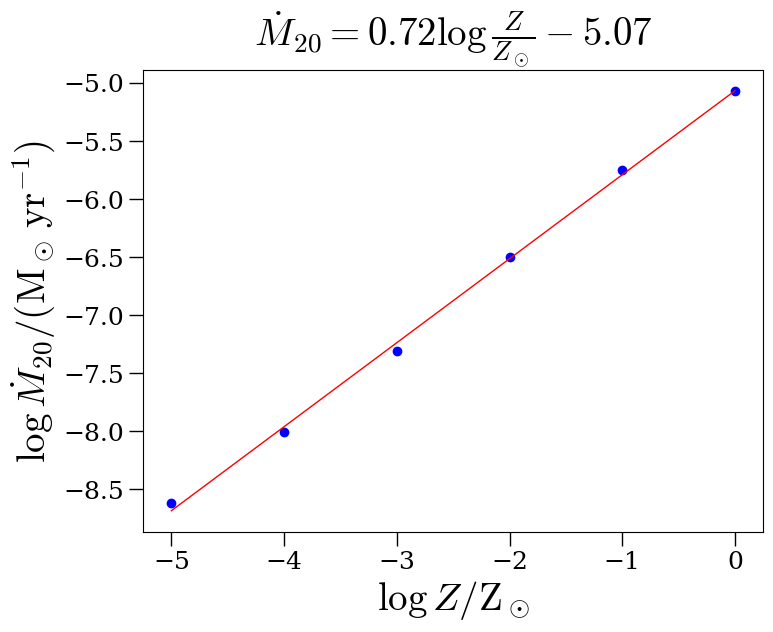

In [ ]:
fig, ax = plt.subplots(figsize=(8, 6))

slope, norm, *_ = linregress(pl_fits[:, 0], pl_fits[:, 2])
ax.plot(pl_fits[:, 0], pl_fits[:, 2], 'bo')
ax.plot(pl_fits[:, 0], norm+slope*pl_fits[:, 0], 'r-', lw=1, label=f'$\\log\dot{{M}}={slope:.2f}\\log \\frac{{M}}{{20}}{norm:.2f}$')
ax.set_title(f'$\dot{{M}}_{{20}}={slope:.2f}\\log\\frac{{Z}}{{Z_\\odot}} {norm:.2f}$')
ax.set_xlabel('$\\log Z/\\mathrm{Z}_\\odot$')
ax.set_ylabel('$\\log \\dot{M}_{20}/(\\mathrm{M}_\\odot\\,\\mathrm{yr}^{-1})$')




In [ ]:
def krticka2024_w(l, teff, z):
    a = -13.82
    b = 1.52
    c = 3.84
    t1 = 14.16e3
    t2 = 37.9e3
    dt1 = 3.58e3
    dt2 = 56.5e3
    alpha = 0.358
    beta = -0.11
    delta = 0.73
    log_z_div_z_sun = np.log10(z/Z_SUN)
    
    log_lin_comp = (a
                    + alpha * log_z_div_z_sun
                    + (b + beta * log_z_div_z_sun) * np.log10(l/1e6))
    gauss_mix_comp = ((1 + delta * log_z_div_z_sun) * np.exp(-(teff-t1)**2/dt1**2)
                      + c * np.exp(-(teff-t2)**2/dt2**2))
    log_mdot = log_lin_comp - a * np.log10(gauss_mix_comp)
    w = 10.**log_mdot
    return w

In [ ]:
from scipy.optimize import fmin

def grafener_m_to_l_he_burning(m):
    """Equation 10 from Gräfener et al. (2011).
    
    From relations 6, 7, and 8 in Table A.1 Switch at logL=6.5 is from
    Sabhahit et al. (2023).
    """
    #FF = [3.017, 2.446, -0.306] # 6
    #FF = [3.017, 2.446, -0.306] # 7
    FF = [3.826, 1.619, -0.099] # 8
    log_l = FF[0] + FF[1]*np.log10(m) + FF[2]*np.log10(m)**2
    return 10.**log_l

def l_div_m(l):
    m = grafener_l_to_m_he_burning(l)
    l_div_m = l/m
    return l_div_m

def g_e_to_l(g_e, x):
    l_div_m_ = (g_e / 10.**-4.817 / (1+x))
    l = fmin(lambda x: np.abs(l_div_m(x) - l_div_m_), 1e6, disp=False)
    return l

def sabhahit2023_g_switch_k24(z):
    g_switch = 0.701 * (z/Z_SUN)**-0.056
    return g_switch

@np.vectorize
def vink2011_w(m, t, z):
    l = grafener_m_to_l_he_burning(m)
    g_e = edd_gamma(l, m, 0.7)
    g_switch = sabhahit2023_g_switch_k24(z)
    
    if g_e < g_switch:
        w = krticka2024_w(l, t, z)
    else:
        l_switch = g_e_to_l(g_switch, 0.7)
        m_switch = grafener_l_to_m_he_burning(l_switch)
        mdot_switch = krticka2024_w(l_switch, t, z)
        w = mdot_switch * (l/l_switch)**4.77 * (m/m_switch)**-3.99
        
    return w
        

In [ ]:
np.log10(g_e_to_l(0.6, 0.7))

/tmp/ipykernel_2086287/578971236.py:11: RuntimeWarning: invalid value encountered in log10
  logm = FF[0] + FF[1] * np.sqrt(FF[2] + FF[3] * np.log10(l))


array([5.41052322])

In [ ]:
np.log10(g_e_to_l(sabhahit2023_g_switch_k24(0.017), 0.7)), grafener_l_to_m_he_burning(g_e_to_l(sabhahit2023_g_switch_k24(0.017), 0.7))

(array([5.64906436]), array([16.47385604]))

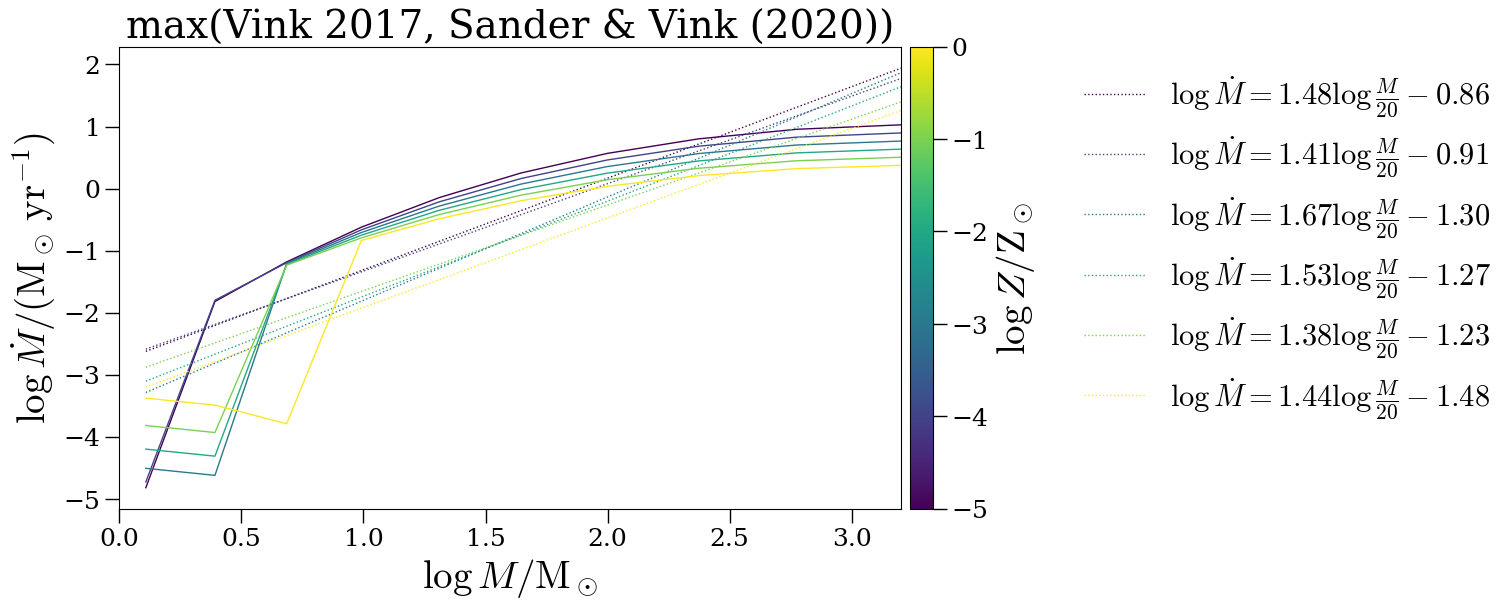

In [ ]:
pl_t = 10.**4.75# 1.41e5
pl_z = 10.**np.arange(-5, 1, 1) * Z_SUN
pl_l = np.logspace(4, 8, 10)
pl_m = np.array([grafener_l_to_m_he_burning(l) for l in pl_l])

fig, ax = plt.subplots(figsize=(12, 6))
cmap = cm.viridis

z_norm = np.zeros((len(pl_z), 2))
pl_fits = np.zeros((len(pl_z), 3))
x = np.log10(pl_m)
for i, z in enumerate(pl_z):
    c = cmap((np.log10(z/Z_SUN)+5)/5)
    #y = np.log10(sander2023_l_w(pl_l, pl_t, z))
    #y2 = np.log10(vink2017_w(pl_l, z))
    y3 = np.log10(vink2011_w(pl_l, pl_t, z))
    #ax.plot(x, y, '--', c=c, lw=0.5)
    #ax.plot(x, y2, '--', c=c, lw=0.5)
    ax.plot(x, y3, '-', c=c, lw=1)
    
    
    reg_x = x[~np.isinf(y3)] - np.log10(20)
    reg_y = y3[~np.isinf(y3)]
    slope, norm, *_ = linregress(np.copy(reg_x), np.copy(reg_y))
    ax.plot(x, norm+slope*(x-np.log10(20)), ':', c=c, lw=1, label=f'$\\log\dot{{M}}={slope:.2f}\\log \\frac{{M}}{{20}}{norm:.2f}$')   
    z_norm[i] = (np.log10(z/Z_SUN), norm)
    pl_fits[i] = [np.log10(z/Z_SUN), slope, norm]

ax.set_ylabel('$\\log\\dot{M}/(\\mathrm{M}_\\odot\\,\\mathrm{yr}^{-1})$')
ax.set_xlabel('$\\log M/\\mathrm{M}_\\odot$')

sm = cm.ScalarMappable(Normalize(vmin=-5, vmax=0), cmap=cmap)
cb = fig.colorbar(sm, ax=ax, pad=0.01)
cb.set_label('$\\log Z/\\mathrm{Z}_\\odot$')
ax.set_xlim(0, 3.2)
ax.set_title('max(Vink 2017, Sander & Vink (2020))')
ax.legend(frameon=False, loc='upper left', bbox_to_anchor=(1.2, 1))

In [ ]:
mr_hepoor = 10.**-6.5
beta_hepoor = 3.7
t20_hepoor = 10.**6.23
mr20_hepoor = mr_hepoor/(20/t20_hepoor)

mr_herich = 10.**-6.5
beta_herich = 2.3
t20_herich = 10.**6.23
mr20_herich = mr/(20/t20_herich)

In [ ]:
def get_mf(mi_, mr20, t20, dt, beta):
    mi = mi_/20
    mf_power = mi**(1-beta) + (beta - 1) * mr20 * dt/t20
    mf = mf_power**(1/(1-beta))
    return mf*20

/tmp/ipykernel_2086287/3325793870.py:3: RuntimeWarning: divide by zero encountered in power
  mf_power = mi**(1-beta) + (beta - 1) * mr20 * dt/t20


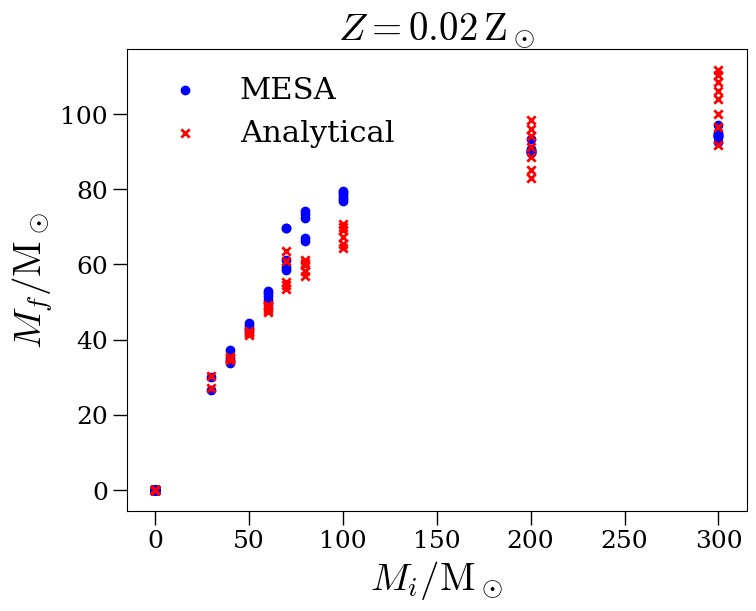

In [ ]:
fig, ax = plt.subplots(figsize=(8, 6))
cmap = cm.viridis
for i_z, z_key in enumerate(z_keys):
    if z_key != '0.02':
        continue
    c = cmap(i_z / len(z_keys))
    m_dt_arr_singlez = m_dt_arr[i_z]
    m_dt_arr_singlez = m_dt_arr_singlez[~np.isnan(m_dt_arr_singlez).any(axis=2)]
    ax.scatter(m_dt_arr_singlez[:, 0], m_dt_arr_singlez[:, 1], c='b')
    ax.scatter(m_dt_arr_singlez[:, 0], get_mf(get_mf(m_dt_arr_singlez[:, 0], mr20_hepoor, t20_hepoor, m_dt_arr_singlez[:, 2], beta_hepoor), mr20_herich, t20_herich, m_dt_arr_singlez[:, 3], beta_herich), c='r', marker='x')
#ax.set_yscale('log')
#ax.set_xscale('log')
#ax.plot(np.linspace(20, 300, 100), get_mf(np.linspace(20, 300, 100), mr20, alpha, beta), 'r')

ax.set_xlabel('$M_i/\mathrm{M}_\odot$')
ax.set_ylabel('$M_f/\mathrm{M}_\odot$')
ax.set_title('$Z=0.02\,\mathrm{Z}_\odot$')

handles, labels = ax.get_legend_handles_labels()
handles.append(ax.scatter([], [], marker='o', c='b', label='MESA'))
handles.append(ax.scatter([], [], marker='x', c='r', label='Analytical'))
ax.legend(handles=handles, loc='upper left', frameon=False)

In [ ]:
mr_hepoor = 10.**-6
beta_hepoor = 5
t20_hepoor = 10.**6.23
mr20_hepoor = mr_hepoor/(20/t20_hepoor)

mr_herich = 10.**-5.5
beta_herich = 2.3
t20_herich = 10.**6.23
mr20_herich = mr/(20/t20_herich)

/tmp/ipykernel_2086287/3325793870.py:3: RuntimeWarning: divide by zero encountered in power
  mf_power = mi**(1-beta) + (beta - 1) * mr20 * dt/t20


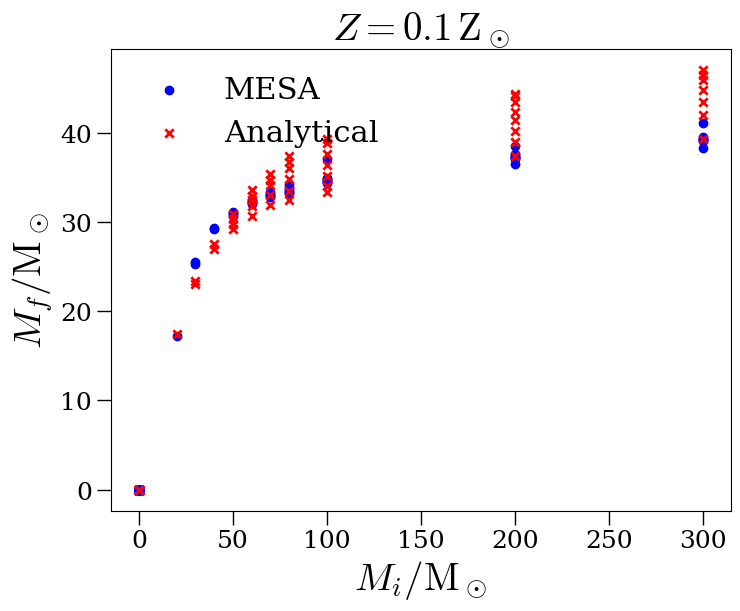

In [ ]:
fig, ax = plt.subplots(figsize=(8, 6))
cmap = cm.viridis
for i_z, z_key in enumerate(z_keys):
    if z_key != '0.1':
        continue
    c = cmap(i_z / len(z_keys))
    m_dt_arr_singlez = m_dt_arr[i_z]
    m_dt_arr_singlez = m_dt_arr_singlez[~np.isnan(m_dt_arr_singlez).any(axis=2)]
    ax.scatter(m_dt_arr_singlez[:, 0], m_dt_arr_singlez[:, 1], c='b')
    ax.scatter(m_dt_arr_singlez[:, 0], get_mf(get_mf(m_dt_arr_singlez[:, 0], mr20_hepoor, t20_hepoor, m_dt_arr_singlez[:, 2], beta_hepoor), mr20_herich, t20_herich, m_dt_arr_singlez[:, 3], beta_herich), c='r', marker='x')
#ax.set_yscale('log')
#ax.set_xscale('log')
#ax.plot(np.linspace(20, 300, 100), get_mf(np.linspace(20, 300, 100), mr20, alpha, beta), 'r')

ax.set_xlabel('$M_i/\mathrm{M}_\odot$')
ax.set_ylabel('$M_f/\mathrm{M}_\odot$')
ax.set_title('$Z=0.1\,\mathrm{Z}_\odot$')

handles, labels = ax.get_legend_handles_labels()
handles.append(ax.scatter([], [], marker='o', c='b', label='MESA'))
handles.append(ax.scatter([], [], marker='x', c='r', label='Analytical'))
ax.legend(handles=handles, loc='upper left', frameon=False)

/tmp/ipykernel_2086287/3325793870.py:3: RuntimeWarning: divide by zero encountered in power
  mf_power = mi**(1-beta) + (beta - 1) * mr20 * dt/t20


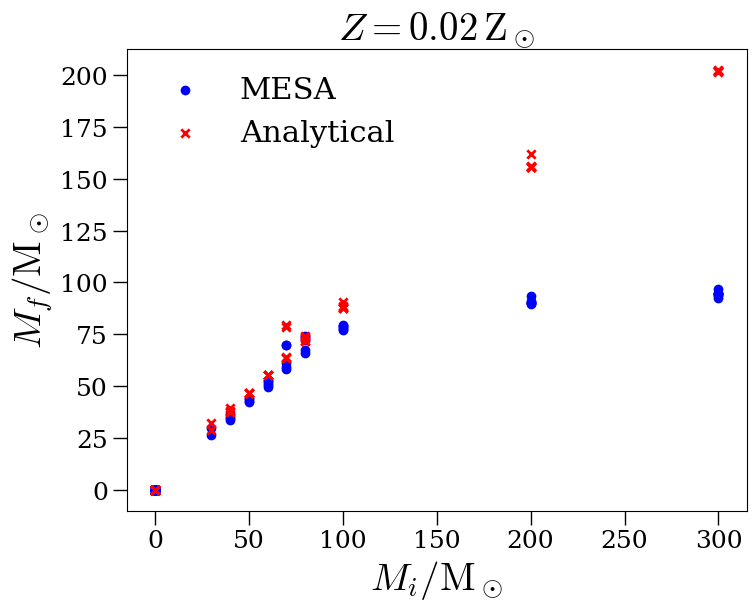

In [ ]:
fig, ax = plt.subplots(figsize=(8, 6))
cmap = cm.viridis
for i_z, z_key in enumerate(z_keys):
    if z_key != '0.02':
        continue
    c = cmap(i_z / len(z_keys))
    m_dt_arr_singlez = m_dt_arr[i_z]
    m_dt_arr_singlez = m_dt_arr_singlez[~np.isnan(m_dt_arr_singlez).any(axis=2)]
    ax.scatter(m_dt_arr_singlez[:, 0], m_dt_arr_singlez[:, 1], c='b')
    ax.scatter(m_dt_arr_singlez[:, 0], get_mf(m_dt_arr_singlez[:, 0], mr20, t20, m_dt_arr_singlez[:, 3], beta), c='r', marker='x')
#ax.set_yscale('log')
#ax.set_xscale('log')
#ax.plot(np.linspace(20, 300, 100), get_mf(np.linspace(20, 300, 100), mr20, alpha, beta), 'r')

ax.set_xlabel('$M_i/\mathrm{M}_\odot$')
ax.set_ylabel('$M_f/\mathrm{M}_\odot$')
ax.set_title('$Z=0.02\,\mathrm{Z}_\odot$')

handles, labels = ax.get_legend_handles_labels()
handles.append(ax.scatter([], [], marker='o', c='b', label='MESA'))
handles.append(ax.scatter([], [], marker='x', c='r', label='Analytical'))
ax.legend(handles=handles, loc='upper left', frameon=False)